# 04 - Runtime Prediction Models

## Objective and Scope

This profound notebook executes the hybrid training and rigorous optimization of both machine learning and neural network engines utilizing the radically augmented workload dimensions synthesized strictly during data engineering (Notebook 03). It transcends simple statistical implementations by empirically measuring the severe logical and hardware-level infrastructure costs associated with categorical data injection (One-Hot vs. Native Categorical) across both deep learning and tree-based paradigms.

The core analysis is seamlessly constructed across 6 rigidly interconnected sequential domains:

1.  **Experiment A:** Classical Machine Learning Models — *Numeric Features Only (Numeric-Only ML)*
2.  **Experiment B:** Classical Machine Learning Models — *Contribution of Categorical Encoding (One-Hot ML)*
3.  **Experiment C:** Static Deep Learning Neural Models — *Numeric Features Only (Numeric-Only DL)*
4.  **Experiment D:** Static Deep Learning Neural Models — *Contribution of Categorical Encoding (One-Hot DL)*
5.  **Experiment E:** Temporal Deep Learning Models — *Numeric Features Only (Numeric-Only DL Sequence)*
6.  **Experiment F:** Temporal Deep Learning Models — *Contribution of Categorical Encoding (One-Hot DL Sequence)*

The apex objective is to definitively identify and isolate the ultimate "The Best" predictive architecture, which fundamentally acts as the autonomous brain for the massive scheduling algorithms constructed within Pipeline phase 05.


## Problem Definition and Prediction Target

The goal of this notebook is to predict the **job runtime** for GPU jobs in the Alibaba PAI workload. The prediction target is the true job execution time, denoted as `job_runtime` (in seconds).

As inputs, job-level resource demands (GPU, CPU, number of instances) are used together with temporal features. The task is treated as a **regression problem**, since the target variable is continuous.

## Feature Construction and Representation

The dataset and features used for model training are prepared using the prepare_features_for_model function.
This function performs the following steps:

- Loads the preprocessed job table

- Separates numerical and categorical features

- Uses the true job runtime (job_runtime) as the prediction target

- Splits the data into 80% training and 20% testing sets

This ensures a fair comparison, as all models are trained and evaluated on the same data split.

## Hyperparameter Tuning Strategy

We follow the same three-stage hyperparameter tuning protocol for all models:

- **(1) RandomizedSearchCV:** Quickly explores a broad search space with a limited number of trials to find a promising region.  
- **(2) Narrow GridSearchCV:** Performs fine-grained tuning within a narrowed grid around the best randomized configuration.  
- **(3) Final Refit:** Retrains the model using the selected hyperparameters on the training data only; at this stage, **early stopping** is applied for **XGBoost** and **LightGBM** using a validation split taken from the training set (not used for Random Forest).

Steps (1) and (2) aim to improve **Cross Validation MAE**; the **test set is not used during tuning** and is reserved only for the final evaluation.


In [1]:
# ── 0. Environment & Path Setup ──────────────────────────────────────────────
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")
# Anchor on a marker that only exists at the repository root, so the notebook
# works regardless of the directory the kernel was started from. The previous
# parents[1] form silently resolved one level short when the working directory
# was notebooks/ rather than notebooks/<lang>/.
def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    return start.parents[1]

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"[Setup] Project root : {PROJECT_ROOT}")

[Setup] Project root : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling


In [ ]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
# stdlib / third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
from IPython.display import display
# Project
import src.tuning
import importlib
importlib.reload(src.tuning)
import src.feature_engineering
importlib.reload(src.feature_engineering)
from src.tuning import load_dl_config
from src.feature_engineering import prepare_features_for_model
from src.models.evaluation import evaluate_regression, is_degenerate_prediction, is_near_constant_prediction
from src.tuning import (
    run_randomsearch_rf, 
    run_randomsearch_xgb, 
    run_randomsearch_lgbm,
    run_gridsearch_rf, 
    run_gridsearch_xgb, 
    run_gridsearch_lgbm,
    finalize_ml_model,
    model_artifact_is_current,
    record_model_artifact,
    prepare_dl_datasets,
    run_randomsearch_cnn,   
    run_randomsearch_lstm,   
    run_randomsearch_hybrid,
    run_gridsearch_cnn,     
    run_gridsearch_lstm,     
    run_gridsearch_hybrid,
    finalize_dl_model, 
    make_narrow_grid,
    run_gridsearch_iterative,
    save_checkpoint,
    load_checkpoint,
    load_all_checkpoints,
)

# ── Degeneracy verdict shared by every results table below ───────────────────
# A results table that prints MAE without saying whether the model produced
# more than one distinct prediction ranks a collapsed model alongside the ones
# that learned something -- and a collapsed model is exactly what notebook 05
# refuses to simulate, because a constant prediction imposes no ordering.
# is_degenerate_prediction is three-valued on purpose: a checkpoint written
# before evaluate_regression recorded pred_unique_frac carries no evidence to
# judge on, and every deep-learning checkpoint currently on disk is one of
# those. Rendering that absence as "no" would print a clean bill of health the
# data does not support, so the unknown state keeps a label of its own.
DEGENERACY_LABELS = {True: "YES — EXCLUDED", False: "no", None: "unknown"}
# A fourth reading that is NOT an exclusion: the model ranks, but out of only a
# handful of distinct values. That is the fingerprint of a model that barely
# fitted -- Exp A LightGBM reached its MAE with a refit that early-stopped at
# ONE tree -- and a bare "no" hides it from a reader comparing MAEs. It is kept
# out of DEGENERACY_LABELS on purpose: those three are the exclusion verdict,
# and print_degeneracy_notice keys its EXCLUDED block on them.
NEAR_CONSTANT_LABEL = "near-constant (ranks)"


def degeneracy_label(metrics) -> str:
    """Verdict cell for a results table: exclusion first, coarseness second."""
    _metrics = metrics or {}
    _collapsed = is_degenerate_prediction(_metrics)
    if _collapsed is False and is_near_constant_prediction(_metrics) is True:
        return NEAR_CONSTANT_LABEL
    return DEGENERACY_LABELS.get(_collapsed, DEGENERACY_LABELS[None])


def print_degeneracy_notice(names, labels) -> None:
    """State the exclusions, and the unjudgeable rows, beneath a results table.

    Mirrors notebook 05's EXCLUDED POLICIES block: an exclusion is this
    notebook's finding about that model, not a row that merely scored badly, so
    it is printed where the table is read rather than left for a reader to
    notice a column.
    """
    _excluded = [_n for _n, _v in zip(names, labels) if _v == DEGENERACY_LABELS[True]]
    _unknown = [_n for _n, _v in zip(names, labels) if _v == DEGENERACY_LABELS[None]]
    if _excluded:
        print()
        print("=" * 70)
        print(f"  EXCLUDED — {len(_excluded)} model(s) collapsed to a constant output")
        print("=" * 70)
        for _n in _excluded:
            print(f"  {_n}")
        print("  A constant prediction imposes no ordering, so the SJF policy built on")
        print("  it is the no-prediction baseline wearing the model's name, not a")
        print("  ranked predictor that happened to score no improvement.")
    if _unknown:
        print(f'[Unknown] {len(_unknown)} row(s) read "{DEGENERACY_LABELS[None]}": their checkpoint')
        print("          predates the pred_unique_frac field, so nothing has judged them.")
        print("          Re-run those models before the row can be trusted.")

# Unified visualisation theme — applied globally for the whole notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.family": "DejaVu Sans",
    # ── Publication-grade output (figure/table audit) ──────────────────────
    # scripts/export_thesis_results.py scrapes the notebook's own inline PNG,
    # so the INLINE dpi is what reaches the thesis. At the 100 dpi default
    # these exported at 147-280 ppi, under the 300 ppi publisher floor.
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    # Figures are now authored at roughly the width they are PRINTED at
    # (\textwidth = 6.10 in in thesis.cls: a4paper, 3.5cm/2cm margins), so the
    # downscale is ~0.8x rather than the ~0.34x that made in-figure text print
    # at 2.5-4.8 pt -- under the ~6 pt legibility floor. At these sizes the
    # smallest label prints at ~6.4 pt and body text at ~7.2 pt.
    # Figures are authored on a generous canvas (10-18 in) and printed into a
    # 6.10-in column, roughly a 0.35-0.55x reduction. Shrinking the canvas to
    # match the print width made every panel cramped, so the canvas stays and
    # the TYPE is scaled instead: at 15 pt a 14-in figure prints at 6.5 pt,
    # above the ~6 pt legibility floor, while still looking uncrowded at
    # authoring size.
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 19,
})
MODEL_DIR = PROJECT_ROOT / "results" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print("[Setup] All imports OK.")
print(f"[Setup] Model output : {MODEL_DIR}")
print(f"[Setup] PyTorch      : {torch.__version__}")

In [3]:
# ── 2. Load Hyperparameter Configuration ─────────────────────────────────────
dl_config = load_dl_config()
# Final refits are repeated over these seeds and reported as mean +/- std.
# A single run is reproducible but cannot separate a genuine difference between
# architectures from the luck of one weight initialisation.
DL_SEEDS = [42, 1337, 2024]
print(f"[Setup] DL config loaded. Final refit seeds: {DL_SEEDS}")

[Setup] DL config loaded. Final refit seeds: [42, 1337, 2024]


## Experiment A: Classical Machine Learning Models (Numeric Features Only)

This section trains classical machine learning models exclusively using numeric topology parameters, establishing a fundamental baseline to accurately measure the specific predictive impact gained by introducing subsequent categorical elements.

In [4]:
# ── 3. Experiment A: Data Preparation (Numeric-Only) ─────────────────────────
print("[Exp A] Loading numeric-only feature set...")
(job_df,
 X_train, X_test,
 y_train, y_test,
 num_cols, cat_cols) = prepare_features_for_model(
    dataset="main",
    time_unit="s",
    test_size=0.20,
    random_state=42,
    feature_mode="numeric_only",
)
print(f"[Exp A] X_train : {X_train.shape}  |  X_test : {X_test.shape}")

[Exp A] Loading numeric-only feature set...


[Exp A] X_train : (65747, 9)  |  X_test : (16437, 9)

Model inputs consist of **numerical** and **categorical** features derived from the raw job data.  
Raw timestamps are not used directly; instead, derived temporal features are employed to represent time-related patterns more effectively.

**The numerical features** used in the models are:
- `gpu_demand`: Number of GPUs requested  
- `num_cpu`: Number of CPUs requested  
- `num_inst`: Number of instances used  
- `arrival_sec`: Relative job arrival time with respect to the beginning of the trace (seconds)  
- `hour_of_day`: Hour of the day  
- `day_of_week`: Trace-relative day index (0, 1, 2, ...; not a verified calendar weekday)  
- `cluster_load_cpu`: Background CPU load across the cluster at the time of job arrival  
- `cluster_load_gpu`: Background GPU load across the cluster at the time of job arrival  
- `active_job_count`: Number of other active jobs in the cluster at the time of job arrival  

**The categorical features** include:
- `user`: Job owner  
- `gpu_type`: GPU type used  

This study is structured around six feature-representation scenarios:

- **(A) Machine Learning Baseline Scenario (Numeric-Only Baseline):**  
  To ensure that all models operate within the same feature space, only the **numerical features** listed above are used.  
  This setup enables a direct and fair comparison among **Random Forest**, **XGBoost**, and **LightGBM** models.

- **(B) Machine Learning with Categorical Feature Integration (One-Hot Encoding):**  
  The contribution of categorical information is additionally investigated. In this scenario, the variables `user` and `gpu_type` are handled as follows:
  - For **Random Forest / XGBoost / LGBM**, the variables are transformed into the numerical space using **one-hot encoding**.
  - For **LightGBM**, the variables are preserved as **native categorical features**.

- **(C) Deep Learning Baseline Scenario (Numeric-Only Baseline):**  
  To evaluate the learning capacity of neural network architectures without categorical information, deep learning models are trained using only **numerical features**.  
  The following architectures are used in this experiment:
  - **1D-CNN**
  - **LSTM**
  - **CNN–LSTM Hybrid**

  This configuration allows a direct structural comparison with the machine learning models in **Experiment A**, since the same feature space is used.

- **(D) Deep Learning with Categorical Feature Integration (One-Hot Encoding):**  
  To evaluate the capability of neural networks to learn complex patterns from high-dimensional data representations, the variables `user` and `gpu_type` are incorporated into the model using **one-hot encoding**.  
  The following deep learning architectures are evaluated in this experiment:

  - **1D-CNN**  
  - **LSTM**  
  - **CNN-LSTM Hybrid**

  This configuration allows the network to learn **joint representations** from both **numerical metrics** and **sparse categorical vectors**, enabling the model to capture complex relationships across heterogeneous feature types.

- **(E) Deep Learning with Temporal Sliding Windows (Numeric-Only Sequence):**
  To evaluate the capability of neural networks to learn temporal queue dynamics, deep learning models are trained using only numerical features organized into short-term sequences (sliding window of 10 jobs).
  The following architectures are used in this experiment:

  - **1D-CNN**
  - **LSTM**
  - **CNN-LSTM Hybrid**

  This configuration allows a direct structural comparison with the static models in Experiment C, since the same feature space is used.

- **(F) Deep Learning with Temporal Sliding Windows and Categorical Integration (One-Hot Sequence):**
  To evaluate the capability of neural networks to learn temporal patterns alongside high-dimensional data representations, the variables `user` and `gpu_type` are incorporated into the sequential model using one-hot encoding.
  The following deep learning architectures are evaluated in this experiment:

  - **1D-CNN**
  - **LSTM**
  - **CNN-LSTM Hybrid**

This design both avoids uncontrolled feature-space expansion for high-cardinality categories and allows the impact of categorical information to be measured in a controlled way.

Model performance is evaluated using five standard regression metrics:

- MAE (Mean Absolute Error), representing the average absolute difference between predicted and actual runtimes

- MdAE (Median Absolute Error), which provides a robust measure of typical error by ignoring extreme outliers

- RMSE (Root Mean Squared Error), which penalizes large errors more strongly

- MAPE (Mean Absolute Percentage Error), indicating the average relative prediction error as a percentage of the actual runtime

- R² (Coefficient of Determination), indicating the proportion of variance explained by the model

These metrics are widely adopted for continuous-valued prediction tasks such as job runtime estimation.

In [5]:
# ── 4. Random Forest — Numeric-Only Optimisation Pipeline ────────────────────
# Check for existing results to avoid re-running
checkpoint_name = 'exp_a_rf'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: rf_final must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    rf_final = None
    rf_final_metrics = ckpt['metrics']
    rf_gs_best = ckpt['best_params']
    print(f"[Exp A / RF] Loaded previous results from checkpoint.")
else:
    # 1. Randomized Search: broad exploration
    print("[Exp A / RF] Randomized Search...")
    rf_rs_model, rf_rs_best, rf_rs_score = run_randomsearch_rf(
        X_train, y_train, n_iter=20, random_state=42
    )
    print(f"[Exp A / RF] Best RS params   : {rf_rs_best}")
    print(f"[Exp A / RF] Best RS CV MAE   : {rf_rs_score:.2f}s")
    # 2. Narrow Grid Search around best RS parameters
    # modeling-11: a narrow grid can only return values it offered, so a winner
    # on the grid's edge means the search never converged -- widen and re-search.
    print("[Exp A / RF] Grid Search...")
    rf_gs_model, rf_gs_best, rf_gs_score, rf_gs_diag = run_gridsearch_iterative(
        "rf", run_gridsearch_rf, X_train, y_train, rf_rs_best, random_state=42
    )
    print(f"[Exp A / RF] Best GS params   : {rf_gs_best}")
    # 3. Final model training and evaluation
    rf_final, rf_final_metrics = finalize_ml_model(
        "rf", rf_gs_best,
        X_train, y_train, X_test, y_test,
        random_state=42
    )
    print(f"[Exp A / RF] Final — MAE: {rf_final_metrics['mae']:.2f}s  MdAE: {rf_final_metrics['mdae']:.2f}s  RMSE: {rf_final_metrics['rmse']:.2f}s  MAPE: {rf_final_metrics['mape']:.4f}  R²: {rf_final_metrics['r2']:.4f}")

  [Checkpoint] WARNING: exp_a_rf.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_a_rf.json
[Exp A / RF] Loaded previous results from checkpoint.


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp A / RF results ──────────────────────────────────
save_checkpoint('exp_a_rf', {'metrics': rf_final_metrics, 'best_params': rf_gs_best, 'feature_mode': 'numeric_only', 'train_size': len(y_train), 'test_size': len(y_test)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'rf_numeric.joblib'
if locals().get('rf_final') is not None:
    joblib.dump(rf_final, _dest)
    record_model_artifact(_dest, rf_final)
    print(f'[SAVED] rf_numeric.joblib')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] rf_numeric.joblib already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_a_rf')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp A / RF from checkpoint best_params...')
        rf_final, _ = finalize_ml_model('rf', _ckpt['best_params'],
            X_train, y_train, X_test, y_test, random_state=42)
        joblib.dump(rf_final, _dest)
        record_model_artifact(_dest, rf_final)
        print(f'[SAVED] rf_numeric.joblib')
    else:
        print('[WARNING] No checkpoint found — cannot save rf_numeric.joblib')

In [7]:
# ── 5. XGBoost — Numeric-Only Optimisation Pipeline ──────────────────────────
# Check for existing results to avoid re-running
checkpoint_name = 'exp_a_xgb'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: xgb_final must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    xgb_final = None
    xgb_final_metrics = ckpt['metrics']
    xgb_gs_best = ckpt['best_params']
    print(f"[Exp A / XGB] Loaded previous results from checkpoint.")
else:
    print("[Exp A / XGB] Randomized Search...")
    xgb_rs_model, xgb_rs_best, xgb_rs_score = run_randomsearch_xgb(
        X_train, y_train, n_iter=20, random_state=42
    )
    print(f"[Exp A / XGB] Best RS params  : {xgb_rs_best}")
    print("[Exp A / XGB] Grid Search...")
    xgb_gs_model, xgb_gs_best, xgb_gs_score, xgb_gs_diag = run_gridsearch_iterative(
        "xgb", run_gridsearch_xgb, X_train, y_train, xgb_rs_best, random_state=42
    )
    print(f"[Exp A / XGB] Best GS params  : {xgb_gs_best}")
    xgb_final, xgb_final_metrics = finalize_ml_model(
        "xgb", xgb_gs_best,
        X_train, y_train, X_test, y_test,
        random_state=42
    )
    print(f"[Exp A / XGB] Final — MAE: {xgb_final_metrics['mae']:.2f}s  MdAE: {xgb_final_metrics['mdae']:.2f}s  RMSE: {xgb_final_metrics['rmse']:.2f}s  MAPE: {xgb_final_metrics['mape']:.4f}  R²: {xgb_final_metrics['r2']:.4f}")

  [Checkpoint] WARNING: exp_a_xgb.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_a_xgb.json
[Exp A / XGB] Loaded previous results from checkpoint.


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp A / XGB results ─────────────────────────────────
save_checkpoint('exp_a_xgb', {'metrics': xgb_final_metrics, 'best_params': xgb_gs_best, 'feature_mode': 'numeric_only', 'train_size': len(y_train), 'test_size': len(y_test)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'xgb_numeric.joblib'
if locals().get('xgb_final') is not None:
    joblib.dump(xgb_final, _dest)
    record_model_artifact(_dest, xgb_final)
    print(f'[SAVED] xgb_numeric.joblib')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] xgb_numeric.joblib already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_a_xgb')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp A / XGB from checkpoint best_params...')
        xgb_final, _ = finalize_ml_model('xgb', _ckpt['best_params'],
            X_train, y_train, X_test, y_test, random_state=42)
        joblib.dump(xgb_final, _dest)
        record_model_artifact(_dest, xgb_final)
        print(f'[SAVED] xgb_numeric.joblib')
    else:
        print('[WARNING] No checkpoint found — cannot save xgb_numeric.joblib')

In [9]:
# ── 6. LightGBM — Numeric-Only Optimisation Pipeline ─────────────────────────
checkpoint_name = 'exp_a_lgbm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: lgb_final must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    lgb_final = None
    lgb_final_metrics = ckpt['metrics']
    lgb_gs_best = ckpt['best_params']
    print(f"[Exp A / LGBM] Loaded previous results from checkpoint.")
else:
    # Try loading partial RS checkpoint to skip first phase if it already ran
    rs_ckpt = load_checkpoint('exp_a_lgbm_rs_partial')
    if rs_ckpt:
        lgb_rs_best = rs_ckpt['best_params']
        print(f"[Exp A / LGB] Loaded partial Randomized Search results.")
    else:
        print("[Exp A / LGB] Randomized Search...")
        lgb_rs_model, lgb_rs_best, lgb_rs_score = run_randomsearch_lgbm(
            X_train, y_train, n_iter=20, random_state=42
        )
        print(f"[Exp A / LGB] Best RS params  : {lgb_rs_best}")

    print("[Exp A / LGB] Grid Search...")
    lgb_gs_model, lgb_gs_best, lgb_gs_score, lgb_gs_diag = run_gridsearch_iterative(
        "lgbm", run_gridsearch_lgbm, X_train, y_train, lgb_rs_best, random_state=42
    )
    print(f"[Exp A / LGB] Best GS params  : {lgb_gs_best}")
    lgb_final, lgb_final_metrics = finalize_ml_model(
        "lgbm", lgb_gs_best,
        X_train, y_train, X_test, y_test,
        random_state=42
    )
    print(f"[Exp A / LGB] Final — MAE: {lgb_final_metrics['mae']:.2f}s  MdAE: {lgb_final_metrics['mdae']:.2f}s  RMSE: {lgb_final_metrics['rmse']:.2f}s  MAPE: {lgb_final_metrics['mape']:.4f}  R²: {lgb_final_metrics['r2']:.4f}")

  [Checkpoint] WARNING: exp_a_lgbm.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_a_lgbm.json
[Exp A / LGBM] Loaded previous results from checkpoint.


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp A / LGB results ─────────────────────────────────
save_checkpoint('exp_a_lgbm', {'metrics': lgb_final_metrics, 'best_params': lgb_gs_best, 'feature_mode': 'numeric_only', 'train_size': len(y_train), 'test_size': len(y_test)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lgbm_numeric.joblib'
if locals().get('lgb_final') is not None:
    joblib.dump(lgb_final, _dest)
    record_model_artifact(_dest, lgb_final)
    print(f'[SAVED] lgbm_numeric.joblib')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] lgbm_numeric.joblib already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_a_lgbm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp A / LGBM from checkpoint best_params...')
        lgb_final, _ = finalize_ml_model('lgbm', _ckpt['best_params'],
            X_train, y_train, X_test, y_test, random_state=42)
        joblib.dump(lgb_final, _dest)
        record_model_artifact(_dest, lgb_final)
        print(f'[SAVED] lgbm_numeric.joblib')
    else:
        print('[WARNING] No checkpoint found — cannot save lgbm_numeric.joblib')

In [ ]:
# ── 7. Experiment A — Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
rf_final_metrics      = rf_final_metrics      if 'rf_final_metrics'      in dir() else _m('exp_a_rf')
xgb_final_metrics     = xgb_final_metrics     if 'xgb_final_metrics'     in dir() else _m('exp_a_xgb')
lgb_final_metrics     = lgb_final_metrics     if 'lgb_final_metrics'     in dir() else _m('exp_a_lgbm')

tuning_progress_numeric = pd.DataFrame([
    {"Model": "Random Forest (Numeric)", "Test MAE (s)": rf_final_metrics["mae"],  "Test MdAE (s)": rf_final_metrics["mdae"], "Test RMSE (s)": rf_final_metrics["rmse"], "Test MAPE (%)": rf_final_metrics["mape"], "Test R²": rf_final_metrics["r2"], "Constant output?": degeneracy_label(rf_final_metrics)},
    {"Model": "XGBoost (Numeric)",       "Test MAE (s)": xgb_final_metrics["mae"], "Test MdAE (s)": xgb_final_metrics["mdae"], "Test RMSE (s)": xgb_final_metrics["rmse"], "Test MAPE (%)": xgb_final_metrics["mape"], "Test R²": xgb_final_metrics["r2"], "Constant output?": degeneracy_label(xgb_final_metrics)},
    {"Model": "LightGBM (Numeric)",      "Test MAE (s)": lgb_final_metrics["mae"], "Test MdAE (s)": lgb_final_metrics["mdae"], "Test RMSE (s)": lgb_final_metrics["rmse"], "Test MAPE (%)": lgb_final_metrics["mape"], "Test R²": lgb_final_metrics["r2"], "Constant output?": degeneracy_label(lgb_final_metrics)},
])
print()
print("=" * 70)
print("  EXPERIMENT A — ML NUMERIC-ONLY TUNING & FINAL RESULTS")
print("=" * 70)
display(tuning_progress_numeric.sort_values("Test MAE (s)").reset_index(drop=True).round(2))
print_degeneracy_notice(tuning_progress_numeric["Model"], tuning_progress_numeric["Constant output?"])

> **Table 1 — Experiment A – Model Performance Evaluation**
>
> The numbers discussed here are the ones the cell above prints, and they are recomputed from scratch on every run of this notebook. This paragraph therefore quotes no MAE, MdAE, RMSE, MAPE or R² value of its own and names no winner: an earlier revision hard-coded one run's figures, and once the feature pipeline was corrected the prose and the table directly beneath it described two different experiments. Read the values, and the ranking, off the table.
>
> What holds regardless of which run produced it:
>
> *   **The three ensembles are close, and the leader is not fixed.** Random Forest, XGBoost and LightGBM see the same numeric-only matrix and differ mainly in how hard they chase the tail, so their MAE values sit in a narrow band that a re-tune can reorder. Take the ordering from the table, not from this text.
> *   **MdAE is far below MAE for every model.** A small number of very long jobs pulls the mean error up, while the median absolute error describes what a typical job actually receives. The gap between the two measures the size of the tail problem, not a defect in any one model.
> *   **MAPE is not a usable ranking criterion on this target.** Runtimes reach down to a few seconds, so the percentage error divides by a near-zero denominator and the column reaches values in the hundreds or thousands of percent. It is reported for completeness only.
>
> Numeric submission-time features leave most of the runtime variance unexplained, which is what Experiment B sets out to change.

## Experiment B: Classical Machine Learning Models (Contribution of Categorical Encoding)

In this phase, `gpu_type` and `user` metadata dimensions are injected into the feature space. The severe impacts of differing categorical encoding techniques (One-Hot arrays vs. Native tree handling) on absolute memory pressure and mathematical accuracy are directly measured.

In [ ]:
# ── 8. Experiment B: Data Preparation ────────────────────────────────────────
print("[Exp B] Loading categorical (one-hot) feature set...")
(_, X_train_oh, X_test_oh, y_train_oh, y_test_oh, _, cat_cols_oh) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="with_categorical_onehot",
)
print(f"[Exp B] X_train_oh : {X_train_oh.shape}")
print("[Exp B] Loading categorical (native) feature set...")
# feature_mode="with_categorical_native" is the name that says what these
# matrices are: prepare_features_for_model derives each category list from the
# TRAINING partition alone and rebuilds the test column against that list, so a
# user or gpu_type first seen after the split point becomes NaN instead of a
# level the model is told it already knows. The frames come back that way, and
# nothing here may widen them again -- a `.astype("category")` loop used to
# follow this call, and on a frame whose dtype was assigned before the split it
# reinstates the full-dataset category list (681 users where train contains
# 578), handing the model test-only levels and quietly undoing the guard. Do
# not re-add a category cast here; deriving the list is the module's job.
(_, X_train_nat, X_test_nat, y_train_nat, y_test_nat, _, cat_cols_nat) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="with_categorical_native",
)

In [13]:
# ── 9. RF (One-Hot) — Optimisation Pipeline ──────────────────────────────────
checkpoint_name = 'exp_b_rf_oh'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: rf_oh_final must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    rf_oh_final = None
    rf_oh_final_metrics = ckpt['metrics']
    rf_oh_gs_best = ckpt['best_params']
    print(f"[Exp B / RF] Loaded results from checkpoint.")
else:
    print("[Exp B / RF] Tuning...")
    rs_best = run_randomsearch_rf(X_train_oh, y_train_oh, n_iter=20, random_state=42)[1]
    _, rf_oh_gs_best, _, rf_oh_gs_diag = run_gridsearch_iterative(
        "rf", run_gridsearch_rf, X_train_oh, y_train_oh, rs_best, random_state=42)
    rf_oh_final, rf_oh_final_metrics = finalize_ml_model("rf", rf_oh_gs_best, X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)
print(f"[Exp B / RF] Final — MAE: {rf_oh_final_metrics['mae']:.2f}s  MdAE: {rf_oh_final_metrics['mdae']:.2f}s  RMSE: {rf_oh_final_metrics['rmse']:.2f}s  MAPE: {rf_oh_final_metrics['mape']:.4f}  R²: {rf_oh_final_metrics['r2']:.4f}")

  [Checkpoint] WARNING: exp_b_rf_oh.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_b_rf_oh.json
[Exp B / RF] Loaded results from checkpoint.
[Exp B / RF] Final — MAE: 6271.01s  MdAE: 2931.43s  RMSE: 14380.69s  MAPE: 2053.3702  R²: 0.1463


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp B / RF+OH results ───────────────────────────────
save_checkpoint('exp_b_rf_oh', {'metrics': rf_oh_final_metrics, 'best_params': rf_oh_gs_best, 'feature_mode': 'with_categorical_onehot', 'train_size': len(y_train_oh), 'test_size': len(y_test_oh)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'rf_categorical.joblib'
if locals().get('rf_oh_final') is not None:
    joblib.dump(rf_oh_final, _dest)
    record_model_artifact(_dest, rf_oh_final)
    print(f'[SAVED] rf_categorical.joblib')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] rf_categorical.joblib already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_b_rf_oh')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp B / RF+OH from checkpoint best_params...')
        rf_oh_final, _ = finalize_ml_model('rf', _ckpt['best_params'],
            X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)
        joblib.dump(rf_oh_final, _dest)
        record_model_artifact(_dest, rf_oh_final)
        print(f'[SAVED] rf_categorical.joblib')
    else:
        print('[WARNING] No checkpoint found — cannot save rf_categorical.joblib')

In [15]:
# ── 10. XGBoost (One-Hot) — Optimisation Pipeline ────────────────────────────
checkpoint_name = 'exp_b_xgb_oh'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: xgb_oh_final must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    xgb_oh_final = None
    xgb_oh_final_metrics = ckpt['metrics']
    xgb_oh_gs_best = ckpt['best_params']
    print(f"[Exp B / XGB] Loaded results from checkpoint.")
else:
    print("[Exp B / XGB] Tuning...")
    rs_best = run_randomsearch_xgb(X_train_oh, y_train_oh, n_iter=20, random_state=42)[1]
    _, xgb_oh_gs_best, _, xgb_oh_gs_diag = run_gridsearch_iterative(
        "xgb", run_gridsearch_xgb, X_train_oh, y_train_oh, rs_best, random_state=42)
    xgb_oh_final, xgb_oh_final_metrics = finalize_ml_model("xgb", xgb_oh_gs_best, X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)
print(f"[Exp B / XGB] Final — MAE: {xgb_oh_final_metrics['mae']:.2f}s  MdAE: {xgb_oh_final_metrics['mdae']:.2f}s  RMSE: {xgb_oh_final_metrics['rmse']:.2f}s  MAPE: {xgb_oh_final_metrics['mape']:.4f}  R²: {xgb_oh_final_metrics['r2']:.4f}")

  [Checkpoint] WARNING: exp_b_xgb_oh.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_b_xgb_oh.json
[Exp B / XGB] Loaded results from checkpoint.
[Exp B / XGB] Final — MAE: 6053.96s  MdAE: 2754.63s  RMSE: 14056.63s  MAPE: 1889.2414  R²: 0.1844


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp B / XGB+OH results ──────────────────────────────
save_checkpoint('exp_b_xgb_oh', {'metrics': xgb_oh_final_metrics, 'best_params': xgb_oh_gs_best, 'feature_mode': 'with_categorical_onehot', 'train_size': len(y_train_oh), 'test_size': len(y_test_oh)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'xgb_categorical.joblib'
if locals().get('xgb_oh_final') is not None:
    joblib.dump(xgb_oh_final, _dest)
    record_model_artifact(_dest, xgb_oh_final)
    print(f'[SAVED] xgb_categorical.joblib')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] xgb_categorical.joblib already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_b_xgb_oh')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp B / XGB+OH from checkpoint best_params...')
        xgb_oh_final, _ = finalize_ml_model('xgb', _ckpt['best_params'],
            X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)
        joblib.dump(xgb_oh_final, _dest)
        record_model_artifact(_dest, xgb_oh_final)
        print(f'[SAVED] xgb_categorical.joblib')
    else:
        print('[WARNING] No checkpoint found — cannot save xgb_categorical.joblib')

In [17]:
# ── 11. LightGBM (One-Hot) — Optimisation Pipeline ───────────────────────────
checkpoint_name = 'exp_b_lgbm_oh'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: lgb_oh_final must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    lgb_oh_final = None
    lgb_oh_final_metrics = ckpt['metrics']
    lgb_oh_gs_best = ckpt['best_params']
    print(f"[Exp B / LGB+OH] Loaded previous results from full checkpoint.")
else:
    rs_ckpt = load_checkpoint('exp_b_lgbm_oh_rs_partial')
    if rs_ckpt:
        lgb_oh_rs_best = rs_ckpt['best_params']
        print(f"[Exp B / LGB+OH] Loaded partial Randomized Search results.")
    else:
        print("[Exp B / LGB+OH] Randomized Search...")
        lgb_oh_rs_model, lgb_oh_rs_best, _ = run_randomsearch_lgbm(
            X_train_oh, y_train_oh, n_iter=20, random_state=42
        )

    print("[Exp B / LGB+OH] Grid Search...")
    lgb_oh_gs_model, lgb_oh_gs_best, _, lgb_oh_gs_diag = run_gridsearch_iterative(
        "lgbm", run_gridsearch_lgbm, X_train_oh, y_train_oh, lgb_oh_rs_best, random_state=42
    )

    lgb_oh_final, lgb_oh_final_metrics = finalize_ml_model(
        "lgbm", lgb_oh_gs_best,
        X_train_oh, y_train_oh, X_test_oh, y_test_oh,
        random_state=42
    )
    print(f"[Exp B / LGB+OH] Final — MAE: {lgb_oh_final_metrics['mae']:.2f}s  MdAE: {lgb_oh_final_metrics['mdae']:.2f}s  RMSE: {lgb_oh_final_metrics['rmse']:.2f}s  MAPE: {lgb_oh_final_metrics['mape']:.4f}  R²: {lgb_oh_final_metrics['r2']:.4f}")

  [Checkpoint] WARNING: exp_b_lgbm_oh.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_b_lgbm_oh.json
[Exp B / LGB+OH] Loaded previous results from full checkpoint.


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp B / LGB+OH results ──────────────────────────────
save_checkpoint('exp_b_lgbm_oh', {'metrics': lgb_oh_final_metrics, 'best_params': lgb_oh_gs_best, 'feature_mode': 'with_categorical_onehot', 'train_size': len(y_train_oh), 'test_size': len(y_test_oh)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lgbm_categorical.joblib'
if locals().get('lgb_oh_final') is not None:
    joblib.dump(lgb_oh_final, _dest)
    record_model_artifact(_dest, lgb_oh_final)
    print(f'[SAVED] lgbm_categorical.joblib')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] lgbm_categorical.joblib already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_b_lgbm_oh')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp B / LGB+OH from checkpoint best_params...')
        lgb_oh_final, _ = finalize_ml_model('lgbm', _ckpt['best_params'],
            X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)
        joblib.dump(lgb_oh_final, _dest)
        record_model_artifact(_dest, lgb_oh_final)
        print(f'[SAVED] lgbm_categorical.joblib')
    else:
        print('[WARNING] No checkpoint found — cannot save lgbm_categorical.joblib')

In [19]:
# ── 12. LightGBM (Native Categorical) — Optimisation Pipeline ────────────────
checkpoint_name = 'exp_b_lgbm_nat'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: lgb_nat_final must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    lgb_nat_final = None
    lgb_nat_final_metrics = ckpt['metrics']
    lgb_nat_gs_best = ckpt['best_params']
    print(f"[Exp B / LGB+Native] Loaded previous results from full checkpoint.")
else:
    rs_ckpt = load_checkpoint('exp_b_lgbm_nat_rs_partial')
    if rs_ckpt:
        lgb_nat_rs_best = rs_ckpt['best_params']
        print(f"[Exp B / LGB+Native] Loaded partial Randomized Search results.")
    else:
        print("[Exp B / LGB+Native] Randomized Search...")
        lgb_nat_rs_model, lgb_nat_rs_best, _ = run_randomsearch_lgbm(
            X_train_nat, y_train_nat, n_iter=20, random_state=42,
            categorical_feature=list(cat_cols_nat)
        )

    print("[Exp B / LGB+Native] Grid Search...")
    lgb_nat_gs_model, lgb_nat_gs_best, _, lgb_nat_gs_diag = run_gridsearch_iterative(
        "lgbm", run_gridsearch_lgbm, X_train_nat, y_train_nat, lgb_nat_rs_best,
        random_state=42, categorical_feature=list(cat_cols_nat)
    )

    lgb_nat_final, lgb_nat_final_metrics = finalize_ml_model(
        "lgbm", lgb_nat_gs_best,
        X_train_nat, y_train_nat, X_test_nat, y_test_nat,
        random_state=42,
        categorical_feature=list(cat_cols_nat)
    )
    print(f"[Exp B / LGB+Native] Final — MAE: {lgb_nat_final_metrics['mae']:.2f}s  MdAE: {lgb_nat_final_metrics['mdae']:.2f}s  RMSE: {lgb_nat_final_metrics['rmse']:.2f}s  MAPE: {lgb_nat_final_metrics['mape']:.4f}  R²: {lgb_nat_final_metrics['r2']:.4f}")

  [Checkpoint] WARNING: exp_b_lgbm_nat.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_b_lgbm_nat.json
[Exp B / LGB+Native] Loaded previous results from full checkpoint.


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp B / LGB+Native results ──────────────────────────
save_checkpoint('exp_b_lgbm_nat', {'metrics': lgb_nat_final_metrics, 'best_params': lgb_nat_gs_best, 'feature_mode': 'with_categorical_native', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lgbm_categorical_native.joblib'
if locals().get('lgb_nat_final') is not None:
    joblib.dump(lgb_nat_final, _dest)
    record_model_artifact(_dest, lgb_nat_final)
    print(f'[SAVED] lgbm_categorical_native.joblib')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] lgbm_categorical_native.joblib already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_b_lgbm_nat')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp B / LGB+Native from checkpoint best_params...')
        lgb_nat_final, _ = finalize_ml_model('lgbm', _ckpt['best_params'],
            X_train_nat, y_train_nat, X_test_nat, y_test_nat, random_state=42, categorical_feature=list(cat_cols_nat))
        joblib.dump(lgb_nat_final, _dest)
        record_model_artifact(_dest, lgb_nat_final)
        print(f'[SAVED] lgbm_categorical_native.joblib')
    else:
        print('[WARNING] No checkpoint found — cannot save lgbm_categorical_native.joblib')

In [ ]:
# ── 12b. XGBoost (Native Categorical) — Optimisation Pipeline ────────────────
# Controlled comparison: LightGBM was the only model given native categorical
# handling, so its win confounded the library with the encoding. XGBoost >= 2.0
# splits on pandas 'category' columns too, so this run isolates the ENCODING
# and nothing else. The training loss is NOT controlled across the families and
# cannot be: LightGBM minimises L1, the metric every results table ranks on,
# XGBoost minimises squared error because reg:absoluteerror collapses its refit
# to 3-4 trees with a negative R2 on this data, and RandomForest keeps
# squared_error because scikit-learn's absolute_error criterion evaluates a
# median at every candidate split and is far too slow to grid-search at this
# training size (src.tuning._XGB_OBJECTIVE spells both out). The per-row Loss
# column is what states that, rather than a reader having to assume it.
checkpoint_name = 'exp_b_xgb_nat'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    xgb_nat_final = None
    xgb_nat_final_metrics = ckpt['metrics']
    xgb_nat_gs_best = ckpt['best_params']
    print("[Exp B / XGB+Native] Loaded previous results from checkpoint.")
else:
    print("[Exp B / XGB+Native] Randomized Search...")
    _, xgb_nat_rs_best, _ = run_randomsearch_xgb(
        X_train_nat, y_train_nat, n_iter=20, random_state=42,
        enable_categorical=True
    )
    print("[Exp B / XGB+Native] Grid Search...")
    _, xgb_nat_gs_best, _, xgb_nat_gs_diag = run_gridsearch_iterative(
        "xgb", run_gridsearch_xgb, X_train_nat, y_train_nat, xgb_nat_rs_best,
        random_state=42, enable_categorical=True
    )
    xgb_nat_final, xgb_nat_final_metrics = finalize_ml_model(
        "xgb", xgb_nat_gs_best,
        X_train_nat, y_train_nat, X_test_nat, y_test_nat,
        random_state=42, enable_categorical=True
    )
    print(f"[Exp B / XGB+Native] Final — MAE: {xgb_nat_final_metrics['mae']:.2f}s  MdAE: {xgb_nat_final_metrics['mdae']:.2f}s  RMSE: {xgb_nat_final_metrics['rmse']:.2f}s  MAPE: {xgb_nat_final_metrics['mape']:.4f}  R²: {xgb_nat_final_metrics['r2']:.4f}")


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp B / XGB+Native results ──────────────────────────
save_checkpoint('exp_b_xgb_nat', {'metrics': xgb_nat_final_metrics, 'best_params': xgb_nat_gs_best, 'feature_mode': 'with_categorical_native', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'xgb_categorical_native.joblib'
if locals().get('xgb_nat_final') is not None:
    joblib.dump(xgb_nat_final, _dest)
    record_model_artifact(_dest, xgb_nat_final)
    print('[SAVED] xgb_categorical_native.joblib')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] xgb_categorical_native.joblib already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_b_xgb_nat')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp B / XGB+Native from checkpoint best_params...')
        xgb_nat_final, _ = finalize_ml_model('xgb', _ckpt['best_params'],
            X_train_nat, y_train_nat, X_test_nat, y_test_nat, random_state=42, enable_categorical=True)
        joblib.dump(xgb_nat_final, _dest)
        record_model_artifact(_dest, xgb_nat_final)
        print('[SAVED] xgb_categorical_native.joblib')
    else:
        print('[WARNING] No checkpoint found — cannot save xgb_categorical_native.joblib')


In [23]:
# ── 12c. Per-User Median — Non-Learned Reference Baseline ────────────────────
# The first question a reviewer asks of any ML runtime predictor is whether it
# beats a trivial heuristic. This one is a single groupby: predict each job as
# the median runtime that user has produced so far. It is leakage-free (the
# medians come only from the training partition) and users absent from training
# fall back to the global training median.
checkpoint_name = 'exp_b_user_median'
ckpt = load_checkpoint(checkpoint_name)

_job_df_nat, _, _, _, _, _, _ = prepare_features_for_model(
    dataset="main", time_unit="s", test_size=0.20, random_state=42,
    feature_mode="with_categorical_native",
)
_tr_rows = _job_df_nat.iloc[: len(y_train_nat)]
_te_rows = _job_df_nat.iloc[len(y_train_nat) :]
user_median_table = _tr_rows.groupby("user", observed=True)["job_runtime"].median()
user_median_global = float(_tr_rows["job_runtime"].median())
user_median_pred = (
    _te_rows["user"].map(user_median_table).fillna(user_median_global).to_numpy()
)

if ckpt:
    user_median_metrics = ckpt['metrics']
    print("[Exp B / UserMedian] Loaded previous results from checkpoint.")
else:
    user_median_metrics = evaluate_regression(y_test_nat, user_median_pred)
    user_median_metrics['train_time'] = 0.0

print(f"[Exp B / UserMedian] Final — MAE: {user_median_metrics['mae']:.2f}s  MdAE: {user_median_metrics['mdae']:.2f}s  RMSE: {user_median_metrics['rmse']:.2f}s  MAPE: {user_median_metrics['mape']:.4f}  R²: {user_median_metrics['r2']:.4f}")
print(f"[Exp B / UserMedian] {len(user_median_table)} users learned; {int(_te_rows['user'].map(user_median_table).isna().sum())} test jobs fell back to the global median.")


  [Checkpoint] WARNING: exp_b_user_median.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_b_user_median.json


[Exp B / UserMedian] Loaded previous results from checkpoint.
[Exp B / UserMedian] Final — MAE: 5191.50s  MdAE: 846.50s  RMSE: 15010.41s  MAPE: 543.0751  R²: 0.0699
[Exp B / UserMedian] 578 users learned; 312 test jobs fell back to the global median.


In [ ]:
# Every artifact notebook 05 loads is checked for a provenance sidecar
# before use, and a file written without one can never satisfy that
# check -- it exists, so the "absent is a legitimate skip" path does
# not apply, and the currency check then rejects it with no repair.
# ── Checkpoint: Save Exp B / UserMedian results ──────────────────────────
save_checkpoint('exp_b_user_median', {'metrics': user_median_metrics, 'best_params': {'estimator': 'per-user median of training runtimes'}, 'feature_mode': 'with_categorical_native', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)})
# The lookup table is the whole "model"; notebook 05 replays it as a policy.
joblib.dump({'table': user_median_table, 'global': user_median_global},
            MODEL_DIR / 'user_median_baseline.joblib')
record_model_artifact(MODEL_DIR / 'user_median_baseline.joblib')
print('[SAVED] user_median_baseline.joblib')


In [25]:
# ── 12d. ProfileMedian — Non-Learned Reference Baseline (5-column profile) ───
# A stronger, still zero-hyperparameter heuristic than Per-User Median: group
# jobs by a coarse resource/identity "profile" (user, num_inst, num_cpu,
# gpu_demand, gpu_type) instead of by user alone, and predict the median
# training-partition runtime within that profile. Unseen profiles at test
# time fall back to the same global training median as Per-User Median.
# NOTE: gpu_demand is used as the num_gpu component of the profile key,
# since in this codebase gpu_demand == num_gpu (num_inst is intentionally
# not folded into it -- see the num_inst scoping limitation recorded
# separately for the thesis text).
checkpoint_name = 'exp_b_profile_median'
ckpt = load_checkpoint(checkpoint_name)

_profile_cols = ["user", "num_inst", "num_cpu", "gpu_demand", "gpu_type"]
_profile_train = (
    _tr_rows.groupby(_profile_cols, observed=True)["job_runtime"]
    .median()
    .rename("profile_median")
    .reset_index()
)
_profile_merged = _te_rows[_profile_cols].merge(_profile_train, on=_profile_cols, how="left")
_profile_fallback_mask = _profile_merged["profile_median"].isna()
profile_median_pred = _profile_merged["profile_median"].fillna(user_median_global).to_numpy()

if ckpt:
    profile_median_metrics = ckpt['metrics']
    print("[Exp B / ProfileMedian] Loaded previous results from checkpoint.")
else:
    profile_median_metrics = evaluate_regression(y_test_nat, profile_median_pred)
    profile_median_metrics['train_time'] = 0.0

print(f"[Exp B / ProfileMedian] Final — MAE: {profile_median_metrics['mae']:.2f}s  MdAE: {profile_median_metrics['mdae']:.2f}s  RMSE: {profile_median_metrics['rmse']:.2f}s  MAPE: {profile_median_metrics['mape']:.4f}  R²: {profile_median_metrics['r2']:.4f}")
print(f"[Exp B / ProfileMedian] {len(_profile_train)} profiles learned; {int(_profile_fallback_mask.sum())} test jobs fell back to the global median.")

  [Checkpoint] WARNING: exp_b_profile_median.json provenance differs from the current environment:
    - git_commit: 'e4c1b7cf404823f03387200e1f7f9b533238cc8b' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
  [Checkpoint] Loaded ← exp_b_profile_median.json
[Exp B / ProfileMedian] Loaded previous results from checkpoint.
[Exp B / ProfileMedian] Final — MAE: 4389.67s  MdAE: 537.00s  RMSE: 16150.91s  MAPE: 311.9232  R²: -0.0768
[Exp B / ProfileMedian] 2594 profiles learned; 1453 test jobs fell back to the global median.


In [ ]:
# Every artifact notebook 05 loads is checked for a provenance sidecar
# before use, and a file written without one can never satisfy that
# check -- it exists, so the "absent is a legitimate skip" path does
# not apply, and the currency check then rejects it with no repair.
# ── Checkpoint: Save Exp B / ProfileMedian results ────────────────────────
save_checkpoint('exp_b_profile_median', {'metrics': profile_median_metrics, 'best_params': {'estimator': f'median lookup over profile columns {_profile_cols}'}, 'feature_mode': 'with_categorical_native', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)})
# The lookup table is the whole "model"; notebook 05 replays it as a policy
# (SJF-ProfileMedian), the same way it already replays SJF-UserMedian.
joblib.dump({'table': _profile_train, 'cols': _profile_cols, 'global': user_median_global},
            MODEL_DIR / 'profile_median_baseline.joblib')
record_model_artifact(MODEL_DIR / 'profile_median_baseline.joblib')
print('[SAVED] profile_median_baseline.joblib')

In [27]:
# ── 12e. Constant Median — Non-Learned Reference Baseline (no groupby) ──────
# The floor sanity check beneath both groupby baselines above: predict every
# test job as the single training-set median runtime, with no grouping of
# any kind. If a tuned model cannot beat this, it is not extracting any
# signal beyond "assume the typical job."
checkpoint_name = 'exp_b_constant_median'
ckpt = load_checkpoint(checkpoint_name)

constant_median_pred = np.full(len(y_test_nat), user_median_global)

if ckpt:
    constant_median_metrics = ckpt['metrics']
    print("[Exp B / ConstantMedian] Loaded previous results from checkpoint.")
else:
    constant_median_metrics = evaluate_regression(y_test_nat, constant_median_pred)
    constant_median_metrics['train_time'] = 0.0

print(f"[Exp B / ConstantMedian] Final — MAE: {constant_median_metrics['mae']:.2f}s  MdAE: {constant_median_metrics['mdae']:.2f}s  RMSE: {constant_median_metrics['rmse']:.2f}s  MAPE: {constant_median_metrics['mape']:.4f}  R²: {constant_median_metrics['r2']:.4f}")
print(f"[Exp B / ConstantMedian] Single constant prediction: {user_median_global:.2f}s (global training median).")

  [Checkpoint] WARNING: exp_b_constant_median.json provenance differs from the current environment:
    - git_commit: 'e4c1b7cf404823f03387200e1f7f9b533238cc8b' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
  [Checkpoint] Loaded ← exp_b_constant_median.json
[Exp B / ConstantMedian] Loaded previous results from checkpoint.
[Exp B / ConstantMedian] Final — MAE: 5818.25s  MdAE: 534.00s  RMSE: 16494.97s  MAPE: 329.2800  R²: -0.1231
[Exp B / ConstantMedian] Single constant prediction: 568.00s (global training median).


In [28]:
# ── Checkpoint: Save Exp B / ConstantMedian results ───────────────────────
save_checkpoint('exp_b_constant_median', {'metrics': constant_median_metrics, 'best_params': {'estimator': 'single global training median, no grouping'}, 'feature_mode': 'with_categorical_native', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)})

  [Checkpoint] Saved → exp_b_constant_median.json


PosixPath('/Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling/results/checkpoints/exp_b_constant_median.json')

In [29]:
# ── 12f. Constant Zero — Non-Learned Reference Baseline (predicts 0 for every job) ──
# The weakest possible sanity check: predict a runtime of 0 seconds for
# every job, regardless of features. Included for completeness -- a model
# that cannot clear this baseline is worse than predicting nothing.
checkpoint_name = 'exp_b_constant_zero'
ckpt = load_checkpoint(checkpoint_name)

constant_zero_pred = np.zeros(len(y_test_nat))

if ckpt:
    constant_zero_metrics = ckpt['metrics']
    print("[Exp B / ConstantZero] Loaded previous results from checkpoint.")
else:
    constant_zero_metrics = evaluate_regression(y_test_nat, constant_zero_pred)
    constant_zero_metrics['train_time'] = 0.0

print(f"[Exp B / ConstantZero] Final — MAE: {constant_zero_metrics['mae']:.2f}s  MdAE: {constant_zero_metrics['mdae']:.2f}s  RMSE: {constant_zero_metrics['rmse']:.2f}s  MAPE: {constant_zero_metrics['mape']:.4f}  R²: {constant_zero_metrics['r2']:.4f}")

  [Checkpoint] WARNING: exp_b_constant_zero.json provenance differs from the current environment:
    - git_commit: 'e4c1b7cf404823f03387200e1f7f9b533238cc8b' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
  [Checkpoint] Loaded ← exp_b_constant_zero.json
[Exp B / ConstantZero] Loaded previous results from checkpoint.
[Exp B / ConstantZero] Final — MAE: 6029.75s  MdAE: 731.00s  RMSE: 16691.66s  MAPE: 100.0000  R²: -0.1501


In [30]:
# ── Checkpoint: Save Exp B / ConstantZero results ─────────────────────────
save_checkpoint('exp_b_constant_zero', {'metrics': constant_zero_metrics, 'best_params': {'estimator': 'always predicts 0'}, 'feature_mode': 'with_categorical_native', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)})

  [Checkpoint] Saved → exp_b_constant_zero.json


PosixPath('/Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling/results/checkpoints/exp_b_constant_zero.json')

In [ ]:
# ── 12g. Alibaba's Own Estimate — External Reference Baseline ───────────────
# The trace's companion "duration estimate" export (pai_job_duration_estimate_100K.csv,
# loaded via load_sample(which="baseline")) carries a per-user historical
# duration estimate (user_dur) that Alibaba itself precomputed -- close to
# but not identical to a plain median over this 100K sample (spot-checked:
# one user's true median here is 1081s vs. a reported user_dur of 1140s),
# consistent with it being computed over a larger reference population than
# just this sample. Included as an external reference point for "does ML
# improve on what a production system's own naive estimate would already
# have done" (F-C07) -- NOT as a leak-free-guaranteed baseline in the same
# sense as Per-User/Profile Median, since how Alibaba computed it cannot be
# audited from what is available. This does not touch the primary dataset
# (pai_job_no_estimate_100K.csv) used everywhere else in this notebook.
#
# job_id is NOT a safe join key between the two files -- independently
# exported, they drift out of row-position alignment after a handful of
# rows (verified: duration disagrees for >99.9% of job_ids past row 6, most
# likely from a later reprocessing step re-sorting or dropping rows in one
# export but not the other). Joining on (user, submit_time, duration)
# instead is safe wherever that combination is unique in both files;
# ambiguous (duplicated) combinations are left unmatched rather than
# guessed at, and unmatched jobs fall back to the global training median,
# exactly as Per-User Median does for unseen users. Note what that key
# implies for these three columns: `duration` is the target, so which test
# jobs receive an Alibaba estimate rather than the fallback median is
# decided using the answer. The estimate VALUES still come from the trace,
# but the coverage does not, which is one more reason these rows are a
# reference point rather than a held-out baseline. 12h builds its own
# target-free join for exactly this reason.
checkpoint_name = 'exp_b_alibaba_estimate'
ckpt = load_checkpoint(checkpoint_name)

from src.data_loading import load_sample as _load_sample_for_baseline

_alibaba_available = True
try:
    _est_raw = _load_sample_for_baseline(which="baseline")
except FileNotFoundError:
    _alibaba_available = False

if not _alibaba_available:
    print("[Exp B / AlibabaEstimate] SKIPPED: baseline_estimate_file not found (see configs/paths.yaml).")
    alibaba_estimate_metrics = None
    alibaba_estimate_group_metrics = None
    alibaba_estimate_groupgpu_metrics = None
else:
    _join_cols = ["user", "submit_time", "duration"]
    _raw_main = _load_sample_for_baseline(which="main")

    _main_dup = _raw_main.duplicated(subset=_join_cols, keep=False)
    _est_dup = _est_raw.duplicated(subset=_join_cols, keep=False)
    # SJU/SJG/SJGG are the trace's own three duration-estimator variants
    # (Weng et al. NSDI'22, Section 4; github.com/alibaba/clusterdata,
    # cluster-trace-gpu-v2020/simulator): per-user (user_dur), per-group
    # (group_dur), and per-group-per-GPU-type (group_gpu_dur). All three
    # ride the same safe join -- only the value column differs.
    _est_value_cols = ["user_dur", "group_dur", "group_gpu_dur"]
    _safe_map = (
        _raw_main.loc[~_main_dup, ["job_id"] + _join_cols]
        .merge(_est_raw.loc[~_est_dup, _join_cols + _est_value_cols], on=_join_cols, how="inner")
        [["job_id"] + _est_value_cols]
    )

    _te_job_ids = _te_rows["job_id"] if "job_id" in _te_rows.columns else job_df.loc[X_test_num.index, "job_id"]

    _alibaba_lookup = _safe_map.set_index("job_id")["user_dur"]
    _alibaba_group_lookup = _safe_map.set_index("job_id")["group_dur"]
    _alibaba_groupgpu_lookup = _safe_map.set_index("job_id")["group_gpu_dur"]

    alibaba_estimate_pred = _te_job_ids.map(_alibaba_lookup).fillna(user_median_global).to_numpy()
    alibaba_estimate_group_pred = _te_job_ids.map(_alibaba_group_lookup).fillna(user_median_global).to_numpy()
    alibaba_estimate_groupgpu_pred = _te_job_ids.map(_alibaba_groupgpu_lookup).fillna(user_median_global).to_numpy()
    _n_matched = int(_te_job_ids.map(_alibaba_lookup).notna().sum())

    if ckpt:
        alibaba_estimate_metrics = ckpt['metrics']
    else:
        alibaba_estimate_metrics = evaluate_regression(y_test_nat, alibaba_estimate_pred)
        alibaba_estimate_metrics['train_time'] = 0.0
    alibaba_estimate_group_metrics = evaluate_regression(y_test_nat, alibaba_estimate_group_pred)
    alibaba_estimate_group_metrics['train_time'] = 0.0
    alibaba_estimate_groupgpu_metrics = evaluate_regression(y_test_nat, alibaba_estimate_groupgpu_pred)
    alibaba_estimate_groupgpu_metrics['train_time'] = 0.0

    print(f"[Exp B / AlibabaEstimate-SJU] Final — MAE: {alibaba_estimate_metrics['mae']:.2f}s  MdAE: {alibaba_estimate_metrics['mdae']:.2f}s  RMSE: {alibaba_estimate_metrics['rmse']:.2f}s  MAPE: {alibaba_estimate_metrics['mape']:.4f}  R²: {alibaba_estimate_metrics['r2']:.4f}")
    print(f"[Exp B / AlibabaEstimate-SJG] Final — MAE: {alibaba_estimate_group_metrics['mae']:.2f}s  MdAE: {alibaba_estimate_group_metrics['mdae']:.2f}s  RMSE: {alibaba_estimate_group_metrics['rmse']:.2f}s  MAPE: {alibaba_estimate_group_metrics['mape']:.4f}  R²: {alibaba_estimate_group_metrics['r2']:.4f}")
    print(f"[Exp B / AlibabaEstimate-SJGG] Final — MAE: {alibaba_estimate_groupgpu_metrics['mae']:.2f}s  MdAE: {alibaba_estimate_groupgpu_metrics['mdae']:.2f}s  RMSE: {alibaba_estimate_groupgpu_metrics['rmse']:.2f}s  MAPE: {alibaba_estimate_groupgpu_metrics['mape']:.4f}  R²: {alibaba_estimate_groupgpu_metrics['r2']:.4f}")
    print(f"[Exp B / AlibabaEstimate] {len(_safe_map):,} jobs safely matched by (user, submit_time, duration); "
          f"{_n_matched:,}/{len(_te_job_ids):,} test jobs had a match, the rest fell back to the global median "
          f"(same match set used by SJU/SJG/SJGG).")

In [ ]:
# ── 12h. Per-Group Median — Non-Learned Reference Baseline ──────────────────
# The Alibaba estimate baselines (12g) lead every model in this study, and the
# reason is not that Alibaba's estimator is sophisticated -- it is a per-group
# aggregate, and `group` (the trace's task-identity field) carries most of the
# predictable signal. `group` is absent from the primary file
# (pai_job_no_estimate_100K.csv), so no model in this notebook can see it,
# which makes the comparison against SJG/SJGG unequal in a way that a reader
# cannot detect from the results tables.
#
# This baseline closes that gap: the median runtime of each group, computed
# from the TRAINING partition only, with the same fallback rule the other
# baselines use.
#
# `group` is recovered with a (user, submit_time) join -- deliberately NOT
# 12g's (user, submit_time, duration) key. `duration` IS the target. With the
# target in the key, whether a test job resolves to a group at all, and so
# whether it receives an informative median or the global fallback, is decided
# by that job's own answer: coverage rises from roughly 7.3k to roughly 9.6k of
# the 16.4k test jobs, and that extra coverage alone is worth about a thousand
# seconds of MAE. The predicted VALUES were never contaminated -- the medians
# come from the training partition under either key -- but a score that cannot
# be recomputed without y_test is not a held-out score, and this baseline
# exists precisely to be the auditable counterpart to SJG/SJGG. Never put the
# target back into the linkage key here.
#
# The price is coverage: this key resolves fewer test jobs than 12g's does, so
# the figure below understates rather than overstates what knowing `group` is
# worth. Unmatched jobs fall back to the global training median, exactly as
# unseen users do in 12c. The printout reports both coverages instead of
# hiding the difference.
#
# The join key lives in this cell, not in src/, so checkpoint_is_current --
# which compares source-file hashes -- cannot tell that a stored result was
# computed under a different key. Record the key in the payload and refuse a
# checkpoint that does not carry the current one, otherwise the label-keyed
# score (higher coverage, roughly a thousand seconds lower MAE) survives the
# switch to a target-free join and is reported beside the corrected mechanism.
_GROUP_JOIN_COLS = ["user", "submit_time"]
_GROUP_JOIN_TAG = "+".join(_GROUP_JOIN_COLS) + " (target-free)"
checkpoint_name = 'exp_b_group_median'
ckpt = load_checkpoint(checkpoint_name)
if ckpt and (ckpt.get('best_params') or {}).get('group_join_key') != _GROUP_JOIN_TAG:
    print("[Exp B / GroupMedian] Checkpoint was written with a different group join key — recomputing.")
    ckpt = None

if not _alibaba_available:
    print("[Exp B / GroupMedian] SKIPPED: the group field arrives with the estimate file.")
    group_median_metrics = None
else:
    _grp_join_cols = _GROUP_JOIN_COLS
    _grp_main_dup = _raw_main.duplicated(subset=_grp_join_cols, keep=False)
    _grp_est_dup = _est_raw.duplicated(subset=_grp_join_cols, keep=False)
    _grp_lookup = (
        _raw_main.loc[~_grp_main_dup, ["job_id"] + _grp_join_cols]
        .merge(_est_raw.loc[~_grp_est_dup, _grp_join_cols + ["group"]], on=_grp_join_cols, how="inner")
        .set_index("job_id")["group"]
    )
    _tr_job_ids = _tr_rows["job_id"] if "job_id" in _tr_rows.columns else job_df.loc[X_train_num.index, "job_id"]
    _tr_groups = _tr_job_ids.map(_grp_lookup)
    _te_groups = _te_job_ids.map(_grp_lookup)

    # Medians from the training partition only.
    group_median_table = (
        pd.DataFrame({"group": _tr_groups.to_numpy(), "y": np.asarray(y_train_nat)})
        .dropna(subset=["group"])
        .groupby("group")["y"]
        .median()
    )
    group_median_pred = _te_groups.map(group_median_table).fillna(user_median_global).to_numpy()

    if ckpt:
        group_median_metrics = ckpt['metrics']
        print("[Exp B / GroupMedian] Loaded previous results from checkpoint.")
    else:
        group_median_metrics = evaluate_regression(y_test_nat, group_median_pred)
        group_median_metrics['train_time'] = 0.0

    _n_grp_hit = int(_te_groups.map(group_median_table).notna().sum())
    print(f"[Exp B / GroupMedian] Final — MAE: {group_median_metrics['mae']:.2f}s  MdAE: {group_median_metrics['mdae']:.2f}s  RMSE: {group_median_metrics['rmse']:.2f}s  MAPE: {group_median_metrics['mape']:.4f}  R²: {group_median_metrics['r2']:.4f}")
    print(f"[Exp B / GroupMedian] {len(group_median_table):,} groups learned from training; "
          f"{_n_grp_hit:,}/{len(_te_groups):,} test jobs matched one via the label-free "
          f"(user, submit_time) join, the rest fell back to the global median.")
    print(f"[Exp B / GroupMedian] For reference, 12g's (user, submit_time, duration) join reaches "
          f"{_n_matched:,}/{len(_te_job_ids):,} test jobs -- but that extra reach is bought with the "
          f"target itself, which a scheduler does not have at submission time, so it is not used here.")
    save_checkpoint('exp_b_group_median', {
        'metrics': group_median_metrics,
        'best_params': {'estimator': 'median', 'grouping': 'group',
                        'group_join_key': _GROUP_JOIN_TAG,
                        'fitted_on': 'train partition only'},
        'feature_mode': 'with_categorical_native',
        'train_size': len(y_train_nat), 'test_size': len(y_test_nat),
    })

In [ ]:
# Every artifact notebook 05 loads is checked for a provenance sidecar
# before use, and a file written without one can never satisfy that
# check -- it exists, so the "absent is a legitimate skip" path does
# not apply, and the currency check then rejects it with no repair.
# SJG and SJGG are recomputed unconditionally by the cell above -- only
# SJU is read back from a checkpoint -- so save_checkpoint cannot infer
# from a load that they were recomputed, and without the flag it treats
# an identical result as a re-save and carries the OLD provenance
# forward. That froze both rows stale permanently: recomputed every run,
# certified never, and dropped from the summary as out of date.
# ── Checkpoint: Save Exp B / AlibabaEstimate (SJU/SJG/SJGG) results ───────
if alibaba_estimate_metrics is not None:
    save_checkpoint('exp_b_alibaba_estimate', {'metrics': alibaba_estimate_metrics, 'best_params': {'estimator': 'Alibaba pre-computed per-user duration estimate (user_dur / SJU), joined by (user, submit_time, duration)'}, 'feature_mode': 'with_categorical_native', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)})
    save_checkpoint('exp_b_alibaba_estimate_group', {'metrics': alibaba_estimate_group_metrics, 'best_params': {'estimator': 'Alibaba pre-computed per-group duration estimate (group_dur / SJG), joined by (user, submit_time, duration)'}, 'feature_mode': 'with_categorical_native', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)}, recomputed=True)
    save_checkpoint('exp_b_alibaba_estimate_groupgpu', {'metrics': alibaba_estimate_groupgpu_metrics, 'best_params': {'estimator': 'Alibaba pre-computed per-group-per-gpu-type duration estimate (group_gpu_dur / SJGG), joined by (user, submit_time, duration)'}, 'feature_mode': 'with_categorical_native', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)}, recomputed=True)
    # Each (job_id -> value) lookup plus fallback is the whole "model";
    # notebook 05 replays these as SJF-AlibabaEstimate / -Group / -GroupGPU
    # the same way it already replays SJF-UserMedian / SJF-ProfileMedian.
    joblib.dump({'lookup': _alibaba_lookup, 'global': user_median_global},
                MODEL_DIR / 'alibaba_estimate_baseline.joblib')
    record_model_artifact(MODEL_DIR / 'alibaba_estimate_baseline.joblib')
    joblib.dump({'lookup': _alibaba_group_lookup, 'global': user_median_global},
                MODEL_DIR / 'alibaba_estimate_group_baseline.joblib')
    record_model_artifact(MODEL_DIR / 'alibaba_estimate_group_baseline.joblib')
    joblib.dump({'lookup': _alibaba_groupgpu_lookup, 'global': user_median_global},
                MODEL_DIR / 'alibaba_estimate_groupgpu_baseline.joblib')
    record_model_artifact(MODEL_DIR / 'alibaba_estimate_groupgpu_baseline.joblib')
    print('[SAVED] alibaba_estimate_baseline.joblib, alibaba_estimate_group_baseline.joblib, alibaba_estimate_groupgpu_baseline.joblib')
else:
    print('[Exp B / AlibabaEstimate] Nothing to save (baseline data unavailable).')

In [ ]:
# ── 12h. Tail-Sliced Error Analysis ──────────────────────────────────────────
# Aggregate MAE is a single number that a small share of very long jobs can
# dominate: on this heavy-tailed target, a model can win the headline MAE
# purely by handling "elephant" jobs slightly better while actually losing
# to a trivial constant-median guess on the bulk of ordinary-length jobs
# (robustness-7). This slices test-set error by runtime bucket and reports
# MAE both with and without the longest 5% of jobs, for every model whose
# predictions are already in scope (no retraining involved).
_RUNTIME_BINS = [0, 60, 600, 3600, 86400, np.inf]
_RUNTIME_BIN_LABELS = ["<1 min", "1-10 min", "10 min-1 h", "1-24 h", ">24 h"]

# A checkpoint-recovery kernel restart leaves rf_final/xgb_final/lgb_final/
# lgb_nat_final as None by design (the "smart save" cell right after each
# experiment never re-loads a resumed run's model into memory, only its
# metrics) -- reload from the .joblib file the smart-save step guarantees
# exists whenever the in-memory object isn't there.
def _ensure_model(_var_name, _filename):
    _m = globals().get(_var_name)
    if _m is None:
        _m = joblib.load(MODEL_DIR / _filename)
        globals()[_var_name] = _m
    return _m

rf_final = _ensure_model("rf_final", "rf_numeric.joblib")
xgb_final = _ensure_model("xgb_final", "xgb_numeric.joblib")
lgb_final = _ensure_model("lgb_final", "lgbm_numeric.joblib")
if "lgb_nat_final" in dir() and lgb_nat_final is None:
    lgb_nat_final = _ensure_model("lgb_nat_final", "lgbm_categorical_native.joblib")

# The reported metrics floor predictions at zero (finalize_ml_model does it in
# src/tuning.py) because a negative runtime is not a prediction a scheduler can
# act on. Every analysis that re-predicts has to use the SAME numbers: a raw
# .predict() in one cell against np.maximum(..., 0) in another published two
# different test MAEs for one model out of one run -- LightGBM (Native
# Categorical) has 10 negative predictions (down to -624 s), which is the whole
# difference between the 4857.24 s of the ablation table and the 4857.41 s the
# unseen-user and burst tables printed. The floor is applied once, here, and
# the cells downstream call this instead of .predict().
def predict_nonneg(_model, _X):
    return np.maximum(_model.predict(_X), 0)


_tail_models = {
    "Random Forest (Numeric)": (y_test, predict_nonneg(rf_final, X_test)),
    "XGBoost (Numeric)": (y_test, predict_nonneg(xgb_final, X_test)),
    "LightGBM (Numeric)": (y_test, predict_nonneg(lgb_final, X_test)),
    "Per-User Median": (y_test_nat, user_median_pred),
    "Constant Median": (y_test_nat, constant_median_pred),
}
if "lgb_nat_final" in dir() and lgb_nat_final is not None:
    _tail_models["LightGBM (Native Categorical)"] = (y_test_nat, predict_nonneg(lgb_nat_final, X_test_nat))
if "profile_median_pred" in dir():
    _tail_models["Profile Median"] = (y_test_nat, profile_median_pred)

_top5_threshold = np.percentile(y_test_nat, 95)

_tail_rows = []
for _label, (_yt, _yp) in _tail_models.items():
    _yt = np.asarray(_yt, dtype=float)
    _yp = np.asarray(_yp, dtype=float)
    _abs_err = np.abs(_yt - _yp)
    _row = {"Model": _label}
    _bin_idx = np.digitize(_yt, _RUNTIME_BINS[1:-1])
    for _bi, _bl in enumerate(_RUNTIME_BIN_LABELS):
        _mask = _bin_idx == _bi
        _row[f"MAE, {_bl} (s)"] = float(_abs_err[_mask].mean()) if _mask.any() else float("nan")
        _row[f"n {_bl}"] = int(_mask.sum())
    _top5_mask = _yt >= _top5_threshold
    _row["MAE, all (s)"] = float(_abs_err.mean())
    _row["MAE excl. top 5% (s)"] = float(_abs_err[~_top5_mask].mean())
    _row["Top-5% share of total |error|"] = float(_abs_err[_top5_mask].sum() / _abs_err.sum())
    _tail_rows.append(_row)

tail_error_df = pd.DataFrame(_tail_rows)
print()
print("=" * 100)
print(f"  TAIL-SLICED ERROR ANALYSIS (top-5% runtime threshold = {_top5_threshold:.0f}s)")
print("=" * 100)
_display_cols = ["Model"] + [f"MAE, {_bl} (s)" for _bl in _RUNTIME_BIN_LABELS] + [
    "MAE, all (s)", "MAE excl. top 5% (s)", "Top-5% share of total |error|"
]
display(tail_error_df[_display_cols].round(2))

In [35]:
# ── 12i. Feature Ablations — F-C04 / leakage-2 / robustness-5 ───────────────
# Three findings ask the same underlying question: is a claimed "value" or
# "risk" from a specific feature (or feature group) actually supported by
# held-out accuracy, rather than inferred only from an MDI/split-count
# ranking (MDI is structurally biased toward high-cardinality/continuous
# features and does not measure out-of-sample contribution)?
#   F-C04:        does removing the sweep-line cluster-load features
#                  (cluster_load_cpu, cluster_load_gpu, active_job_count) --
#                  the thesis's own headline methodological contribution --
#                  cost held-out accuracy?
#   leakage-2:     arrival_sec's test range lies entirely outside the
#                  training range in the chronological split (tree models
#                  cannot extrapolate past their training max) -- does
#                  dropping it cost anything?
#   robustness-5:  the test set's two day_of_week values come from only
#                  two calendar dates (a date label, not a repeating
#                  weekday effect) -- does dropping it (alone, and with
#                  arrival_sec) cost anything?
# All four rows reuse the SAME tuned LightGBM-Native hyperparameters found
# for Experiment B (no re-search) and the same train/test split already
# loaded (X_train_nat / X_test_nat), just with columns dropped -- isolating
# each feature's held-out contribution rather than re-optimizing around
# its absence.
from scipy.stats import spearmanr

checkpoint_name = 'exp_ablation_features'
ckpt = load_checkpoint(checkpoint_name)

_lgb_native_best_params = lgb_nat_gs_best if 'lgb_nat_gs_best' in dir() else load_checkpoint('exp_b_lgbm_nat')['best_params']

_ABLATIONS = [
    ("Full feature set (reference)", []),
    ("− cluster_load_cpu/gpu, active_job_count", ["cluster_load_cpu", "cluster_load_gpu", "active_job_count"]),
    ("− arrival_sec", ["arrival_sec"]),
    ("− arrival_sec, day_of_week", ["arrival_sec", "day_of_week"]),
    ("− user", ["user"]),
]

ablation_rows = []
lgb_nat_no_sweepline_final = None  # F-C04's ablated model, kept for NB05 simulation feed
_SWEEPLINE_COLS = ["cluster_load_cpu", "cluster_load_gpu", "active_job_count"]
for _label, _drop_cols in _ABLATIONS:
    _drop = [c for c in _drop_cols if c in X_train_nat.columns]
    _X_tr_abl = X_train_nat.drop(columns=_drop)
    _X_te_abl = X_test_nat.drop(columns=_drop)
    _cat_feats_abl = [c for c in cat_cols_nat if c in _X_tr_abl.columns]
    _model_abl, _metrics_abl = finalize_ml_model(
        "lgbm", _lgb_native_best_params,
        _X_tr_abl, y_train_nat, _X_te_abl, y_test_nat,
        random_state=42, categorical_feature=_cat_feats_abl,
    )
    _rho_abl, _ = spearmanr(y_test_nat, _model_abl.predict(_X_te_abl))
    ablation_rows.append({
        "Ablation": _label,
        "Dropped": ", ".join(_drop) if _drop else "(none)",
        "Test MAE (s)": _metrics_abl["mae"],
        "Test MdAE (s)": _metrics_abl["mdae"],
        "Test R²": _metrics_abl["r2"],
        "Spearman rho": _rho_abl,
    })
    print(f"[Ablation] {_label}: MAE={_metrics_abl['mae']:.2f}s  MdAE={_metrics_abl['mdae']:.2f}s  rho={_rho_abl:.4f}")
    if _drop_cols == _SWEEPLINE_COLS:
        # F-C04's own fix asks that this ablated prediction set also be
        # fed into the scheduling simulation, not just compared on MAE --
        # notebook 05 loads this model as an extra SJF policy. Matched on
        # the actual dropped-columns list, not the display label, so a
        # future cosmetic rename of _label can't silently break this again.
        lgb_nat_no_sweepline_final = _model_abl

ablation_df = pd.DataFrame(ablation_rows)
print()
print("=" * 105)
print("  FEATURE ABLATIONS (LightGBM-Native, tuned hyperparameters held fixed)")
print("  A held-out cost close to zero (or an improvement) means the removed feature(s) were not")
print("  earning their keep on this split, whatever their MDI/split-count ranking suggested.")
print("=" * 105)
# Second-scale columns round to 2; correlation-scale columns need 3, or
# ablation differences (0.0831 vs 0.0801) collapse to the same printed value.
_prec = {c: (3 if c in ("Test R²", "Spearman rho") else 2)
         for c in ablation_df.select_dtypes("number").columns}
display(ablation_df.round(_prec))

  [Checkpoint] WARNING: exp_ablation_features.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_ablation_features.json


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1474
[LightGBM] [Info] Number of data points in the train set: 59172, number of used features: 11
[LightGBM] [Info] Start training from score 596.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LGBM][FinalRefit] Completed in 0.90s
[LGBM][TestMetrics] MAE: 4834.32, RMSE: 14928.45, R2: 0.0801
[Ablation] − arrival_sec, day_of_week: MAE=4834.32s  MdAE=931.79s  rho=0.6766


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1151
[LightGBM] [Info] Number of data points in the train set: 59172, number of used features: 10
[LightGBM] [Info] Start training from score 596.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1153
[LightGBM] [Info] Number of data points in the train set: 65747, number of used features: 10
[LightGBM] [Info] Start training from score 568.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LGBM][FinalRefit] Completed in 0.27s
[LGBM][TestMetrics] MAE: 5791.40, RMSE: 16473.34, R2: -0.1202
[Ablation] − user: MAE=5791.40s  MdAE=529.85s  rho=0.3281

  FEATURE ABLATIONS (LightGBM-Native, tuned hyperparameters held fixed)
  A held-out cost close to zero (or an improvement) means the removed feature(s) were not
  earning their keep on this split, whatever their MDI/split-count ranking suggested.


,Ablation,Dropped,Test MAE (s),Test MdAE (s),Test R²,Spearman rho
0,Full feature set (reference),(none),4857.24,880.88,0.078,0.681
1,"− cluster_load_cpu/gpu, active_job_count","cluster_load_cpu, cluster_load_gpu, active_job...",4779.76,826.73,0.093,0.686
2,− arrival_sec,arrival_sec,4834.17,919.88,0.083,0.677
3,"− arrival_sec, day_of_week","arrival_sec, day_of_week",4834.32,931.79,0.080,0.677
4,− user,user,5791.40,529.85,-0.120,0.328


In [ ]:
# Every artifact notebook 05 loads is checked for a provenance sidecar
# before use, and a file written without one can never satisfy that
# check -- it exists, so the "absent is a legitimate skip" path does
# not apply, and the currency check then rejects it with no repair.
# ── Checkpoint: Save Feature Ablation results ─────────────────────────────
save_checkpoint('exp_ablation_features', {'metrics': {'rows': ablation_rows}, 'best_params': _lgb_native_best_params, 'feature_mode': 'with_categorical_native (ablated)', 'train_size': len(y_train_nat), 'test_size': len(y_test_nat)})
# F-C04: save the no-sweep-line model so NB05 can simulate with it too.
if locals().get('lgb_nat_no_sweepline_final') is not None:
    joblib.dump(lgb_nat_no_sweepline_final, MODEL_DIR / 'lgbm_categorical_native_no_sweepline.joblib')
    record_model_artifact(MODEL_DIR / 'lgbm_categorical_native_no_sweepline.joblib', lgb_nat_no_sweepline_final)
    print('[SAVED] lgbm_categorical_native_no_sweepline.joblib')
else:
    print('[Ablation] Nothing to save for F-C04 no-sweep-line model (loaded from checkpoint, model object not retained).')

In [ ]:
# ── 12j. Unseen-User Metrics, Burst-Deduplication, and Group-wise CV ────────
# Three related concerns share one root cause: effective sample size is much
# smaller than 16,437 independent jobs once same-user correlation is
# accounted for (leakage-5, robustness-9).
#   leakage-5(b) / robustness-9: report MAE separately for the users
#     training never saw (58 users / 312 jobs at last count) -- the
#     headline MAE is dominated by returning users, for whom Per-User
#     Median is a strong competitor by construction.
#   leakage-5(a): burst-duplicate jobs (identical feature vectors, mostly
#     same-user batch submissions -- 13,956 duplicate rows across the full
#     dataset at last count) inflate N without adding information;
#     de-duplicating to one observation per unique feature vector shows
#     whether the headline MAE actually generalizes to varied jobs, not
#     just to repeating the same job several times.
#   robustness-9: a user-grouped (not random-row) cross-validation split,
#     where no fold ever trains and validates on the same user, checks
#     whether the single chronological test split's MAE is representative
#     or an artifact of which particular users happened to land in test.
from sklearn.model_selection import GroupKFold

# Same checkpoint-recovery gap as rob7cell above: reload from disk if a
# kernel restart resumed past these experiments without re-populating the
# in-memory model variables.
if globals().get("lgb_nat_final") is None:
    lgb_nat_final = joblib.load(MODEL_DIR / "lgbm_categorical_native.joblib")
if globals().get("xgb_nat_final") is None:
    xgb_nat_final = joblib.load(MODEL_DIR / "xgb_categorical_native.joblib")

_unseen_mask = ~_te_rows["user"].isin(user_median_table.index).to_numpy()
_n_unseen = int(_unseen_mask.sum())
print(f"[leakage-5 / robustness-9] {_n_unseen:,} / {len(_te_rows):,} test jobs "
      f"({_n_unseen / len(_te_rows):.1%}) are from users never seen in training.")

# predict_nonneg (rob7cell) applies the same zero floor as the reported
# metrics. The raw .predict() that stood here is the half of the split
# convention that made these two tables disagree with Table 2 and the ablation
# table for the same models: XGBoost (Native Categorical) alone has 381
# negative predictions (down to -4815 s), worth ~10 s of MAE.
_subset_models = {
    "LightGBM (Native Categorical)": (y_test_nat, predict_nonneg(lgb_nat_final, X_test_nat)),
    "XGBoost (Native Categorical)": (y_test_nat, predict_nonneg(xgb_nat_final, X_test_nat)),
    "Per-User Median": (y_test_nat, user_median_pred),
}

_unseen_rows = []
for _label, (_yt, _yp) in _subset_models.items():
    _yt = np.asarray(_yt, dtype=float)
    _yp = np.asarray(_yp, dtype=float)
    _err = np.abs(_yt - _yp)
    _unseen_rows.append({
        "Model": _label,
        "MAE, all (s)": float(_err.mean()),
        "MAE, seen users (s)": float(_err[~_unseen_mask].mean()),
        "MAE, unseen users (s)": float(_err[_unseen_mask].mean()) if _n_unseen else float("nan"),
        "n (unseen)": _n_unseen,
    })
unseen_user_df = pd.DataFrame(_unseen_rows)
print()
print("=" * 90)
print("  UNSEEN-USER SUBSET METRICS (leakage-5b / robustness-9)")
print("=" * 90)
display(unseen_user_df.round(2))

# --- Burst-deduplication (leakage-5a) ---
_burst_key = X_test_nat.astype(str).agg("|".join, axis=1).to_numpy()
_n_groups = len(set(_burst_key))
print(f"\n[leakage-5a] {len(X_test_nat):,} test jobs collapse to {_n_groups:,} unique feature vectors "
      f"({len(X_test_nat) - _n_groups:,} rows are burst-duplicates of another test row).")

_burst_rows = []
for _label, (_yt, _yp) in _subset_models.items():
    _yt = np.asarray(_yt, dtype=float)
    _yp = np.asarray(_yp, dtype=float)
    _err = np.abs(_yt - _yp)
    _err_by_group = pd.Series(_err).groupby(_burst_key).mean()
    _burst_rows.append({
        "Model": _label,
        "MAE per job (s)": float(_err.mean()),
        "MAE per unique feature vector (s)": float(_err_by_group.mean()),
    })
burst_dedup_df = pd.DataFrame(_burst_rows)
print()
print("=" * 90)
print("  BURST-DEDUPLICATED MAE (leakage-5a) — one observation per unique test feature vector")
print("=" * 90)
display(burst_dedup_df.round(2))

# --- User-grouped cross-validation (robustness-9) ---
# Rebuilt from the raw job_df slices (_tr_rows/_te_rows), not from
# X_train_nat/X_test_nat directly: those two were categorical-restricted to
# TRAIN-only categories for the chronological split (leakage-6) specifically,
# and reusing that restriction here would silently NaN out the 'user' feature
# for any row whose user happens to fall in a different fold's training set
# under this completely different (group-wise, non-chronological) partition.
checkpoint_name = 'exp_robustness9_groupwise_cv'
ckpt = load_checkpoint(checkpoint_name)

_cv_feature_cols = list(X_train_nat.columns)
_full_job_rows = pd.concat([_tr_rows, _te_rows], axis=0)
_cv_X = _full_job_rows[_cv_feature_cols].copy()
for _col in cat_cols_nat:
    _cv_X[_col] = _cv_X[_col].astype("category")
_cv_y = _full_job_rows["job_runtime"].to_numpy()
_cv_groups = _full_job_rows["user"].to_numpy()

if ckpt:
    cv_fold_maes = ckpt['metrics']['fold_maes']
    print("[robustness-9] Loaded previous GroupKFold results from checkpoint.")
else:
    _gkf = GroupKFold(n_splits=5)
    cv_fold_maes = []
    for _fold, (_tr_idx, _va_idx) in enumerate(_gkf.split(_cv_X, _cv_y, groups=_cv_groups)):
        _, _metrics_cv = finalize_ml_model(
            "lgbm", _lgb_native_best_params,
            _cv_X.iloc[_tr_idx], _cv_y[_tr_idx], _cv_X.iloc[_va_idx], _cv_y[_va_idx],
            random_state=42, categorical_feature=list(cat_cols_nat),
        )
        cv_fold_maes.append(_metrics_cv["mae"])
        print(f"[robustness-9 / GroupKFold] fold {_fold}: MAE={_metrics_cv['mae']:.2f}s "
              f"(validation users never appear in this fold's training set)")

print()
print(f"[robustness-9] User-grouped 5-fold CV MAE: {np.mean(cv_fold_maes):.2f}s ± {np.std(cv_fold_maes):.2f}s "
      f"vs. single chronological split: {lgb_nat_final_metrics['mae']:.2f}s")

In [38]:
# ── Checkpoint: Save robustness-9 GroupKFold CV results ───────────────────
save_checkpoint('exp_robustness9_groupwise_cv', {'metrics': {'fold_maes': cv_fold_maes}, 'best_params': _lgb_native_best_params, 'feature_mode': 'with_categorical_native (GroupKFold by user)', 'train_size': len(_cv_y), 'test_size': 0})

  [Checkpoint] Saved → exp_robustness9_groupwise_cv.json


PosixPath('/Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling/results/checkpoints/exp_robustness9_groupwise_cv.json')

In [ ]:
# ── 12k. Rolling-Origin (Walk-Forward) Evaluation — F-C06 ───────────────────
# Every model comparison, figure, and Wilcoxon test in this thesis is
# computed on a SINGLE chronological train/test split -- the last 20% of a
# trace that spans ~7.66 days in total (the span notebooks 01 and 02 report as
# ~7.7 days), so the reported window covers only its last ~1.59 days. This runs
# 3 reduced-scope additional origins (the first 3 folds of
# TimeSeriesSplit(n_splits=4), whose 4th/last fold reproduces the existing
# final split) for 3 representative models -- RF (Numeric), XGB-Native,
# LGBM-Native -- reusing their already-tuned hyperparameters (no re-search),
# to see whether the model ranking moves from window to window or is an
# artifact of which window happened to get reported.
#
# READ THESE NUMBERS AS IN-SAMPLE WITH RESPECT TO TUNING. They are not an
# independent walk-forward check, and the cell must not be described as one.
# The hyperparameter search ran on the 80% chronological training partition
# under TimeSeriesSplit(n_splits=tuning.common.cv), which configs/models.yaml
# sets to 3; these windows are cut from _cv_X, whose first 65,747 rows ARE that
# partition. Fold for fold the two coincide -- test windows [16440,32875],
# [32876,49311], [49312,65747] here against CV folds [16439,32874],
# [32875,49310], [49311,65746] there, 16,435 of 16,436 rows shared in each,
# with matching train prefixes. Re-scoring a configuration on the very folds
# that selected it does not remove model-selection optimism (the arrow of time
# inside each window is respected; that is a different property), and the
# optimism is not equal across the three families, whose search spaces and
# candidate counts differ. So a ranking that FLIPS across windows is real
# evidence that the single-split ranking is fragile; a ranking that HOLDS is
# not evidence that it generalises. Turning this into independent evidence
# means re-running the search inside each window's own training prefix
# (nested walk-forward) -- left as future work, not claimed here.
from sklearn.model_selection import TimeSeriesSplit

checkpoint_name = 'exp_fc06_rolling_origin'
ckpt = load_checkpoint(checkpoint_name)

_numeric_cols_ro = [c for c in _cv_feature_cols if c not in cat_cols_nat]
_tscv = TimeSeriesSplit(n_splits=4)
_ro_splits = list(_tscv.split(_cv_X))

if ckpt:
    rolling_origin_rows = ckpt['metrics']['rows']
    print("[F-C06] Loaded previous rolling-origin results from checkpoint.")
else:
    rolling_origin_rows = []
    # Only the first 3 of 4 folds: the 4th fold's test window is
    # (approximately) the same final 20% already reported everywhere
    # else in this notebook, so it would be a near-duplicate rather than
    # a fourth distinct window.
    for _window_i, (_tr_idx, _te_idx) in enumerate(_ro_splits[:-1], start=1):
        _tr_frame = _cv_X.iloc[_tr_idx]
        _te_frame = _cv_X.iloc[_te_idx]
        _y_tr_ro = _cv_y[_tr_idx]
        _y_te_ro = _cv_y[_te_idx]

        _, _rf_metrics_ro = finalize_ml_model(
            "rf", rf_gs_best,
            _tr_frame[_numeric_cols_ro], _y_tr_ro, _te_frame[_numeric_cols_ro], _y_te_ro,
            random_state=42,
        )
        _, _xgb_metrics_ro = finalize_ml_model(
            "xgb", xgb_nat_gs_best, _tr_frame, _y_tr_ro, _te_frame, _y_te_ro,
            random_state=42, enable_categorical=True,
        )
        _, _lgb_metrics_ro = finalize_ml_model(
            "lgbm", _lgb_native_best_params, _tr_frame, _y_tr_ro, _te_frame, _y_te_ro,
            random_state=42, categorical_feature=list(cat_cols_nat),
        )

        _window_metrics_ro = {"Random Forest (Numeric)": _rf_metrics_ro, "XGBoost (Native Categorical)": _xgb_metrics_ro, "LightGBM (Native Categorical)": _lgb_metrics_ro}
        _best_model_ro = min(_window_metrics_ro, key=lambda k: _window_metrics_ro[k]["mae"])
        for _label, _metrics_ro in _window_metrics_ro.items():
            rolling_origin_rows.append({
                "Window": _window_i,
                "Train size": len(_tr_idx),
                "Test size": len(_te_idx),
                "Model": _label,
                "Test MAE (s)": _metrics_ro["mae"],
                "Test MdAE (s)": _metrics_ro["mdae"],
                "Test R²": _metrics_ro["r2"],
                "Best in window? (by MAE)": "Yes" if _label == _best_model_ro else "No",
            })
        print(f"[F-C06] Window {_window_i} (train={len(_tr_idx):,}, test={len(_te_idx):,}): "
              f"RF={_rf_metrics_ro['mae']:.2f}s  XGB-Native={_xgb_metrics_ro['mae']:.2f}s  "
              f"LGBM-Native={_lgb_metrics_ro['mae']:.2f}s  → best: {_best_model_ro}")

rolling_origin_df = pd.DataFrame(rolling_origin_rows)
_final_window_ranking = {
    "Random Forest (Numeric)": rf_final_metrics["mae"],
    "XGBoost (Native Categorical)": xgb_nat_final_metrics["mae"],
    "LightGBM (Native Categorical)": lgb_nat_final_metrics["mae"],
}
_final_best = min(_final_window_ranking, key=lambda k: _final_window_ranking[k])
print()
print("=" * 100)
print("  ROLLING-ORIGIN (WALK-FORWARD) EVALUATION — F-C06")
print(f"  Reported (final-window) best model: {_final_best}. Compare to 'Best in window? (by MAE)' below —")
print("  if it changes across windows, the single-split ranking used everywhere else in this")
print("  notebook is not stable across the trace, only representative of its last slice.")
print("  CAVEAT: windows 1-3 lie inside the hyperparameter-search partition and coincide with the")
print("  TimeSeriesSplit CV folds that selected these parameters, so they are NOT out-of-sample")
print("  with respect to tuning. A rank change here is informative; rank stability is not.")
print("=" * 100)
_prec_ro = {c: (3 if c == "Test R²" else 2)
            for c in rolling_origin_df.select_dtypes("number").columns}
display(rolling_origin_df.round(_prec_ro))

In [40]:
# ── Checkpoint: Save F-C06 rolling-origin results ─────────────────────────
save_checkpoint('exp_fc06_rolling_origin', {'metrics': {'rows': rolling_origin_rows}, 'best_params': {'rf': rf_gs_best, 'xgb_nat': xgb_nat_gs_best, 'lgb_nat': _lgb_native_best_params}, 'feature_mode': 'rolling-origin (TimeSeriesSplit n_splits=4, first 3 folds)', 'train_size': len(_cv_y), 'test_size': 0})

  [Checkpoint] Saved → exp_fc06_rolling_origin.json


PosixPath('/Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling/results/checkpoints/exp_fc06_rolling_origin.json')

In [ ]:
# ── 13. Experiment B — Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
rf_oh_final_metrics   = rf_oh_final_metrics   if 'rf_oh_final_metrics'   in dir() else _m('exp_b_rf_oh')
xgb_oh_final_metrics  = xgb_oh_final_metrics  if 'xgb_oh_final_metrics'  in dir() else _m('exp_b_xgb_oh')
lgb_oh_final_metrics  = lgb_oh_final_metrics  if 'lgb_oh_final_metrics'  in dir() else _m('exp_b_lgbm_oh')
lgb_nat_final_metrics = lgb_nat_final_metrics if 'lgb_nat_final_metrics' in dir() else _m('exp_b_lgbm_nat')
xgb_nat_final_metrics = xgb_nat_final_metrics if 'xgb_nat_final_metrics' in dir() else _m('exp_b_xgb_nat')
user_median_metrics   = user_median_metrics   if 'user_median_metrics'   in dir() else _m('exp_b_user_median')
profile_median_metrics  = profile_median_metrics  if 'profile_median_metrics'  in dir() else _m('exp_b_profile_median')
# Without this rebind the Per-Group Median row was the one entry in this cell
# with no checkpoint fallback, so re-running the results table on a fresh kernel
# raised NameError even though exp_b_group_median.json was sitting on disk.
group_median_metrics    = group_median_metrics    if 'group_median_metrics'    in dir() else _m('exp_b_group_median')
constant_median_metrics = constant_median_metrics if 'constant_median_metrics' in dir() else _m('exp_b_constant_median')
constant_zero_metrics   = constant_zero_metrics   if 'constant_zero_metrics'   in dir() else _m('exp_b_constant_zero')
alibaba_estimate_metrics = alibaba_estimate_metrics if 'alibaba_estimate_metrics' in dir() else _m('exp_b_alibaba_estimate')
alibaba_estimate_group_metrics = alibaba_estimate_group_metrics if 'alibaba_estimate_group_metrics' in dir() else _m('exp_b_alibaba_estimate_group')
alibaba_estimate_groupgpu_metrics = alibaba_estimate_groupgpu_metrics if 'alibaba_estimate_groupgpu_metrics' in dir() else _m('exp_b_alibaba_estimate_groupgpu')

tuning_progress_categorical = pd.DataFrame([r for r in [
    {"Model": "Random Forest (One-Hot)",          "Test MAE (s)": rf_oh_final_metrics["mae"],   "Test MdAE (s)": rf_oh_final_metrics["mdae"],   "Test RMSE (s)": rf_oh_final_metrics["rmse"],   "Test MAPE (%)": rf_oh_final_metrics["mape"],   "Test R²": rf_oh_final_metrics["r2"], "Constant output?": degeneracy_label(rf_oh_final_metrics)},
    {"Model": "XGBoost (One-Hot)",         "Test MAE (s)": xgb_oh_final_metrics["mae"],  "Test MdAE (s)": xgb_oh_final_metrics["mdae"],  "Test RMSE (s)": xgb_oh_final_metrics["rmse"],  "Test MAPE (%)": xgb_oh_final_metrics["mape"],  "Test R²": xgb_oh_final_metrics["r2"], "Constant output?": degeneracy_label(xgb_oh_final_metrics)},
    {"Model": "LightGBM (One-Hot)",         "Test MAE (s)": lgb_oh_final_metrics["mae"],  "Test MdAE (s)": lgb_oh_final_metrics["mdae"],  "Test RMSE (s)": lgb_oh_final_metrics["rmse"],  "Test MAPE (%)": lgb_oh_final_metrics["mape"],  "Test R²": lgb_oh_final_metrics["r2"], "Constant output?": degeneracy_label(lgb_oh_final_metrics)},
    {"Model": "LightGBM (Native Categorical)", "Test MAE (s)": lgb_nat_final_metrics["mae"], "Test MdAE (s)": lgb_nat_final_metrics["mdae"], "Test RMSE (s)": lgb_nat_final_metrics["rmse"], "Test MAPE (%)": lgb_nat_final_metrics["mape"], "Test R²": lgb_nat_final_metrics["r2"], "Constant output?": degeneracy_label(lgb_nat_final_metrics)},
    {"Model": "XGBoost (Native Categorical)", "Test MAE (s)": xgb_nat_final_metrics["mae"], "Test MdAE (s)": xgb_nat_final_metrics["mdae"], "Test RMSE (s)": xgb_nat_final_metrics["rmse"], "Test MAPE (%)": xgb_nat_final_metrics["mape"], "Test R²": xgb_nat_final_metrics["r2"], "Constant output?": degeneracy_label(xgb_nat_final_metrics)},
    {"Model": "Per-User Median (baseline)", "Test MAE (s)": user_median_metrics["mae"], "Test MdAE (s)": user_median_metrics["mdae"], "Test RMSE (s)": user_median_metrics["rmse"], "Test MAPE (%)": user_median_metrics["mape"], "Test R²": user_median_metrics["r2"], "Constant output?": degeneracy_label(user_median_metrics)},
    {"Model": "Profile Median (baseline)", "Test MAE (s)": profile_median_metrics["mae"], "Test MdAE (s)": profile_median_metrics["mdae"], "Test RMSE (s)": profile_median_metrics["rmse"], "Test MAPE (%)": profile_median_metrics["mape"], "Test R²": profile_median_metrics["r2"], "Constant output?": degeneracy_label(profile_median_metrics)},
    # Guarded like the Alibaba rows below: 12h sets group_median_metrics to None
    # when the estimate export is absent (a configuration this notebook supports
    # and prints a SKIPPED line for), and an unguarded subscript killed the whole
    # Experiment B table on that path.
    {"Model": "Per-Group Median (baseline)", "Test MAE (s)": group_median_metrics["mae"], "Test MdAE (s)": group_median_metrics["mdae"], "Test RMSE (s)": group_median_metrics["rmse"], "Test MAPE (%)": group_median_metrics["mape"], "Test R²": group_median_metrics["r2"], "Constant output?": degeneracy_label(group_median_metrics)} if group_median_metrics else None,
    {"Model": "Constant Median (baseline)", "Test MAE (s)": constant_median_metrics["mae"], "Test MdAE (s)": constant_median_metrics["mdae"], "Test RMSE (s)": constant_median_metrics["rmse"], "Test MAPE (%)": constant_median_metrics["mape"], "Test R²": constant_median_metrics["r2"], "Constant output?": degeneracy_label(constant_median_metrics)},
    {"Model": "Constant Zero (baseline)", "Test MAE (s)": constant_zero_metrics["mae"], "Test MdAE (s)": constant_zero_metrics["mdae"], "Test RMSE (s)": constant_zero_metrics["rmse"], "Test MAPE (%)": constant_zero_metrics["mape"], "Test R²": constant_zero_metrics["r2"], "Constant output?": degeneracy_label(constant_zero_metrics)},
    {"Model": "Alibaba Estimate (baseline)", "Test MAE (s)": alibaba_estimate_metrics["mae"], "Test MdAE (s)": alibaba_estimate_metrics["mdae"], "Test RMSE (s)": alibaba_estimate_metrics["rmse"], "Test MAPE (%)": alibaba_estimate_metrics["mape"], "Test R²": alibaba_estimate_metrics["r2"], "Constant output?": degeneracy_label(alibaba_estimate_metrics)} if alibaba_estimate_metrics is not None else None,
    {"Model": "Alibaba Estimate - Group / SJG (baseline)", "Test MAE (s)": alibaba_estimate_group_metrics["mae"], "Test MdAE (s)": alibaba_estimate_group_metrics["mdae"], "Test RMSE (s)": alibaba_estimate_group_metrics["rmse"], "Test MAPE (%)": alibaba_estimate_group_metrics["mape"], "Test R²": alibaba_estimate_group_metrics["r2"], "Constant output?": degeneracy_label(alibaba_estimate_group_metrics)} if alibaba_estimate_group_metrics is not None else None,
    {"Model": "Alibaba Estimate - GroupGPU / SJGG (baseline)", "Test MAE (s)": alibaba_estimate_groupgpu_metrics["mae"], "Test MdAE (s)": alibaba_estimate_groupgpu_metrics["mdae"], "Test RMSE (s)": alibaba_estimate_groupgpu_metrics["rmse"], "Test MAPE (%)": alibaba_estimate_groupgpu_metrics["mape"], "Test R²": alibaba_estimate_groupgpu_metrics["r2"], "Constant output?": degeneracy_label(alibaba_estimate_groupgpu_metrics)} if alibaba_estimate_groupgpu_metrics is not None else None,
] if r is not None])
# The three Alibaba rows are joined to test jobs on (user, submit_time,
# duration) in cell 12g, and `duration` IS the target, so which test jobs
# receive a real estimate rather than the fallback median is decided using
# the answer: their MAE / MdAE / R² are not held-out scores. They are also
# the lowest-MAE rows in this table, and the HTML export copies the table
# without the prose beside it, so the caveat has to travel in a column.
# Same marker notebook 05 puts on the matching SJF-AlibabaEstimate policies.
_LABEL_KEYED_MODELS = {
    "Alibaba Estimate (baseline)",
    "Alibaba Estimate - Group / SJG (baseline)",
    "Alibaba Estimate - GroupGPU / SJGG (baseline)",
}
tuning_progress_categorical["Status"] = [
    "reference — label-keyed join, MAE not held-out" if _model in _LABEL_KEYED_MODELS else "evaluated"
    for _model in tuning_progress_categorical["Model"]
]
print()
print("=" * 70)
print("  EXPERIMENT B — ML CATEGORICAL (ONE-HOT) TUNING & FINAL RESULTS")
print("=" * 70)
display(tuning_progress_categorical.round(2))
print_degeneracy_notice(tuning_progress_categorical["Model"], tuning_progress_categorical["Constant output?"])

> **Table 2 — Experiment B – Categorical Tuning & Model Performance**
>
> As in Table 1, every value above is regenerated on each run and none is repeated here. The previous version of this paragraph named a champion together with its MAE, MdAE and R²; the numbers moved with the pipeline while the sentence stayed put, which is exactly the drift this text avoids by pointing at the table instead.
>
> What to read from it:
>
> *   **The same categoricals, encoded two ways.** One-hot expands `user` into hundreds of sparse columns; native categorical support hands the field to the tree builder as a single splittable column. Rows that share an algorithm differ only in that choice, so the gap between them is the encoding's contribution — and that gap does not have the same sign for every algorithm.
> *   **The non-learned baselines belong in this table.** Per-User Median, Profile Median, Per-Group Median, Constant Median, Constant Zero and Alibaba's own SJU/SJG/SJGG estimates are all one-line heuristics. A learned model that does not clear them has not earned its complexity, and wherever a baseline leads, the honest reading is that the feature set rather than the algorithm is the binding constraint.
> *   **The baselines are not equally auditable.** The Alibaba estimate columns arrive precomputed, and neither how they were built nor which test jobs they happen to cover can be verified from the released trace — their join key contains the target, which is what the **Status** column marks on their three rows. The median baselines are computed here from the training partition only, and the Per-Group Median recovers `group` through a target-free join precisely so that its coverage does not depend on the answer. Compare like with like.
> *   **The Constant output? column is a verdict, not a pass mark.** A model that emits the same number for every job earns an ordinary MAE and still imposes no ordering, so notebook 05 refuses to simulate it; such a row is marked *YES — EXCLUDED* here rather than left to be read as a predictor that happened to score no improvement. *near-constant (ranks)* is not an exclusion: the row does order the queue, but out of a handful of distinct values — the fingerprint of a model that barely fitted, which the error columns cannot show. *unknown* means the row was rebuilt from a checkpoint written before the prediction spread was recorded, so nothing has judged it — an absence of evidence rather than a clean bill of health, and the model has to be re-run before the row can be read as one.
> *   **MdAE against MAE, again.** The same heavy tail that dominates Table 1 dominates this one.

## Experiment C — Static Deep Learning Models (Numeric Features Only)

In this experiment, traditional decision trees are abandoned in favor of neural network architectures (CNN, LSTM, Hybrid). While neural networks are fundamentally designed to learn complex temporal sequences, in the context of this specific experiment, their temporal memory advantage is intentionally disabled by restricting the **Sequence Length to 1**.

### The Scientific Rationale for Sequence=1:

Our objective is to evaluate the raw predictive capabilities of deep learning architectures independently of historical traces, establishing an **apples-to-apples comparison** with traditional static tree-based algorithms. By forcing the network into a point-wise prediction state without sequence awareness, we configure Experiment C as a strict **Scientific Baseline**. This rigorously isolates performance improvements in later sequence-aware experiments (Experiments E/F), proving that any gains stem directly from temporal modeling rather than architecture size.

In [ ]:
# Every artifact notebook 05 loads is checked for a provenance sidecar
# before use, and a file written without one can never satisfy that
# check -- it exists, so the "absent is a legitimate skip" path does
# not apply, and the currency check then rejects it with no repair.
# ── 14. Experiment C: DL Data Preparation (Numeric) ──────────────────────────
print("[Exp C] Preparing DL datasets (numeric-only)...")
(job_df_num, X_train_num, X_test_num, y_train_num, y_test_num, _, _) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="numeric_only", shuffle=False,
)
(train_dataset_num, val_dataset_num, test_dataset_num, y_test_lstm_raw_num, scaler_x_num, scaler_y_num, input_features_num) = prepare_dl_datasets(X_train_num, X_test_num, y_train_num, y_test_num, seq_len=1)
if "scaler_x_num" in locals():
    joblib.dump(scaler_x_num, MODEL_DIR / 'lstm_scaler_x.joblib')
    record_model_artifact(MODEL_DIR / 'lstm_scaler_x.joblib', scaler_x_num)
if "scaler_y_num" in locals():
    joblib.dump(scaler_y_num, MODEL_DIR / 'lstm_scaler_y.joblib')
    record_model_artifact(MODEL_DIR / 'lstm_scaler_y.joblib', scaler_y_num)
print(f"[Exp C] Input features  : {input_features_num}")

In [43]:
# ── 15. CNN (Numeric-Only) — Optimisation Pipeline ────────────────────────────
checkpoint_name = 'exp_c_cnn'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: cnn_model_num must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    cnn_model_num = None
    cnn_metrics_num = ckpt['metrics']
    best_cnn_gs_params_num = ckpt['best_params']
    print(f"[Exp C / CNN] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('CNN')
    search_space['kernel_size'] = [1]
    print("[Exp C / CNN] Randomized Search...")
    rs_best_params, _ = run_randomsearch_cnn(search_space=search_space, train_dataset=train_dataset_num, val_dataset=val_dataset_num, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num)
    grid = make_narrow_grid("cnn", rs_best_params)
    print("[Exp C / CNN] Grid Search...")
    best_cnn_gs_params_num, _ = run_gridsearch_cnn(grid_search_space=grid, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, tuning_epochs=15, patience=5)
    print("[Exp C / CNN] Finalizing...")
    cnn_model_num, cnn_metrics_num = finalize_dl_model(model_name="CNN", best_params=best_cnn_gs_params_num, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp C / CNN] Final — MAE: {cnn_metrics_num['mae']:.2f}s  MdAE: {cnn_metrics_num['mdae']:.2f}s  RMSE: {cnn_metrics_num['rmse']:.2f}s  MAPE: {cnn_metrics_num['mape']:.4f}  R²: {cnn_metrics_num['r2']:.4f}")

  [Checkpoint] WARNING: exp_c_cnn.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_c_cnn.json
[Exp C / CNN] Loaded results from checkpoint.
[Exp C / CNN] Final — MAE: 7040.17s  MdAE: 4159.03s  RMSE: 15624.08s  MAPE: 2661.0640  R²: -0.0077


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp C / CNN results ─────────────────────────────────
save_checkpoint('exp_c_cnn', {'metrics': cnn_metrics_num, 'best_params': best_cnn_gs_params_num, 'feature_mode': 'numeric_sequence', 'train_size': len(train_dataset_num) + len(val_dataset_num), 'test_size': len(test_dataset_num)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_numeric.pth'
if locals().get('cnn_model_num') is not None:
    torch.save(cnn_model_num, _dest)
    record_model_artifact(_dest, cnn_model_num)
    print(f'[SAVED] cnn_numeric.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] cnn_numeric.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_c_cnn')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp C / CNN from checkpoint best_params...')
        cnn_model_num, _ = finalize_dl_model(
            model_name='CNN', best_params=best_cnn_gs_params_num,
            train_dataset=train_dataset_num, val_dataset=val_dataset_num,
            input_features=input_features_num, scaler_y=scaler_y_num,
            y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(cnn_model_num, _dest)
        record_model_artifact(_dest, cnn_model_num)
        print(f'[SAVED] cnn_numeric.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_numeric.pth')

In [45]:
# ── 16. LSTM (Numeric-Only) — Optimisation Pipeline ──────────────────────────
checkpoint_name = 'exp_c_lstm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: lstm_model_num must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    lstm_model_num = None
    lstm_metrics_num = ckpt['metrics']
    best_lstm_gs_params_num = ckpt['best_params']
    print(f"[Exp C / LSTM] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('LSTM')
    if 'LSTM' == 'Hybrid': search_space['kernel_size'] = [1]
    print("[Exp C / LSTM] Randomized Search...")
    rs_best_params, _ = run_randomsearch_lstm(search_space=search_space, train_dataset=train_dataset_num, val_dataset=val_dataset_num, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num)
    grid = make_narrow_grid("lstm", rs_best_params)
    print("[Exp C / LSTM] Grid Search...")
    best_lstm_gs_params_num, _ = run_gridsearch_lstm(grid_search_space=grid, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, tuning_epochs=15, patience=5)
    print("[Exp C / LSTM] Finalizing...")
    lstm_model_num, lstm_metrics_num = finalize_dl_model(model_name="LSTM", best_params=best_lstm_gs_params_num, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp C / LSTM] Final — MAE: {lstm_metrics_num['mae']:.2f}s  MdAE: {lstm_metrics_num['mdae']:.2f}s  RMSE: {lstm_metrics_num['rmse']:.2f}s  MAPE: {lstm_metrics_num['mape']:.4f}  R²: {lstm_metrics_num['r2']:.4f}")

  [Checkpoint] WARNING: exp_c_lstm.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_c_lstm.json
[Exp C / LSTM] Loaded results from checkpoint.
[Exp C / LSTM] Final — MAE: 6688.74s  MdAE: 3592.33s  RMSE: 15471.66s  MAPE: 2448.7420  R²: 0.0119


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp C / LSTM results ────────────────────────────────
save_checkpoint('exp_c_lstm', {'metrics': lstm_metrics_num, 'best_params': best_lstm_gs_params_num, 'feature_mode': 'numeric_sequence', 'train_size': len(train_dataset_num) + len(val_dataset_num), 'test_size': len(test_dataset_num)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lstm_numeric.pth'
if locals().get('lstm_model_num') is not None:
    torch.save(lstm_model_num, _dest)
    record_model_artifact(_dest, lstm_model_num)
    print(f'[SAVED] lstm_numeric.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] lstm_numeric.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_c_lstm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp C / LSTM from checkpoint best_params...')
        lstm_model_num, _ = finalize_dl_model(
            model_name='LSTM', best_params=best_lstm_gs_params_num,
            train_dataset=train_dataset_num, val_dataset=val_dataset_num,
            input_features=input_features_num, scaler_y=scaler_y_num,
            y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(lstm_model_num, _dest)
        record_model_artifact(_dest, lstm_model_num)
        print(f'[SAVED] lstm_numeric.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save lstm_numeric.pth')

In [47]:
# ── 17. CNN-LSTM Hybrid (Numeric-Only) — Optimisation Pipeline ───────────────
checkpoint_name = 'exp_c_hybrid'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: hybrid_model_num must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    hybrid_model_num = None
    hybrid_metrics_num = ckpt['metrics']
    best_hybrid_gs_params_num = ckpt['best_params']
    print(f"[Exp C / HYBRID] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('Hybrid')
    search_space['kernel_size'] = [1]
    print("[Exp C / Hybrid] Randomized Search...")
    rs_best_params, _ = run_randomsearch_hybrid(search_space=search_space, train_dataset=train_dataset_num, val_dataset=val_dataset_num, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num)
    grid = make_narrow_grid("hybrid", rs_best_params)
    print("[Exp C / Hybrid] Grid Search...")
    best_hybrid_gs_params_num, _ = run_gridsearch_hybrid(grid_search_space=grid, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, tuning_epochs=15, patience=5)
    print("[Exp C / Hybrid] Finalizing...")
    hybrid_model_num, hybrid_metrics_num = finalize_dl_model(model_name="Hybrid", best_params=best_hybrid_gs_params_num, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp C / Hybrid] Final — MAE: {hybrid_metrics_num['mae']:.2f}s  MdAE: {hybrid_metrics_num['mdae']:.2f}s  RMSE: {hybrid_metrics_num['rmse']:.2f}s  MAPE: {hybrid_metrics_num['mape']:.4f}  R²: {hybrid_metrics_num['r2']:.4f}")

  [Checkpoint] WARNING: exp_c_hybrid.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_c_hybrid.json
[Exp C / HYBRID] Loaded results from checkpoint.
[Exp C / Hybrid] Final — MAE: 7230.19s  MdAE: 4512.31s  RMSE: 15593.26s  MAPE: 2936.9205  R²: -0.0037


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp C / Hybrid results ──────────────────────────────
save_checkpoint('exp_c_hybrid', {'metrics': hybrid_metrics_num, 'best_params': best_hybrid_gs_params_num, 'feature_mode': 'numeric_sequence', 'train_size': len(train_dataset_num) + len(val_dataset_num), 'test_size': len(test_dataset_num)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_lstm_numeric.pth'
if locals().get('hybrid_model_num') is not None:
    torch.save(hybrid_model_num, _dest)
    record_model_artifact(_dest, hybrid_model_num)
    print(f'[SAVED] cnn_lstm_numeric.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] cnn_lstm_numeric.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_c_hybrid')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp C / Hybrid from checkpoint best_params...')
        hybrid_model_num, _ = finalize_dl_model(
            model_name='Hybrid', best_params=best_hybrid_gs_params_num,
            train_dataset=train_dataset_num, val_dataset=val_dataset_num,
            input_features=input_features_num, scaler_y=scaler_y_num,
            y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(hybrid_model_num, _dest)
        record_model_artifact(_dest, hybrid_model_num)
        print(f'[SAVED] cnn_lstm_numeric.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_lstm_numeric.pth')

In [ ]:
# ── Experiment C — DL Numeric-Only Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
cnn_metrics_num       = cnn_metrics_num       if 'cnn_metrics_num'       in dir() else _m('exp_c_cnn')
lstm_metrics_num      = lstm_metrics_num      if 'lstm_metrics_num'      in dir() else _m('exp_c_lstm')
hybrid_metrics_num    = hybrid_metrics_num    if 'hybrid_metrics_num'    in dir() else _m('exp_c_hybrid')

dl_num_results = pd.DataFrame([
    {"Model": "CNN",      "Test MAE (s)": cnn_metrics_num["mae"],    "Test MdAE (s)": cnn_metrics_num["mdae"],    "Test RMSE (s)": cnn_metrics_num["rmse"],    "Test MAPE (%)": cnn_metrics_num["mape"],    "Test R²": cnn_metrics_num["r2"], "Constant output?": degeneracy_label(cnn_metrics_num)},
    {"Model": "LSTM",     "Test MAE (s)": lstm_metrics_num["mae"],   "Test MdAE (s)": lstm_metrics_num["mdae"],   "Test RMSE (s)": lstm_metrics_num["rmse"],   "Test MAPE (%)": lstm_metrics_num["mape"],   "Test R²": lstm_metrics_num["r2"], "Constant output?": degeneracy_label(lstm_metrics_num)},
    {"Model": "CNN-LSTM", "Test MAE (s)": hybrid_metrics_num["mae"], "Test MdAE (s)": hybrid_metrics_num["mdae"], "Test RMSE (s)": hybrid_metrics_num["rmse"], "Test MAPE (%)": hybrid_metrics_num["mape"], "Test R²": hybrid_metrics_num["r2"], "Constant output?": degeneracy_label(hybrid_metrics_num)},
])
print()
print("=" * 70)
print("  EXPERIMENT C — DL NUMERIC-ONLY TUNING & FINAL RESULTS")
print("=" * 70)
display(dl_num_results.sort_values("Test MAE (s)").reset_index(drop=True).round(2))
print_degeneracy_notice(dl_num_results["Model"], dl_num_results["Constant output?"])

> **Table 3 — Experiment C – Deep Learning Models (Numeric Features Only)**
>
> The values above are regenerated on every run and are not restated here. The deep-learning rows carry a second source of movement that the tree rows do not: each is a mean over the `DL_SEEDS` seeds, so it shifts between runs even when nothing in the pipeline has changed. Section 36 reports the per-seed spread; read a DL row as a point estimate with a real interval around it.
>
> What holds across runs:
>
> *   **R² hovers around zero.** Given only the numeric submission-time features, these networks do not reliably beat predicting the mean of the target. A slightly negative R² is the expected outcome here, not an anomaly.
> *   **The tree ensembles of Experiment A stay ahead.** On a tabular input of this size and sparsity, bagged and boosted trees are the stronger inductive bias; the networks have no sequence structure to exploit yet and no categorical identity to key on.
> *   **MdAE far below MAE, as everywhere in this notebook.** The right-skewed target drives the mean error, so comparing MdAE columns is the fairer way to ask how a model treats the typical job.
>
> The conclusion this experiment supports is a negative one: numeric features alone are not enough for a neural network to be competitive on this workload.

## Experiment D — Static Deep Learning Models (Contribution of Categorical Encoding)

To maximize Deep Learning (DL) performance, categorical features are converted into One-Hot format, as neural networks require sparse vectors and lack inherent support for 'Native Categorical' structures.

### The Scientific Rationale for Sequence=1:

Furthermore, Sequence Length is restricted to 1 to intentionally disable temporal memory. This point-wise prediction approach establishes a strict scientific baseline, enabling a fair, apples-to-apples comparison between neural architectures (CNN, LSTM) and static tree models which are Random Forest, LightGBM, and XGBoost.

In [ ]:
# Every artifact notebook 05 loads is checked for a provenance sidecar
# before use, and a file written without one can never satisfy that
# check -- it exists, so the "absent is a legitimate skip" path does
# not apply, and the currency check then rejects it with no repair.
# ── 18. Experiment D: DL Data Preparation (One-Hot) ──────────────────────────
print("[Exp D] Preparing DL datasets (categorical one-hot)...")
(_, X_train_cat, X_test_cat, y_train_cat, y_test_cat, _, _) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="with_categorical_onehot", shuffle=False,
)
(train_dataset_cat, val_dataset_cat, test_dataset_cat, y_test_lstm_raw_cat, scaler_x_cat, scaler_y_cat, input_features_cat) = prepare_dl_datasets(X_train_cat, X_test_cat, y_train_cat, y_test_cat, seq_len=1)
if "scaler_x_cat" in locals():
    joblib.dump(scaler_x_cat, MODEL_DIR / 'lstm_scaler_x_cat.joblib')
    record_model_artifact(MODEL_DIR / 'lstm_scaler_x_cat.joblib', scaler_x_cat)
if "scaler_y_cat" in locals():
    joblib.dump(scaler_y_cat, MODEL_DIR / 'lstm_scaler_y_cat.joblib')
    record_model_artifact(MODEL_DIR / 'lstm_scaler_y_cat.joblib', scaler_y_cat)
print(f"[Exp D] Input features  : {input_features_cat}")

In [51]:
# ── 19. CNN (One-Hot) — Optimisation Pipeline ─────────────────────────────────
checkpoint_name = 'exp_d_cnn'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: cnn_model_cat must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    cnn_model_cat = None
    cnn_metrics_cat = ckpt['metrics']
    best_cnn_gs_params_cat = ckpt['best_params']
    print(f"[Exp D / CNN] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('CNN')
    search_space['kernel_size'] = [1]
    print("[Exp D / CNN] Randomized Search...")
    rs_best_params, _ = run_randomsearch_cnn(search_space=search_space, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat)
    grid = make_narrow_grid("cnn", rs_best_params)
    print("[Exp D / CNN] Grid Search...")
    best_cnn_gs_params_cat, _ = run_gridsearch_cnn(grid_search_space=grid, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, tuning_epochs=15, patience=5)
    print("[Exp D / CNN] Finalizing...")
    cnn_model_cat, cnn_metrics_cat = finalize_dl_model(model_name="CNN", best_params=best_cnn_gs_params_cat, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp D / CNN] Final — MAE: {cnn_metrics_cat['mae']:.2f}s  MdAE: {cnn_metrics_cat['mdae']:.2f}s  RMSE: {cnn_metrics_cat['rmse']:.2f}s  MAPE: {cnn_metrics_cat['mape']:.4f}  R²: {cnn_metrics_cat['r2']:.4f}")

  [Checkpoint] WARNING: exp_d_cnn.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_d_cnn.json
[Exp D / CNN] Loaded results from checkpoint.
[Exp D / CNN] Final — MAE: 6524.73s  MdAE: 3345.99s  RMSE: 14837.29s  MAPE: 2239.7931  R²: 0.0908


In [52]:
# ── Model Recovery ────────────────────────────────
# The training cells above bind their model variable to None when they load
# metrics from a checkpoint instead of training, so that a save cell can never
# write one run's weights next to another run's metrics. The figures below still
# need real model objects, so anything left as None is restored from disk here.
# Testing `name in locals()` is not enough: after a checkpoint load the name
# exists and is bound to None, which is exactly what broke the plots.
import joblib
from pathlib import Path

def _recover(current, filename, label):
    """Return `current` when it is a real model, otherwise load it from MODEL_DIR."""
    if current is not None:
        return current
    path = MODEL_DIR / filename
    if not path.exists():
        print(f"  [Recovery] {label}: {filename} not on disk — plots using it will be skipped.")
        return None
    print(f"  [Recovery] {label}: loading from {filename}")
    return joblib.load(path)

# Exp A (numeric-only)
rf_final      = _recover(locals().get('rf_final'),      'rf_numeric.joblib',              'RF (Numeric)')
xgb_final     = _recover(locals().get('xgb_final'),     'xgb_numeric.joblib',             'XGB (Numeric)')
lgb_final     = _recover(locals().get('lgb_final'),     'lgbm_numeric.joblib',            'LGB (Numeric)')

# Exp B (categorical)
rf_oh_final   = _recover(locals().get('rf_oh_final'),   'rf_categorical.joblib',          'RF (One-Hot)')
xgb_oh_final  = _recover(locals().get('xgb_oh_final'),  'xgb_categorical.joblib',         'XGB (One-Hot)')
lgb_oh_final  = _recover(locals().get('lgb_oh_final'),  'lgbm_categorical.joblib',        'LGB (One-Hot)')
lgb_nat_final = _recover(locals().get('lgb_nat_final'), 'lgbm_categorical_native.joblib', 'LGB (Native)')
xgb_nat_final = _recover(locals().get('xgb_nat_final'), 'xgb_categorical_native.joblib',  'XGB (Native)')

_missing = [n for n, m in [("rf_final", rf_final), ("xgb_final", xgb_final), ("lgb_final", lgb_final)] if m is None]
print(f"[Recovery] Tree models ready for plotting. Missing: {_missing or 'none'}")


  [Recovery] RF (One-Hot): loading from rf_categorical.joblib
  [Recovery] XGB (One-Hot): loading from xgb_categorical.joblib
  [Recovery] LGB (One-Hot): loading from lgbm_categorical.joblib
[Recovery] Tree models ready for plotting. Missing: none


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp D / CNN results ─────────────────────────────────
save_checkpoint('exp_d_cnn', {'metrics': cnn_metrics_cat, 'best_params': best_cnn_gs_params_cat, 'feature_mode': 'categorical_embedding', 'train_size': len(train_dataset_cat) + len(val_dataset_cat), 'test_size': len(test_dataset_cat)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_categorical_pt.pth'
if locals().get('cnn_model_cat') is not None:
    torch.save(cnn_model_cat, _dest)
    record_model_artifact(_dest, cnn_model_cat)
    print(f'[SAVED] cnn_categorical_pt.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] cnn_categorical_pt.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_d_cnn')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp D / CNN from checkpoint best_params...')
        cnn_model_cat, _ = finalize_dl_model(
            model_name='CNN', best_params=best_cnn_gs_params_cat,
            train_dataset=train_dataset_cat, val_dataset=val_dataset_cat,
            input_features=input_features_cat, scaler_y=scaler_y_cat,
            y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(cnn_model_cat, _dest)
        record_model_artifact(_dest, cnn_model_cat)
        print(f'[SAVED] cnn_categorical_pt.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_categorical_pt.pth')

In [54]:
# ── 20. LSTM (One-Hot) — Optimisation Pipeline ───────────────────────────────
checkpoint_name = 'exp_d_lstm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: lstm_model_cat must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    lstm_model_cat = None
    lstm_metrics_cat = ckpt['metrics']
    best_lstm_gs_params_cat = ckpt['best_params']
    print(f"[Exp D / LSTM] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('LSTM')
    if 'LSTM' == 'Hybrid': search_space['kernel_size'] = [1]
    print("[Exp D / LSTM] Randomized Search...")
    rs_best_params, _ = run_randomsearch_lstm(search_space=search_space, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat)
    grid = make_narrow_grid("lstm", rs_best_params)
    print("[Exp D / LSTM] Grid Search...")
    best_lstm_gs_params_cat, _ = run_gridsearch_lstm(grid_search_space=grid, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, tuning_epochs=15, patience=5)
    print("[Exp D / LSTM] Finalizing...")
    lstm_model_cat, lstm_metrics_cat = finalize_dl_model(model_name="LSTM", best_params=best_lstm_gs_params_cat, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, final_epochs=50, patience=10, seeds=DL_SEEDS, save_all_seeds_to=str(MODEL_DIR / "lstm_categorical_pt_seed{seed}.pth"))
print(f"[Exp D / LSTM] Final — MAE: {lstm_metrics_cat['mae']:.2f}s  MdAE: {lstm_metrics_cat['mdae']:.2f}s  RMSE: {lstm_metrics_cat['rmse']:.2f}s  MAPE: {lstm_metrics_cat['mape']:.4f}  R²: {lstm_metrics_cat['r2']:.4f}")

  [Checkpoint] WARNING: exp_d_lstm.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_d_lstm.json
[Exp D / LSTM] Loaded results from checkpoint.
[Exp D / LSTM] Final — MAE: 6316.79s  MdAE: 2945.92s  RMSE: 14645.14s  MAPE: 1837.1132  R²: 0.1145


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp D / LSTM results ────────────────────────────────
save_checkpoint('exp_d_lstm', {'metrics': lstm_metrics_cat, 'best_params': best_lstm_gs_params_cat, 'feature_mode': 'categorical_embedding', 'train_size': len(train_dataset_cat) + len(val_dataset_cat), 'test_size': len(test_dataset_cat)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lstm_categorical_pt.pth'
if locals().get('lstm_model_cat') is not None:
    torch.save(lstm_model_cat, _dest)
    record_model_artifact(_dest, lstm_model_cat)
    print(f'[SAVED] lstm_categorical_pt.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] lstm_categorical_pt.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_d_lstm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp D / LSTM from checkpoint best_params...')
        lstm_model_cat, _ = finalize_dl_model(
            model_name='LSTM', best_params=best_lstm_gs_params_cat,
            train_dataset=train_dataset_cat, val_dataset=val_dataset_cat,
            input_features=input_features_cat, scaler_y=scaler_y_cat,
            y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat,
            final_epochs=50, patience=10, seeds=DL_SEEDS,
            save_all_seeds_to=str(MODEL_DIR / 'lstm_categorical_pt_seed{seed}.pth'))
        torch.save(lstm_model_cat, _dest)
        record_model_artifact(_dest, lstm_model_cat)
        print(f'[SAVED] lstm_categorical_pt.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save lstm_categorical_pt.pth')

In [56]:
# ── 21. CNN-LSTM Hybrid (One-Hot) — Optimisation Pipeline ─────────────────────
checkpoint_name = 'exp_d_hybrid'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: hybrid_model_cat must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    hybrid_model_cat = None
    hybrid_metrics_cat = ckpt['metrics']
    best_hybrid_gs_params_cat = ckpt['best_params']
    print(f"[Exp D / HYBRID] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('Hybrid')
    search_space['kernel_size'] = [1]
    print("[Exp D / Hybrid] Randomized Search...")
    rs_best_params, _ = run_randomsearch_hybrid(search_space=search_space, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat)
    grid = make_narrow_grid("hybrid", rs_best_params)
    print("[Exp D / Hybrid] Grid Search...")
    best_hybrid_gs_params_cat, _ = run_gridsearch_hybrid(grid_search_space=grid, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, tuning_epochs=15, patience=5)
    print("[Exp D / Hybrid] Finalizing...")
    hybrid_model_cat, hybrid_metrics_cat = finalize_dl_model(model_name="Hybrid", best_params=best_hybrid_gs_params_cat, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp D / Hybrid] Final — MAE: {hybrid_metrics_cat['mae']:.2f}s  MdAE: {hybrid_metrics_cat['mdae']:.2f}s  RMSE: {hybrid_metrics_cat['rmse']:.2f}s  MAPE: {hybrid_metrics_cat['mape']:.4f}  R²: {hybrid_metrics_cat['r2']:.4f}")

  [Checkpoint] WARNING: exp_d_hybrid.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_d_hybrid.json
[Exp D / HYBRID] Loaded results from checkpoint.
[Exp D / Hybrid] Final — MAE: 6929.09s  MdAE: 3772.26s  RMSE: 14859.82s  MAPE: 2356.5470  R²: 0.0884


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp D / Hybrid results ──────────────────────────────
save_checkpoint('exp_d_hybrid', {'metrics': hybrid_metrics_cat, 'best_params': best_hybrid_gs_params_cat, 'feature_mode': 'categorical_embedding', 'train_size': len(train_dataset_cat) + len(val_dataset_cat), 'test_size': len(test_dataset_cat)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_lstm_categorical_pt.pth'
if locals().get('hybrid_model_cat') is not None:
    torch.save(hybrid_model_cat, _dest)
    record_model_artifact(_dest, hybrid_model_cat)
    print(f'[SAVED] cnn_lstm_categorical_pt.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] cnn_lstm_categorical_pt.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_d_hybrid')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp D / Hybrid from checkpoint best_params...')
        hybrid_model_cat, _ = finalize_dl_model(
            model_name='Hybrid', best_params=best_hybrid_gs_params_cat,
            train_dataset=train_dataset_cat, val_dataset=val_dataset_cat,
            input_features=input_features_cat, scaler_y=scaler_y_cat,
            y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(hybrid_model_cat, _dest)
        record_model_artifact(_dest, hybrid_model_cat)
        print(f'[SAVED] cnn_lstm_categorical_pt.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_lstm_categorical_pt.pth')

In [ ]:
# ── Experiment D — DL Categorical (One-Hot) Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
cnn_metrics_cat       = cnn_metrics_cat       if 'cnn_metrics_cat'       in dir() else _m('exp_d_cnn')
lstm_metrics_cat      = lstm_metrics_cat      if 'lstm_metrics_cat'      in dir() else _m('exp_d_lstm')
hybrid_metrics_cat    = hybrid_metrics_cat    if 'hybrid_metrics_cat'    in dir() else _m('exp_d_hybrid')

dl_cat_results = pd.DataFrame([
    {"Model": "CNN",      "Test MAE (s)": cnn_metrics_cat["mae"],    "Test MdAE (s)": cnn_metrics_cat["mdae"],    "Test RMSE (s)": cnn_metrics_cat["rmse"],    "Test MAPE (%)": cnn_metrics_cat["mape"],    "Test R²": cnn_metrics_cat["r2"], "Constant output?": degeneracy_label(cnn_metrics_cat)},
    {"Model": "LSTM",     "Test MAE (s)": lstm_metrics_cat["mae"],   "Test MdAE (s)": lstm_metrics_cat["mdae"],   "Test RMSE (s)": lstm_metrics_cat["rmse"],   "Test MAPE (%)": lstm_metrics_cat["mape"],   "Test R²": lstm_metrics_cat["r2"], "Constant output?": degeneracy_label(lstm_metrics_cat)},
    {"Model": "CNN-LSTM", "Test MAE (s)": hybrid_metrics_cat["mae"], "Test MdAE (s)": hybrid_metrics_cat["mdae"], "Test RMSE (s)": hybrid_metrics_cat["rmse"], "Test MAPE (%)": hybrid_metrics_cat["mape"], "Test R²": hybrid_metrics_cat["r2"], "Constant output?": degeneracy_label(hybrid_metrics_cat)},
])
print()
print("=" * 70)
print("  EXPERIMENT D — DL CATEGORICAL (ONE-HOT) TUNING & FINAL RESULTS")
print("=" * 70)
display(dl_cat_results.sort_values("Test MAE (s)").reset_index(drop=True).round(2))
print_degeneracy_notice(dl_cat_results["Model"], dl_cat_results["Constant output?"])

> **Table 4 – Experiment D – Deep Learning with One-Hot Encoded Categorical Features**
>
> Experiment D repeats Experiment C's three architectures on the one-hot categorical matrix. As above, the figures come from the cell that precedes this text, are recomputed on each run and are averaged over the `DL_SEEDS` seeds, so no value is quoted here and no architecture is declared the winner — an earlier revision did both, and the ordering it asserted is not the one the executed cell produces.
>
> What the comparison is for:
>
> *   **The controlled contrast is D against C, architecture by architecture.** Everything except the presence of `user` and `gpu_type` is held fixed, so the row-to-row difference isolates what identity features are worth to a network.
> *   **One-hot is an expensive encoding for a neural network.** Hundreds of near-empty columns dilute the gradient signal, so a categorical model can carry more information and still not convert it into lower error. A flat or negative delta here is a result about the encoding, not evidence that identity is uninformative — the native-categorical rows in Table 2 are the counter-example.
> *   **Which architecture leads is seed-sensitive.** When the DL rows sit a few hundred seconds apart and the per-seed spread is of the same order, an ordering taken from one run need not survive the next.

## Experiment E — Temporal Deep Learning Models (Numeric Features Only)

In this experiment, traditional decision trees are abandoned in favor of neural network architectures (CNN, LSTM, Hybrid). Unlike static tree models, neural networks are fundamentally designed to capture and learn from temporal sequences.

### The Scientific Rationale for Sequence=10:

By explicitly configuring the Sequence Length to 10, the model predicts a target job's runtime by analyzing the historical context of the preceding 10 jobs. This short-term sliding window provides just enough temporal autocorrelation to discover bursty workload patterns and queue dynamics that static, point-wise models (such as Random Forest or XGBoost) inherently miss.

In [59]:
# ── 22. Experiment E: Sequence DL Data Prep (Numeric) ──────────────────────────
print("[Exp E] Preparing DL datasets (numeric-only)...")
(job_df_num, X_train_num, X_test_num, y_train_num, y_test_num, _, _) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="numeric_only", shuffle=False,
)
(train_dataset_num_seq, val_dataset_num_seq, test_dataset_num_seq, y_test_lstm_raw_num_seq, scaler_x_num_seq, scaler_y_num_seq, input_features_num_seq) = prepare_dl_datasets(X_train_num, X_test_num, y_train_num, y_test_num, seq_len=10)
print(f"[Exp E] Input features  : {input_features_num_seq}")

[Exp E] Preparing DL datasets (numeric-only)...


[Exp E] Input features  : 9


In [60]:
# ── 23. CNN (Sequence Numeric) — Optimisation Pipeline ────────────────────────────
checkpoint_name = 'exp_e_cnn'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: cnn_model_num_seq must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    cnn_model_num_seq = None
    cnn_metrics_num_seq = ckpt['metrics']
    best_cnn_gs_params_num_seq = ckpt['best_params']
    print(f"[Exp E / CNN] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('CNN')
    search_space['kernel_size'] = [3, 5]
    print("[Exp E / CNN] Randomized Search...")
    rs_best_params, _ = run_randomsearch_cnn(search_space=search_space, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq)
    grid = make_narrow_grid("cnn", rs_best_params)
    print("[Exp E / CNN] Grid Search...")
    best_cnn_gs_params_num_seq, _ = run_gridsearch_cnn(grid_search_space=grid, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, tuning_epochs=15, patience=5)
    print("[Exp E / CNN] Finalizing...")
    cnn_model_num_seq, cnn_metrics_num_seq = finalize_dl_model(model_name="CNN", best_params=best_cnn_gs_params_num_seq, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp E / CNN] Final — MAE: {cnn_metrics_num_seq['mae']:.2f}s  MdAE: {cnn_metrics_num_seq['mdae']:.2f}s  RMSE: {cnn_metrics_num_seq['rmse']:.2f}s  MAPE: {cnn_metrics_num_seq['mape']:.4f}  R²: {cnn_metrics_num_seq['r2']:.4f}")

  [Checkpoint] WARNING: exp_e_cnn.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_e_cnn.json
[Exp E / CNN] Loaded results from checkpoint.
[Exp E / CNN] Final — MAE: 6703.64s  MdAE: 3470.14s  RMSE: 15718.00s  MAPE: 2371.5413  R²: -0.0198


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp E / CNN results ─────────────────────────────────
save_checkpoint('exp_e_cnn', {'metrics': cnn_metrics_num_seq, 'best_params': best_cnn_gs_params_num_seq, 'feature_mode': 'numeric_plus_sequential', 'train_size': len(train_dataset_num_seq) + len(val_dataset_num_seq), 'test_size': len(test_dataset_num_seq)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_numeric_seq.pth'
if locals().get('cnn_model_num_seq') is not None:
    torch.save(cnn_model_num_seq, _dest)
    record_model_artifact(_dest, cnn_model_num_seq)
    print(f'[SAVED] cnn_numeric_seq.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] cnn_numeric_seq.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_e_cnn')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp E / CNN from checkpoint best_params...')
        cnn_model_num_seq, _ = finalize_dl_model(
            model_name='CNN', best_params=best_cnn_gs_params_num_seq,
            train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq,
            input_features=input_features_num_seq, scaler_y=scaler_y_num_seq,
            y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(cnn_model_num_seq, _dest)
        record_model_artifact(_dest, cnn_model_num_seq)
        print(f'[SAVED] cnn_numeric_seq.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_numeric_seq.pth')

In [62]:
# ── 24. LSTM (Sequence Numeric) — Optimisation Pipeline ──────────────────────────
checkpoint_name = 'exp_e_lstm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: lstm_model_num_seq must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    lstm_model_num_seq = None
    lstm_metrics_num_seq = ckpt['metrics']
    best_lstm_gs_params_num_seq = ckpt['best_params']
    print(f"[Exp E / LSTM] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('LSTM')
    search_space['kernel_size'] = [3, 5]
    print("[Exp E / LSTM] Randomized Search...")
    rs_best_params, _ = run_randomsearch_lstm(search_space=search_space, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq)
    grid = make_narrow_grid("lstm", rs_best_params)
    print("[Exp E / LSTM] Grid Search...")
    best_lstm_gs_params_num_seq, _ = run_gridsearch_lstm(grid_search_space=grid, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, tuning_epochs=15, patience=5)
    print("[Exp E / LSTM] Finalizing...")
    lstm_model_num_seq, lstm_metrics_num_seq = finalize_dl_model(model_name="LSTM", best_params=best_lstm_gs_params_num_seq, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp E / LSTM] Final — MAE: {lstm_metrics_num_seq['mae']:.2f}s  MdAE: {lstm_metrics_num_seq['mdae']:.2f}s  RMSE: {lstm_metrics_num_seq['rmse']:.2f}s  MAPE: {lstm_metrics_num_seq['mape']:.4f}  R²: {lstm_metrics_num_seq['r2']:.4f}")

  [Checkpoint] WARNING: exp_e_lstm.json provenance differs from the current environment:


    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_e_lstm.json
[Exp E / LSTM] Loaded results from checkpoint.
[Exp E / LSTM] Final — MAE: 6844.75s  MdAE: 3762.03s  RMSE: 15573.61s  MAPE: 2504.1532  R²: -0.0012


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp E / LSTM results ────────────────────────────────
save_checkpoint('exp_e_lstm', {'metrics': lstm_metrics_num_seq, 'best_params': best_lstm_gs_params_num_seq, 'feature_mode': 'numeric_plus_sequential', 'train_size': len(train_dataset_num_seq) + len(val_dataset_num_seq), 'test_size': len(test_dataset_num_seq)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lstm_numeric_seq.pth'
if locals().get('lstm_model_num_seq') is not None:
    torch.save(lstm_model_num_seq, _dest)
    record_model_artifact(_dest, lstm_model_num_seq)
    print(f'[SAVED] lstm_numeric_seq.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] lstm_numeric_seq.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_e_lstm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp E / LSTM from checkpoint best_params...')
        lstm_model_num_seq, _ = finalize_dl_model(
            model_name='LSTM', best_params=best_lstm_gs_params_num_seq,
            train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq,
            input_features=input_features_num_seq, scaler_y=scaler_y_num_seq,
            y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(lstm_model_num_seq, _dest)
        record_model_artifact(_dest, lstm_model_num_seq)
        print(f'[SAVED] lstm_numeric_seq.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save lstm_numeric_seq.pth')

In [64]:
# ── 25. CNN-LSTM Hybrid (Sequence Numeric) — Optimisation Pipeline ───────────────
checkpoint_name = 'exp_e_hybrid'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: hybrid_model_num_seq must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    hybrid_model_num_seq = None
    hybrid_metrics_num_seq = ckpt['metrics']
    best_hybrid_gs_params_num_seq = ckpt['best_params']
    print(f"[Exp E / HYBRID] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('Hybrid')
    search_space['kernel_size'] = [3, 5]
    print("[Exp E / Hybrid] Randomized Search...")
    rs_best_params, _ = run_randomsearch_hybrid(search_space=search_space, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq)
    grid = make_narrow_grid("hybrid", rs_best_params)
    print("[Exp E / Hybrid] Grid Search...")
    best_hybrid_gs_params_num_seq, _ = run_gridsearch_hybrid(grid_search_space=grid, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, tuning_epochs=15, patience=5)
    print("[Exp E / Hybrid] Finalizing...")
    hybrid_model_num_seq, hybrid_metrics_num_seq = finalize_dl_model(model_name="Hybrid", best_params=best_hybrid_gs_params_num_seq, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp E / Hybrid] Final — MAE: {hybrid_metrics_num_seq['mae']:.2f}s  MdAE: {hybrid_metrics_num_seq['mdae']:.2f}s  RMSE: {hybrid_metrics_num_seq['rmse']:.2f}s  MAPE: {hybrid_metrics_num_seq['mape']:.4f}  R²: {hybrid_metrics_num_seq['r2']:.4f}")

  [Checkpoint] WARNING: exp_e_hybrid.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_e_hybrid.json
[Exp E / HYBRID] Loaded results from checkpoint.
[Exp E / Hybrid] Final — MAE: 6716.67s  MdAE: 3817.59s  RMSE: 15674.71s  MAPE: 2415.0257  R²: -0.0142


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp E / Hybrid results ──────────────────────────────
save_checkpoint('exp_e_hybrid', {'metrics': hybrid_metrics_num_seq, 'best_params': best_hybrid_gs_params_num_seq, 'feature_mode': 'numeric_plus_sequential', 'train_size': len(train_dataset_num_seq) + len(val_dataset_num_seq), 'test_size': len(test_dataset_num_seq)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_lstm_numeric_seq.pth'
if locals().get('hybrid_model_num_seq') is not None:
    torch.save(hybrid_model_num_seq, _dest)
    record_model_artifact(_dest, hybrid_model_num_seq)
    print(f'[SAVED] cnn_lstm_numeric_seq.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] cnn_lstm_numeric_seq.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_e_hybrid')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp E / Hybrid from checkpoint best_params...')
        hybrid_model_num_seq, _ = finalize_dl_model(
            model_name='Hybrid', best_params=best_hybrid_gs_params_num_seq,
            train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq,
            input_features=input_features_num_seq, scaler_y=scaler_y_num_seq,
            y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(hybrid_model_num_seq, _dest)
        record_model_artifact(_dest, hybrid_model_num_seq)
        print(f'[SAVED] cnn_lstm_numeric_seq.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_lstm_numeric_seq.pth')

In [ ]:
# ── Experiment E — DL Numeric-Only Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
cnn_metrics_num_seq   = cnn_metrics_num_seq   if 'cnn_metrics_num_seq'   in dir() else _m('exp_e_cnn')
lstm_metrics_num_seq  = lstm_metrics_num_seq  if 'lstm_metrics_num_seq'  in dir() else _m('exp_e_lstm')
hybrid_metrics_num_seq = hybrid_metrics_num_seq if 'hybrid_metrics_num_seq' in dir() else _m('exp_e_hybrid')

dl_num_results = pd.DataFrame([
    {"Model": "CNN",      "Test MAE (s)": cnn_metrics_num_seq["mae"],    "Test MdAE (s)": cnn_metrics_num_seq["mdae"],    "Test RMSE (s)": cnn_metrics_num_seq["rmse"],    "Test MAPE (%)": cnn_metrics_num_seq["mape"],    "Test R²": cnn_metrics_num_seq["r2"], "Constant output?": degeneracy_label(cnn_metrics_num_seq)},
    {"Model": "LSTM",     "Test MAE (s)": lstm_metrics_num_seq["mae"],   "Test MdAE (s)": lstm_metrics_num_seq["mdae"],   "Test RMSE (s)": lstm_metrics_num_seq["rmse"],   "Test MAPE (%)": lstm_metrics_num_seq["mape"],   "Test R²": lstm_metrics_num_seq["r2"], "Constant output?": degeneracy_label(lstm_metrics_num_seq)},
    {"Model": "CNN-LSTM", "Test MAE (s)": hybrid_metrics_num_seq["mae"], "Test MdAE (s)": hybrid_metrics_num_seq["mdae"], "Test RMSE (s)": hybrid_metrics_num_seq["rmse"], "Test MAPE (%)": hybrid_metrics_num_seq["mape"], "Test R²": hybrid_metrics_num_seq["r2"], "Constant output?": degeneracy_label(hybrid_metrics_num_seq)},
])
print()
print("=" * 70)
print("  EXPERIMENT E — DL SEQUENCE NUMERIC-ONLY TUNING & FINAL RESULTS")
print("=" * 70)
display(dl_num_results.sort_values("Test MAE (s)").reset_index(drop=True).round(2))
print_degeneracy_notice(dl_num_results["Model"], dl_num_results["Constant output?"])

> **Table 5 – Experiment E – Sequence Deep Learning Models (Numeric Features Only)**
>
> Experiment E is the first step of the sequence ablation: the context window is widened to `seq_len=10` over the numeric features so that a model can read recent cluster traffic rather than a single submission. The table above is recomputed on each run and averaged over the `DL_SEEDS` seeds, so this text quotes none of its values.
>
> What the experiment can settle:
>
> *   **Whether temporal context alone pays.** Compare each architecture here with its Experiment C counterpart. The two differ only in the sliding window, so the difference is what ten steps of history buy on numeric features.
> *   **R² at or below zero is the expected reading.** As in Experiment C, a model that cannot beat the target's mean is reporting that its inputs do not carry the signal — the window changes the shape of the input, not what the numeric columns know.
> *   **MdAE against MAE.** Sequence framing does not change the tail; the mean error stays dominated by a few very long jobs.

## Experiment F — Temporal Deep Learning Models (Contribution of Categorical Encoding)

To maximize Deep Learning (DL) performance, categorical features are converted into One-Hot format, as neural networks require sparse vectors and lack inherent support for 'Native Categorical' structures.

### The Scientific Rationale for Sequence=10:

Furthermore, by explicitly configuring the Sequence Length to 10, the model predicts a target job's runtime by analyzing the historical context of its preceding 10 jobs. This short-term sliding window provides just enough temporal autocorrelation to discover bursty workload patterns and queue dynamics that static, point-wise models (such as Random Forest or XGBoost) inherently miss.

In [67]:
# ── 26. Experiment F: Sequence DL Data Prep (One-Hot) ──────────────────────────
print("[Exp F] Preparing DL datasets (categorical one-hot)...")
(_, X_train_cat, X_test_cat, y_train_cat, y_test_cat, _, _) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="with_categorical_onehot", shuffle=False,
)
(train_dataset_cat_seq, val_dataset_cat_seq, test_dataset_cat_seq, y_test_lstm_raw_cat_seq, scaler_x_cat_seq, scaler_y_cat_seq, input_features_cat_seq) = prepare_dl_datasets(X_train_cat, X_test_cat, y_train_cat, y_test_cat, seq_len=10)
print(f"[Exp F] Input features  : {input_features_cat_seq}")

[Exp F] Preparing DL datasets (categorical one-hot)...


[Exp F] Input features  : 591


In [68]:
# ── 27. CNN (Sequence One-Hot) — Optimisation Pipeline ─────────────────────────────────
checkpoint_name = 'exp_f_cnn'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: cnn_model_cat_seq must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    cnn_model_cat_seq = None
    cnn_metrics_cat_seq = ckpt['metrics']
    best_cnn_gs_params_cat_seq = ckpt['best_params']
    print(f"[Exp F / CNN] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('CNN')
    search_space['kernel_size'] = [3, 5]
    print("[Exp F / CNN] Randomized Search...")
    rs_best_params, _ = run_randomsearch_cnn(search_space=search_space, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq)
    grid = make_narrow_grid("cnn", rs_best_params)
    print("[Exp F / CNN] Grid Search...")
    best_cnn_gs_params_cat_seq, _ = run_gridsearch_cnn(grid_search_space=grid, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, tuning_epochs=15, patience=5)
    print("[Exp F / CNN] Finalizing...")
    cnn_model_cat_seq, cnn_metrics_cat_seq = finalize_dl_model(model_name="CNN", best_params=best_cnn_gs_params_cat_seq, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp F / CNN] Final — MAE: {cnn_metrics_cat_seq['mae']:.2f}s  MdAE: {cnn_metrics_cat_seq['mdae']:.2f}s  RMSE: {cnn_metrics_cat_seq['rmse']:.2f}s  MAPE: {cnn_metrics_cat_seq['mape']:.4f}  R²: {cnn_metrics_cat_seq['r2']:.4f}")

  [Checkpoint] WARNING: exp_f_cnn.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_f_cnn.json
[Exp F / CNN] Loaded results from checkpoint.
[Exp F / CNN] Final — MAE: 6464.84s  MdAE: 3621.12s  RMSE: 15315.53s  MAPE: 2190.8626  R²: 0.0317


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp F / CNN results ─────────────────────────────────
save_checkpoint('exp_f_cnn', {'metrics': cnn_metrics_cat_seq, 'best_params': best_cnn_gs_params_cat_seq, 'feature_mode': 'categorical_plus_sequential', 'train_size': len(train_dataset_cat_seq) + len(val_dataset_cat_seq), 'test_size': len(test_dataset_cat_seq)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_categorical_seq.pth'
if locals().get('cnn_model_cat_seq') is not None:
    torch.save(cnn_model_cat_seq, _dest)
    record_model_artifact(_dest, cnn_model_cat_seq)
    print(f'[SAVED] cnn_categorical_seq.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] cnn_categorical_seq.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_f_cnn')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp F / CNN from checkpoint best_params...')
        cnn_model_cat_seq, _ = finalize_dl_model(
            model_name='CNN', best_params=best_cnn_gs_params_cat_seq,
            train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq,
            input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq,
            y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(cnn_model_cat_seq, _dest)
        record_model_artifact(_dest, cnn_model_cat_seq)
        print(f'[SAVED] cnn_categorical_seq.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_categorical_seq.pth')

In [70]:
# ── 28. LSTM (Sequence One-Hot) — Optimisation Pipeline ───────────────────────────────
checkpoint_name = 'exp_f_lstm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: lstm_model_cat_seq must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    lstm_model_cat_seq = None
    lstm_metrics_cat_seq = ckpt['metrics']
    best_lstm_gs_params_cat_seq = ckpt['best_params']
    print(f"[Exp F / LSTM] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('LSTM')
    search_space['kernel_size'] = [3, 5]
    print("[Exp F / LSTM] Randomized Search...")
    rs_best_params, _ = run_randomsearch_lstm(search_space=search_space, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq)
    grid = make_narrow_grid("lstm", rs_best_params)
    print("[Exp F / LSTM] Grid Search...")
    best_lstm_gs_params_cat_seq, _ = run_gridsearch_lstm(grid_search_space=grid, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, tuning_epochs=15, patience=5)
    print("[Exp F / LSTM] Finalizing...")
    lstm_model_cat_seq, lstm_metrics_cat_seq = finalize_dl_model(model_name="LSTM", best_params=best_lstm_gs_params_cat_seq, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, final_epochs=50, patience=10, seeds=DL_SEEDS, save_all_seeds_to=str(MODEL_DIR / "lstm_categorical_seq_seed{seed}.pth"))
print(f"[Exp F / LSTM] Final — MAE: {lstm_metrics_cat_seq['mae']:.2f}s  MdAE: {lstm_metrics_cat_seq['mdae']:.2f}s  RMSE: {lstm_metrics_cat_seq['rmse']:.2f}s  MAPE: {lstm_metrics_cat_seq['mape']:.4f}  R²: {lstm_metrics_cat_seq['r2']:.4f}")

  [Checkpoint] WARNING: exp_f_lstm.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_f_lstm.json
[Exp F / LSTM] Loaded results from checkpoint.
[Exp F / LSTM] Final — MAE: 6137.18s  MdAE: 2555.25s  RMSE: 14528.68s  MAPE: 1604.5069  R²: 0.1286


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp F / LSTM results ────────────────────────────────
save_checkpoint('exp_f_lstm', {'metrics': lstm_metrics_cat_seq, 'best_params': best_lstm_gs_params_cat_seq, 'feature_mode': 'categorical_plus_sequential', 'train_size': len(train_dataset_cat_seq) + len(val_dataset_cat_seq), 'test_size': len(test_dataset_cat_seq)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lstm_categorical_seq.pth'
if locals().get('lstm_model_cat_seq') is not None:
    torch.save(lstm_model_cat_seq, _dest)
    record_model_artifact(_dest, lstm_model_cat_seq)
    print(f'[SAVED] lstm_categorical_seq.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] lstm_categorical_seq.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_f_lstm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp F / LSTM from checkpoint best_params...')
        lstm_model_cat_seq, _ = finalize_dl_model(
            model_name='LSTM', best_params=best_lstm_gs_params_cat_seq,
            train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq,
            input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq,
            y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq,
            final_epochs=50, patience=10, seeds=DL_SEEDS,
            save_all_seeds_to=str(MODEL_DIR / 'lstm_categorical_seq_seed{seed}.pth'))
        torch.save(lstm_model_cat_seq, _dest)
        record_model_artifact(_dest, lstm_model_cat_seq)
        print(f'[SAVED] lstm_categorical_seq.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save lstm_categorical_seq.pth')

In [72]:
# ── 29. CNN-LSTM Hybrid (Sequence One-Hot) — Optimisation Pipeline ─────────────────────
checkpoint_name = 'exp_f_hybrid'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    # Loaded, not trained: hybrid_model_cat_seq must not survive from an earlier
    # pass in this kernel. Leaving a stale model bound here let the
    # save cell write one run's weights next to another run's metrics.
    hybrid_model_cat_seq = None
    hybrid_metrics_cat_seq = ckpt['metrics']
    best_hybrid_gs_params_cat_seq = ckpt['best_params']
    print(f"[Exp F / HYBRID] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('Hybrid')
    search_space['kernel_size'] = [3, 5]
    print("[Exp F / Hybrid] Randomized Search...")
    rs_best_params, _ = run_randomsearch_hybrid(search_space=search_space, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq)
    grid = make_narrow_grid("hybrid", rs_best_params)
    print("[Exp F / Hybrid] Grid Search...")
    best_hybrid_gs_params_cat_seq, _ = run_gridsearch_hybrid(grid_search_space=grid, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, tuning_epochs=15, patience=5)
    print("[Exp F / Hybrid] Finalizing...")
    hybrid_model_cat_seq, hybrid_metrics_cat_seq = finalize_dl_model(model_name="Hybrid", best_params=best_hybrid_gs_params_cat_seq, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, final_epochs=50, patience=10, seeds=DL_SEEDS)
print(f"[Exp F / Hybrid] Final — MAE: {hybrid_metrics_cat_seq['mae']:.2f}s  MdAE: {hybrid_metrics_cat_seq['mdae']:.2f}s  RMSE: {hybrid_metrics_cat_seq['rmse']:.2f}s  MAPE: {hybrid_metrics_cat_seq['mape']:.4f}  R²: {hybrid_metrics_cat_seq['r2']:.4f}")

  [Checkpoint] WARNING: exp_f_hybrid.json provenance differs from the current environment:
    - git_commit: '55a571f63a18b360cc2bdeb3929e01c794bb868d' -> '72b38879782e77d663dfe0861c1990bda827ba5e'
    - data_sha256: 'c1897f8341dba8552d002748565cc9d3efcac2268a5f6d7ef797e0e72b67393a' -> '3f3d6d191e58f3ae6e0a7daa1d520b9706a6fe8bed1f85bd9e771c9157651336'
    - src_sha256[src/tuning.py]: '4cdece86315a9612567ade8a1010002fb0a989cded6c0d1a972c9cbed7e8e257' -> '06da3e7ae70badd121327539b962d8fa6477cc8ba402554baa233ea4f1040796'
  [Checkpoint] Loaded ← exp_f_hybrid.json
[Exp F / HYBRID] Loaded results from checkpoint.
[Exp F / Hybrid] Final — MAE: 6387.03s  MdAE: 3057.63s  RMSE: 15236.33s  MAPE: 1957.2438  R²: 0.0416


In [ ]:
# model_artifact_is_current: a model file is only reusable while the source
# that produced it is unchanged. The previous `elif _dest.exists(): skip`
# never refreshed an artifact, so trained models outlived a feature fix while
# the metrics beside them were recomputed.
# The model object goes to record_model_artifact beside the path, so the
# sidecar is stamped with the provenance of THIS fit rather than of the last
# fit anywhere in the kernel -- which, in a top-to-bottom run, is a later
# experiment's model.
# ── Checkpoint: Save Exp F / Hybrid results ──────────────────────────────
save_checkpoint('exp_f_hybrid', {'metrics': hybrid_metrics_cat_seq, 'best_params': best_hybrid_gs_params_cat_seq, 'feature_mode': 'categorical_plus_sequential', 'train_size': len(train_dataset_cat_seq) + len(val_dataset_cat_seq), 'test_size': len(test_dataset_cat_seq)})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_lstm_categorical_seq.pth'
if locals().get('hybrid_model_cat_seq') is not None:
    torch.save(hybrid_model_cat_seq, _dest)
    record_model_artifact(_dest, hybrid_model_cat_seq)
    print(f'[SAVED] cnn_lstm_categorical_seq.pth')
elif model_artifact_is_current(_dest):
    print(f'[SKIP] cnn_lstm_categorical_seq.pth already on disk and current.')
else:
    _ckpt = load_checkpoint('exp_f_hybrid')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp F / Hybrid from checkpoint best_params...')
        hybrid_model_cat_seq, _ = finalize_dl_model(
            model_name='Hybrid', best_params=best_hybrid_gs_params_cat_seq,
            train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq,
            input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq,
            y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq,
            final_epochs=50, patience=10, seeds=DL_SEEDS)
        torch.save(hybrid_model_cat_seq, _dest)
        record_model_artifact(_dest, hybrid_model_cat_seq)
        print(f'[SAVED] cnn_lstm_categorical_seq.pth')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_lstm_categorical_seq.pth')

In [ ]:
# ── Experiment F — DL Categorical Sequence (One-Hot) Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
cnn_metrics_cat_seq   = cnn_metrics_cat_seq   if 'cnn_metrics_cat_seq'   in dir() else _m('exp_f_cnn')
lstm_metrics_cat_seq  = lstm_metrics_cat_seq  if 'lstm_metrics_cat_seq'  in dir() else _m('exp_f_lstm')
hybrid_metrics_cat_seq = hybrid_metrics_cat_seq if 'hybrid_metrics_cat_seq' in dir() else _m('exp_f_hybrid')

dl_cat_results = pd.DataFrame([
    {"Model": "CNN",      "Test MAE (s)": cnn_metrics_cat_seq["mae"],    "Test MdAE (s)": cnn_metrics_cat_seq["mdae"],    "Test RMSE (s)": cnn_metrics_cat_seq["rmse"],    "Test MAPE (%)": cnn_metrics_cat_seq["mape"],    "Test R²": cnn_metrics_cat_seq["r2"], "Constant output?": degeneracy_label(cnn_metrics_cat_seq)},
    {"Model": "LSTM",     "Test MAE (s)": lstm_metrics_cat_seq["mae"],   "Test MdAE (s)": lstm_metrics_cat_seq["mdae"],   "Test RMSE (s)": lstm_metrics_cat_seq["rmse"],   "Test MAPE (%)": lstm_metrics_cat_seq["mape"],   "Test R²": lstm_metrics_cat_seq["r2"], "Constant output?": degeneracy_label(lstm_metrics_cat_seq)},
    {"Model": "CNN-LSTM", "Test MAE (s)": hybrid_metrics_cat_seq["mae"], "Test MdAE (s)": hybrid_metrics_cat_seq["mdae"], "Test RMSE (s)": hybrid_metrics_cat_seq["rmse"], "Test MAPE (%)": hybrid_metrics_cat_seq["mape"], "Test R²": hybrid_metrics_cat_seq["r2"], "Constant output?": degeneracy_label(hybrid_metrics_cat_seq)},
])
print()
print("=" * 70)
print("  EXPERIMENT F — DL CATEGORICAL SEQUENCE (ONE-HOT) TUNING & FINAL RESULTS")
print("=" * 70)
display(dl_cat_results.sort_values("Test MAE (s)").reset_index(drop=True).round(2))
print_degeneracy_notice(dl_cat_results["Model"], dl_cat_results["Constant output?"])

> **Table 6 – Experiment F – Sequence Deep Learning Models (The Contribution of Categorical One-Hot Encoding)**
>
> Experiment F is the last cell of the design: sequences plus one-hot categoricals, the highest-dimensional and sparsest input in the study. Its values are regenerated on every run and averaged over the `DL_SEEDS` seeds; none is repeated here and no architecture is named best. An earlier revision named one and built its argument on a specific pathology — a median error exceeding the mean — that the executed cell does not show.
>
> How to read the table:
>
> *   **Two contrasts at once.** Against Experiment E it isolates the categoricals under a sequence framing; against Experiment D it isolates the sequence framing under categoricals. Neither contrast is guaranteed to be positive, and a negative one is a finding rather than a failure.
> *   **Dimensionality is the limiter to test.** A ten-step window over a one-hot matrix multiplies an already sparse feature space by the window length, and the recurrent models have the most parameters to fit on it. Where they trail, that is the explanation to check — not an inherent weakness of recurrence.
> *   **Do not read a rank order out of a single run.** The seed-to-seed spread on this input is the widest in the notebook.

## Final Comparison & Analysis

The best algorithm is definitively declared by blending all resulting peak-performance architectural pipelines from both the classical Machine Learning and profound Deep Learning fronts. Residual fallouts and convergence loss logs across all contending architectures are comprehensively visualized.

In [ ]:
# ── 30. Overall Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
rf_final_metrics     = rf_final_metrics     if 'rf_final_metrics'     in dir() else _m('exp_a_rf')
xgb_final_metrics    = xgb_final_metrics    if 'xgb_final_metrics'    in dir() else _m('exp_a_xgb')
lgb_final_metrics    = lgb_final_metrics    if 'lgb_final_metrics'    in dir() else _m('exp_a_lgbm')
rf_oh_final_metrics  = rf_oh_final_metrics  if 'rf_oh_final_metrics'  in dir() else _m('exp_b_rf_oh')
xgb_oh_final_metrics = xgb_oh_final_metrics if 'xgb_oh_final_metrics' in dir() else _m('exp_b_xgb_oh')
lgb_oh_final_metrics = lgb_oh_final_metrics if 'lgb_oh_final_metrics' in dir() else _m('exp_b_lgbm_oh')
lgb_nat_final_metrics= lgb_nat_final_metrics if 'lgb_nat_final_metrics' in dir() else _m('exp_b_lgbm_nat')
xgb_nat_final_metrics= xgb_nat_final_metrics if 'xgb_nat_final_metrics' in dir() else _m('exp_b_xgb_nat')
user_median_metrics  = user_median_metrics   if 'user_median_metrics'   in dir() else _m('exp_b_user_median')
profile_median_metrics  = profile_median_metrics  if 'profile_median_metrics'  in dir() else _m('exp_b_profile_median')
# Same omission as in the Experiment B table: the Per-Group Median row had no
# checkpoint fallback, so this summary could not be rebuilt from disk.
group_median_metrics = group_median_metrics if 'group_median_metrics' in dir() else _m('exp_b_group_median')
constant_median_metrics = constant_median_metrics if 'constant_median_metrics' in dir() else _m('exp_b_constant_median')
constant_zero_metrics   = constant_zero_metrics   if 'constant_zero_metrics'   in dir() else _m('exp_b_constant_zero')
cnn_metrics_num      = cnn_metrics_num      if 'cnn_metrics_num'      in dir() else _m('exp_c_cnn')
lstm_metrics_num     = lstm_metrics_num     if 'lstm_metrics_num'     in dir() else _m('exp_c_lstm')
hybrid_metrics_num   = hybrid_metrics_num   if 'hybrid_metrics_num'   in dir() else _m('exp_c_hybrid')
cnn_metrics_cat      = cnn_metrics_cat      if 'cnn_metrics_cat'      in dir() else _m('exp_d_cnn')
lstm_metrics_cat     = lstm_metrics_cat     if 'lstm_metrics_cat'     in dir() else _m('exp_d_lstm')
hybrid_metrics_cat   = hybrid_metrics_cat   if 'hybrid_metrics_cat'   in dir() else _m('exp_d_hybrid')
cnn_metrics_num_seq    = cnn_metrics_num_seq    if 'cnn_metrics_num_seq'    in dir() else _m('exp_e_cnn')
lstm_metrics_num_seq   = lstm_metrics_num_seq   if 'lstm_metrics_num_seq'   in dir() else _m('exp_e_lstm')
hybrid_metrics_num_seq = hybrid_metrics_num_seq if 'hybrid_metrics_num_seq' in dir() else _m('exp_e_hybrid')
cnn_metrics_cat_seq    = cnn_metrics_cat_seq    if 'cnn_metrics_cat_seq'    in dir() else _m('exp_f_cnn')
lstm_metrics_cat_seq   = lstm_metrics_cat_seq   if 'lstm_metrics_cat_seq'   in dir() else _m('exp_f_lstm')
hybrid_metrics_cat_seq = hybrid_metrics_cat_seq if 'hybrid_metrics_cat_seq' in dir() else _m('exp_f_hybrid')

# ── Experiment A: ML Numeric
ml_num_data = [
    {"Experiment": "A — ML Numeric",      "Track": "Numeric",     "Model": "Random Forest (Numeric)",  "MAE (s)": rf_final_metrics["mae"],     "MdAE (s)": rf_final_metrics["mdae"],     "RMSE (s)": rf_final_metrics["rmse"],     "MAPE (%)": rf_final_metrics["mape"],     "R²": rf_final_metrics["r2"], "Constant output?": degeneracy_label(rf_final_metrics)},
    {"Experiment": "A — ML Numeric",      "Track": "Numeric",     "Model": "XGBoost (Numeric)",        "MAE (s)": xgb_final_metrics["mae"],    "MdAE (s)": xgb_final_metrics["mdae"],    "RMSE (s)": xgb_final_metrics["rmse"],    "MAPE (%)": xgb_final_metrics["mape"],    "R²": xgb_final_metrics["r2"], "Constant output?": degeneracy_label(xgb_final_metrics)},
    {"Experiment": "A — ML Numeric",      "Track": "Numeric",     "Model": "LightGBM (Numeric)",       "MAE (s)": lgb_final_metrics["mae"],    "MdAE (s)": lgb_final_metrics["mdae"],    "RMSE (s)": lgb_final_metrics["rmse"],    "MAPE (%)": lgb_final_metrics["mape"],    "R²": lgb_final_metrics["r2"], "Constant output?": degeneracy_label(lgb_final_metrics)},
]
# ── Experiment B: ML Categorical
# Filtered like the Alibaba loop below: 12h yields None for the Per-Group Median
# when the estimate export is missing, and subscripting it unguarded took the
# master summary and the comparison figure down with it.
ml_cat_data = [r for r in [
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "Random Forest (One-Hot)",   "MAE (s)": rf_oh_final_metrics["mae"],  "MdAE (s)": rf_oh_final_metrics["mdae"],  "RMSE (s)": rf_oh_final_metrics["rmse"],  "MAPE (%)": rf_oh_final_metrics["mape"],  "R²": rf_oh_final_metrics["r2"], "Constant output?": degeneracy_label(rf_oh_final_metrics)},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "XGBoost (One-Hot)",  "MAE (s)": xgb_oh_final_metrics["mae"], "MdAE (s)": xgb_oh_final_metrics["mdae"], "RMSE (s)": xgb_oh_final_metrics["rmse"], "MAPE (%)": xgb_oh_final_metrics["mape"], "R²": xgb_oh_final_metrics["r2"], "Constant output?": degeneracy_label(xgb_oh_final_metrics)},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "LightGBM (One-Hot)",  "MAE (s)": lgb_oh_final_metrics["mae"], "MdAE (s)": lgb_oh_final_metrics["mdae"], "RMSE (s)": lgb_oh_final_metrics["rmse"], "MAPE (%)": lgb_oh_final_metrics["mape"], "R²": lgb_oh_final_metrics["r2"], "Constant output?": degeneracy_label(lgb_oh_final_metrics)},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "LightGBM (Native Categorical)",   "MAE (s)": lgb_nat_final_metrics["mae"],"MdAE (s)": lgb_nat_final_metrics["mdae"],"RMSE (s)": lgb_nat_final_metrics["rmse"],"MAPE (%)": lgb_nat_final_metrics["mape"],"R²": lgb_nat_final_metrics["r2"], "Constant output?": degeneracy_label(lgb_nat_final_metrics)},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "XGBoost (Native Categorical)", "MAE (s)": xgb_nat_final_metrics["mae"], "MdAE (s)": xgb_nat_final_metrics["mdae"], "RMSE (s)": xgb_nat_final_metrics["rmse"], "MAPE (%)": xgb_nat_final_metrics["mape"], "R²": xgb_nat_final_metrics["r2"], "Constant output?": degeneracy_label(xgb_nat_final_metrics)},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "Per-User Median", "MAE (s)": user_median_metrics["mae"], "MdAE (s)": user_median_metrics["mdae"], "RMSE (s)": user_median_metrics["rmse"], "MAPE (%)": user_median_metrics["mape"], "R²": user_median_metrics["r2"], "Constant output?": degeneracy_label(user_median_metrics)},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "Profile Median", "MAE (s)": profile_median_metrics["mae"], "MdAE (s)": profile_median_metrics["mdae"], "RMSE (s)": profile_median_metrics["rmse"], "MAPE (%)": profile_median_metrics["mape"], "R²": profile_median_metrics["r2"], "Constant output?": degeneracy_label(profile_median_metrics)},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "Per-Group Median", "MAE (s)": group_median_metrics["mae"], "MdAE (s)": group_median_metrics["mdae"], "RMSE (s)": group_median_metrics["rmse"], "MAPE (%)": group_median_metrics["mape"], "R²": group_median_metrics["r2"], "Constant output?": degeneracy_label(group_median_metrics)} if group_median_metrics else None,
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "Constant Median", "MAE (s)": constant_median_metrics["mae"], "MdAE (s)": constant_median_metrics["mdae"], "RMSE (s)": constant_median_metrics["rmse"], "MAPE (%)": constant_median_metrics["mape"], "R²": constant_median_metrics["r2"], "Constant output?": degeneracy_label(constant_median_metrics)},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "Constant Zero", "MAE (s)": constant_zero_metrics["mae"], "MdAE (s)": constant_zero_metrics["mdae"], "RMSE (s)": constant_zero_metrics["rmse"], "MAPE (%)": constant_zero_metrics["mape"], "R²": constant_zero_metrics["r2"], "Constant output?": degeneracy_label(constant_zero_metrics)},
] if r is not None]
# The three Alibaba-estimate baselines were reported in the Experiment B table
# but left out of this master summary -- which meant the summary of "every
# model" omitted the best-performing predictors in the study (SJGG reaches
# MAE 3151 s / R² 0.35, ahead of every model trained here). A summary that
# excludes the winners misrepresents the comparison.
# Their join key contains the target (see the comment in cell 12g), so the
# rows below are a reference point, not predictors evaluated held-out like
# every other row here. Collected as the loop appends them rather than
# restated as a literal, so a renamed label cannot silently lose its marker.
_LABEL_KEYED_MODELS = set()
for _ali_label, _ali_key in [
    ("Alibaba Estimate (SJU)",     "alibaba_estimate_metrics"),
    ("Alibaba Estimate (SJG)",     "alibaba_estimate_group_metrics"),
    ("Alibaba Estimate (SJGG)",    "alibaba_estimate_groupgpu_metrics"),
]:
    _ali_m = globals().get(_ali_key)
    if not _ali_m:
        continue
    _LABEL_KEYED_MODELS.add(_ali_label)
    ml_cat_data.append({
        "Experiment": "B — ML Categorical", "Track": "Categorical", "Model": _ali_label,
        "MAE (s)": _ali_m["mae"], "MdAE (s)": _ali_m["mdae"], "RMSE (s)": _ali_m["rmse"],
        "MAPE (%)": _ali_m["mape"], "R²": _ali_m["r2"],
        "Constant output?": degeneracy_label(_ali_m),
    })
# ── Experiment C: DL Numeric
dl_num_data = [
    {"Experiment": "C — DL Numeric",      "Track": "Numeric",     "Model": "CNN (Numeric)",            "MAE (s)": cnn_metrics_num["mae"],    "MdAE (s)": cnn_metrics_num["mdae"],    "RMSE (s)": cnn_metrics_num["rmse"],    "MAPE (%)": cnn_metrics_num["mape"],    "R²": cnn_metrics_num["r2"], "Constant output?": degeneracy_label(cnn_metrics_num)},
    {"Experiment": "C — DL Numeric",      "Track": "Numeric",     "Model": "LSTM (Numeric)",           "MAE (s)": lstm_metrics_num["mae"],   "MdAE (s)": lstm_metrics_num["mdae"],   "RMSE (s)": lstm_metrics_num["rmse"],   "MAPE (%)": lstm_metrics_num["mape"],   "R²": lstm_metrics_num["r2"], "Constant output?": degeneracy_label(lstm_metrics_num)},
    {"Experiment": "C — DL Numeric",      "Track": "Numeric",     "Model": "CNN-LSTM (Numeric)",       "MAE (s)": hybrid_metrics_num["mae"], "MdAE (s)": hybrid_metrics_num["mdae"], "RMSE (s)": hybrid_metrics_num["rmse"], "MAPE (%)": hybrid_metrics_num["mape"], "R²": hybrid_metrics_num["r2"], "Constant output?": degeneracy_label(hybrid_metrics_num)},
]
# ── Experiment D: DL Categorical
dl_cat_data = [
    {"Experiment": "D — DL Categorical",  "Track": "Categorical", "Model": "CNN (One-Hot)",            "MAE (s)": cnn_metrics_cat["mae"],    "MdAE (s)": cnn_metrics_cat["mdae"],    "RMSE (s)": cnn_metrics_cat["rmse"],    "MAPE (%)": cnn_metrics_cat["mape"],    "R²": cnn_metrics_cat["r2"], "Constant output?": degeneracy_label(cnn_metrics_cat)},
    {"Experiment": "D — DL Categorical",  "Track": "Categorical", "Model": "LSTM (One-Hot)",           "MAE (s)": lstm_metrics_cat["mae"],   "MdAE (s)": lstm_metrics_cat["mdae"],   "RMSE (s)": lstm_metrics_cat["rmse"],   "MAPE (%)": lstm_metrics_cat["mape"],   "R²": lstm_metrics_cat["r2"], "Constant output?": degeneracy_label(lstm_metrics_cat)},
    {"Experiment": "D — DL Categorical",  "Track": "Categorical", "Model": "CNN-LSTM (One-Hot)",       "MAE (s)": hybrid_metrics_cat["mae"], "MdAE (s)": hybrid_metrics_cat["mdae"], "RMSE (s)": hybrid_metrics_cat["rmse"], "MAPE (%)": hybrid_metrics_cat["mape"], "R²": hybrid_metrics_cat["r2"], "Constant output?": degeneracy_label(hybrid_metrics_cat)},
]
# ── Experiment E: DL Numeric (Sequence)
dl_num_seq_data = [
    {"Experiment": "E — DL Numeric (Sequence)", "Track": "Numeric", "Model": "CNN (Numeric Sequence)",      "MAE (s)": cnn_metrics_num_seq["mae"],    "MdAE (s)": cnn_metrics_num_seq["mdae"],    "RMSE (s)": cnn_metrics_num_seq["rmse"],    "MAPE (%)": cnn_metrics_num_seq["mape"],    "R²": cnn_metrics_num_seq["r2"], "Constant output?": degeneracy_label(cnn_metrics_num_seq)},
    {"Experiment": "E — DL Numeric (Sequence)", "Track": "Numeric", "Model": "LSTM (Numeric Sequence)",     "MAE (s)": lstm_metrics_num_seq["mae"],   "MdAE (s)": lstm_metrics_num_seq["mdae"],   "RMSE (s)": lstm_metrics_num_seq["rmse"],   "MAPE (%)": lstm_metrics_num_seq["mape"],   "R²": lstm_metrics_num_seq["r2"], "Constant output?": degeneracy_label(lstm_metrics_num_seq)},
    {"Experiment": "E — DL Numeric (Sequence)", "Track": "Numeric", "Model": "CNN-LSTM (Numeric Sequence)", "MAE (s)": hybrid_metrics_num_seq["mae"], "MdAE (s)": hybrid_metrics_num_seq["mdae"], "RMSE (s)": hybrid_metrics_num_seq["rmse"], "MAPE (%)": hybrid_metrics_num_seq["mape"], "R²": hybrid_metrics_num_seq["r2"], "Constant output?": degeneracy_label(hybrid_metrics_num_seq)},
]
# ── Experiment F: DL Categorical (Sequence)
dl_cat_seq_data = [
    {"Experiment": "F — DL Categorical (Sequence)",  "Track": "Categorical", "Model": "CNN (One-Hot Sequence)",      "MAE (s)": cnn_metrics_cat_seq["mae"],    "MdAE (s)": cnn_metrics_cat_seq["mdae"],    "RMSE (s)": cnn_metrics_cat_seq["rmse"],    "MAPE (%)": cnn_metrics_cat_seq["mape"],    "R²": cnn_metrics_cat_seq["r2"], "Constant output?": degeneracy_label(cnn_metrics_cat_seq)},
    {"Experiment": "F — DL Categorical (Sequence)",  "Track": "Categorical", "Model": "LSTM (One-Hot Sequence)",     "MAE (s)": lstm_metrics_cat_seq["mae"],   "MdAE (s)": lstm_metrics_cat_seq["mdae"],   "RMSE (s)": lstm_metrics_cat_seq["rmse"],   "MAPE (%)": lstm_metrics_cat_seq["mape"],   "R²": lstm_metrics_cat_seq["r2"], "Constant output?": degeneracy_label(lstm_metrics_cat_seq)},
    {"Experiment": "F — DL Categorical (Sequence)",  "Track": "Categorical", "Model": "CNN-LSTM (One-Hot Sequence)", "MAE (s)": hybrid_metrics_cat_seq["mae"], "MdAE (s)": hybrid_metrics_cat_seq["mdae"], "RMSE (s)": hybrid_metrics_cat_seq["rmse"], "MAPE (%)": hybrid_metrics_cat_seq["mape"], "R²": hybrid_metrics_cat_seq["r2"], "Constant output?": degeneracy_label(hybrid_metrics_cat_seq)},
]

# Merge everything and ensure 'Track' column is definitely present
all_data = ml_num_data + ml_cat_data + dl_num_data + dl_cat_data + dl_num_seq_data + dl_cat_seq_data
df_all = pd.DataFrame(all_data)
# SJGG is the lowest-MAE row of the Experiment B block and the text beside
# this table invites the reader to read a leading one-line heuristic as the
# study's headline result. Without this column that reading has nothing to
# warn it: the label-keyed caveat lives only in the prose of an earlier
# table, and the thesis export copies table HTML verbatim.
df_all["Status"] = [
    "reference — label-keyed join, MAE not held-out" if _model in _LABEL_KEYED_MODELS else "evaluated"
    for _model in df_all["Model"]
]
# Sort within each Experiment group by MAE ascending
df_all = df_all.groupby("Experiment", sort=False).apply(
    lambda g: g.sort_values("MAE (s)")
).reset_index(drop=True)
print(f"Verified columns in df_all: {df_all.columns.tolist()}")
print("[Note] Tree-based MAE values above are a single run each; DL MAE values are the")
print("       mean of the DL_SEEDS seeds (see Section 36 below for per-seed spread and the")
print("       score of the specific network saved to disk). Comparing them at face value")
print("       treats two different levels of uncertainty as if they were the same.")
display(df_all.round(2))
print_degeneracy_notice(df_all["Model"], df_all["Constant output?"])

> **Table 7 — Overall Comparison of All Experiments**
>
> This is the notebook's summary table, assembled from the checkpoints and in-memory metrics of every experiment above and re-sorted on each run. For that reason this text names no champion, no MAE and no configuration count: a previous revision did all three, and the model it crowned is not the one the executed cell ranks first, while the count it quoted did not match the number of rows the cell prints. Rows are grouped by experiment, A through F, and sorted by MAE **within each block only**, so the first row of the table is the best row of Experiment A rather than the best of the study — the overall ranking is read across the blocks, not down the first column.
>
> What the comparison is set up to answer:
>
> *   **ML against DL on a tabular workload.** Tree ensembles and neural networks are given the same features and the same chronological split. Where the trees lead, the attribution to make is the inductive bias, not the amount of tuning.
> *   **Numeric against categorical.** Experiments A/C/E and B/D/F differ only in whether `user` and `gpu_type` are present, so reading each pair together is what isolates the contribution of identity features.
> *   **Static against sequence.** Experiments E and F add a ten-step window to C and D. If the sequence rows do not improve on the static ones, the reading is that job-level features already carry more than short-term history does for this workload.
> *   **Learned models against the baselines.** The Experiment B block carries the median heuristics and Alibaba's own SJU/SJG/SJGG estimates. They are in this table on purpose: if a one-line heuristic ranks near the top, that is the study's most important result rather than a blemish on it, and it locates the gap in the available features rather than in the model class. Read that ranking against the **Status** column: the three Alibaba rows are marked *reference — label-keyed join, MAE not held-out*, because their lookup is joined to test jobs on a key that contains the target, so their error is not a held-out score and they place above the trained models on terms the trained models were not given.
> *   **A row can score well and still rank nothing.** The **Constant output?** column carries that verdict separately from the error metrics, because the error metrics cannot show it: a predictor collapsed to a single value is the no-prediction baseline under a model's name, and is marked *YES — EXCLUDED*. *near-constant (ranks)* is not an exclusion: that row orders the queue, only out of a handful of distinct values, which is worth stating beside its MAE. *unknown* is not a weaker *no* — it says the row's checkpoint predates the prediction-spread field, so the model must be re-run before the row can be trusted.
>
> One caution the cell prints for itself: the tree rows are a single fit each while the DL rows are means over `DL_SEEDS` seeds, so the two kinds of number do not carry the same uncertainty and small gaps between them should not be read as a ranking.

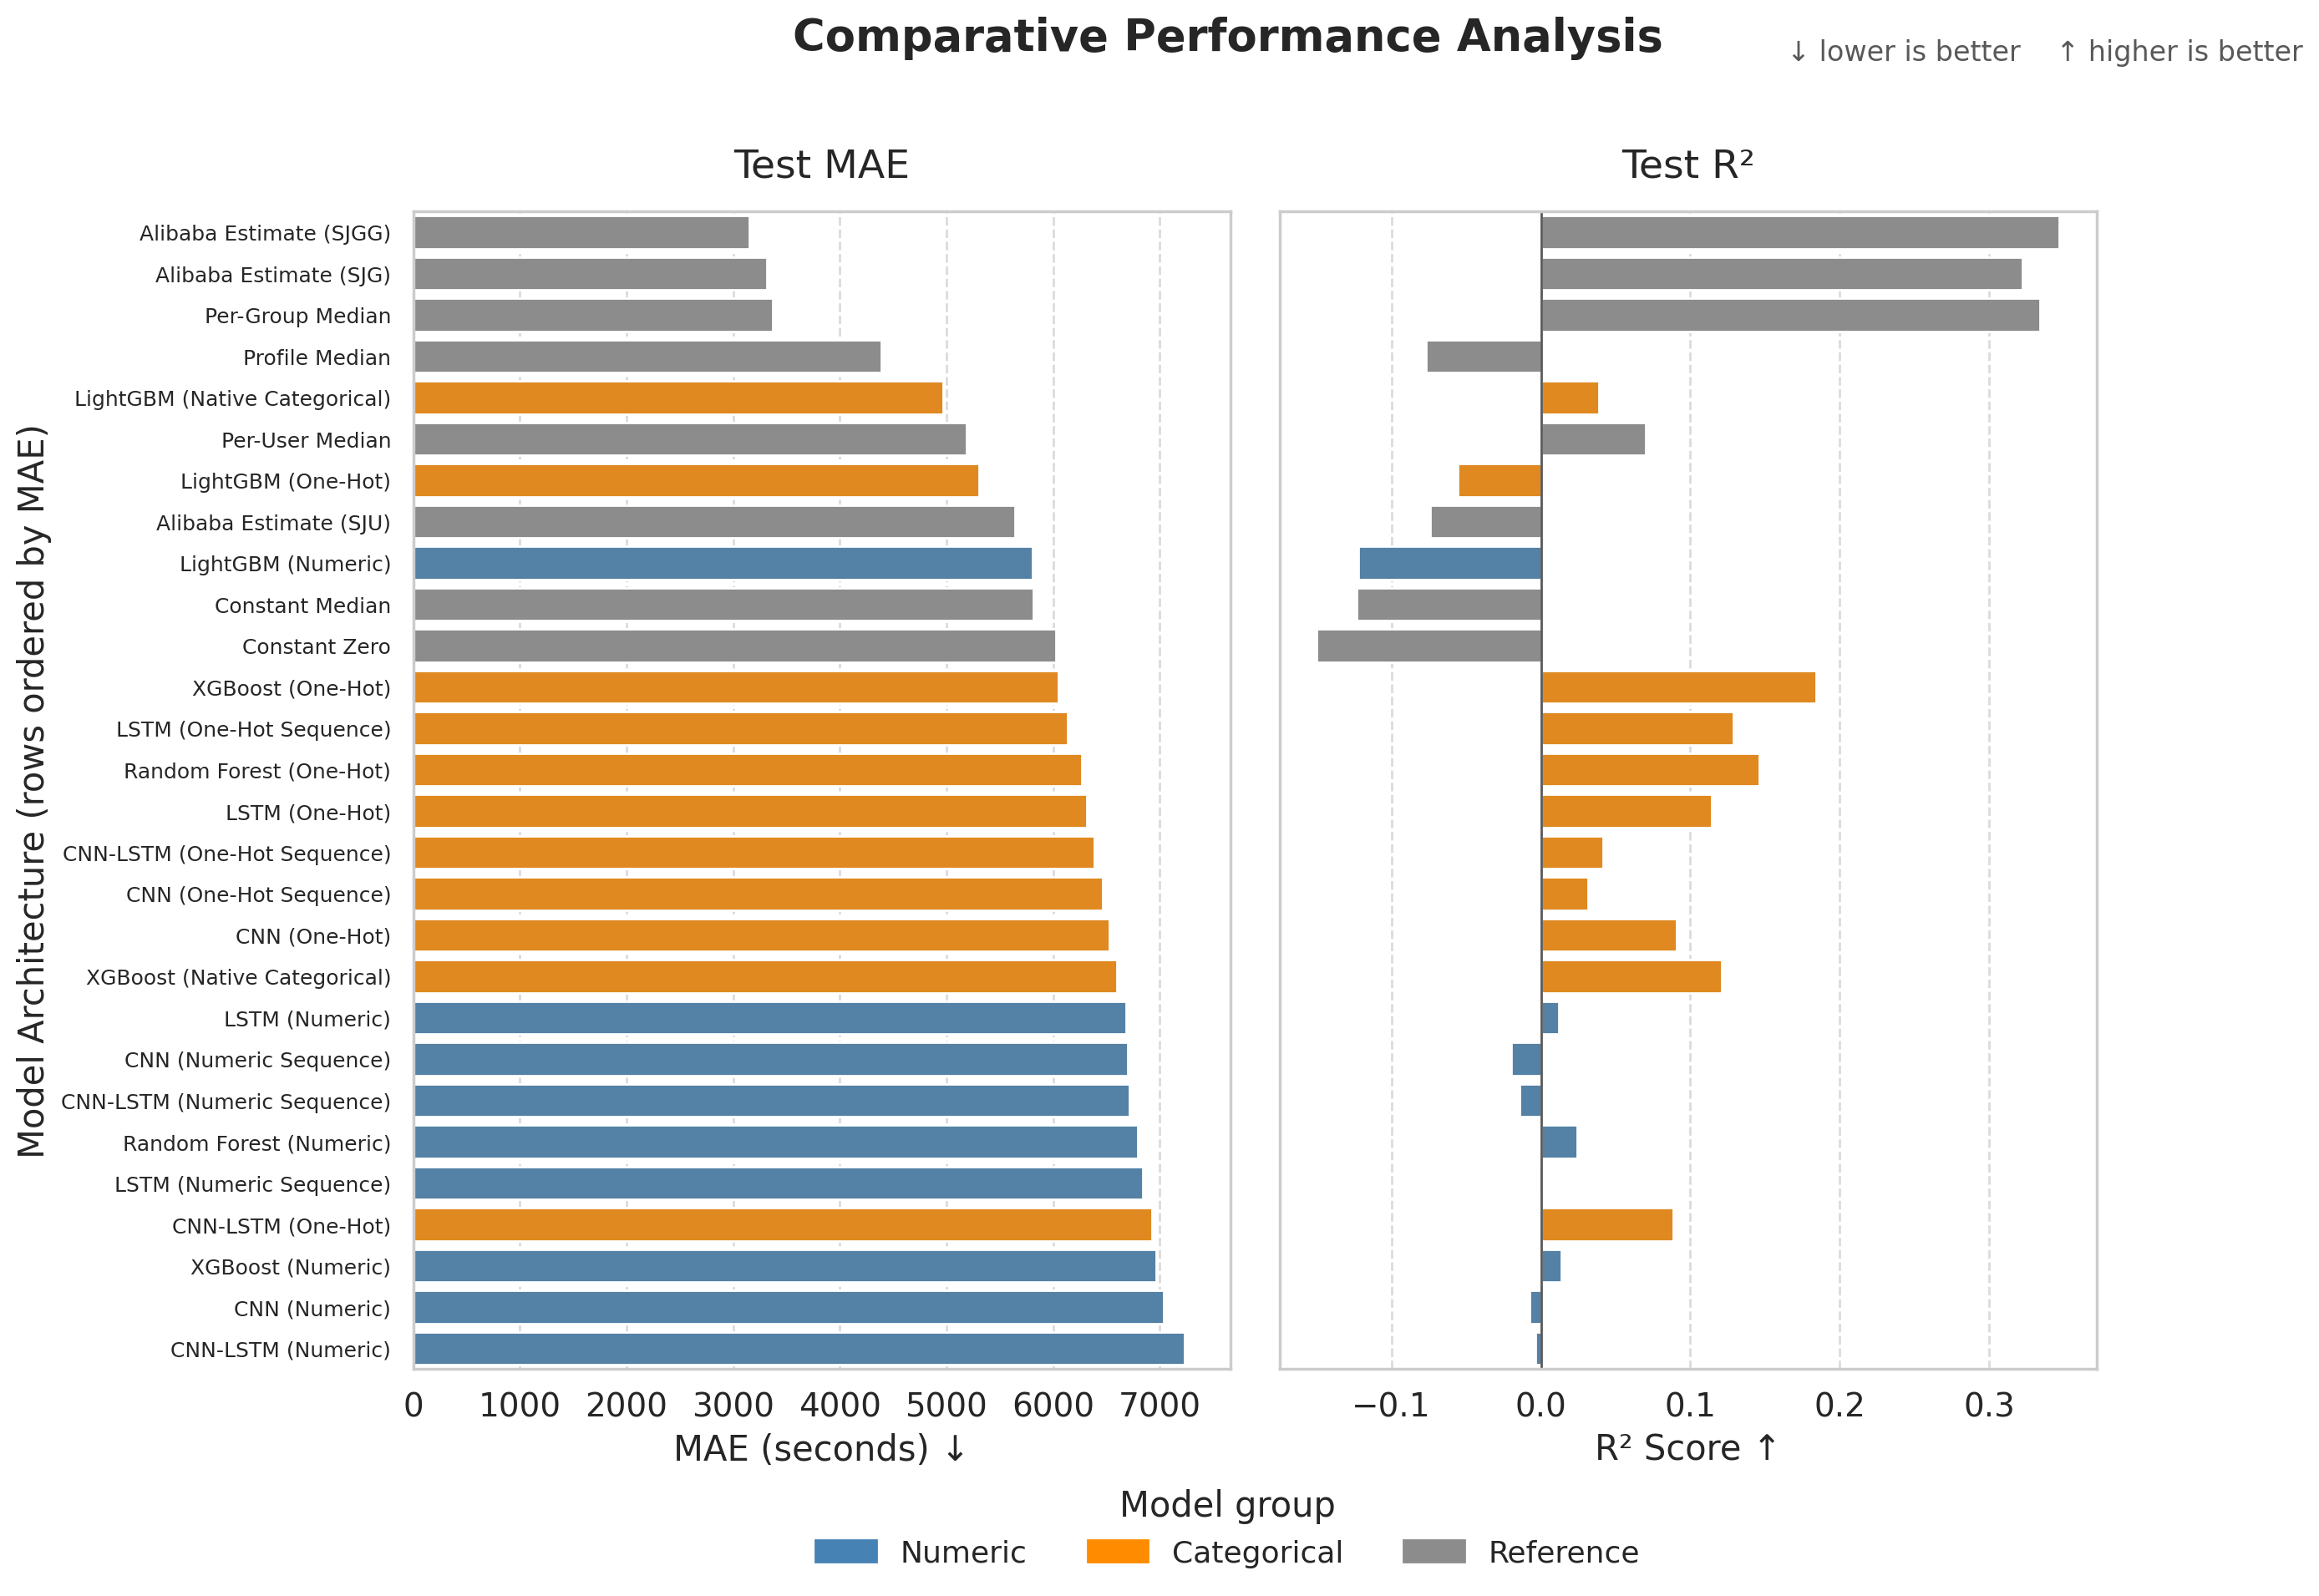

In [76]:
# Hard-coded sizes rescaled with the figure: these override rcParams, so
# leaving them at the old values would keep the very labels this figure
# was resized for at their old, unreadable printed size.
# ── 31. Visualisation — Final Comparison ─────────────────────────────────────
# BU HÜCREYİ ÇALIŞTIRMADAN ÖNCE BİR ÜSTTEKİ HÜCREYİ (Hücre 33) ÇALIŞTIRDIĞINDAN EMİN OL!
import seaborn as sns
import matplotlib.pyplot as plt
# Eğer df_all içinde 'Track' yoksa hata vermemesi için güvenli kontrol
if 'Track' not in df_all.columns:
    print("HATA: 'Track' sütunu bulunamadı! Lütfen bir üstteki hücreyi (Hücre 33) tekrar çalıştırın.")
else:
    # One shared label column, two metric panels (a forest-plot layout).
    # Two independent panels each carried their own 27-row label column, so the
    # same names were typeset twice and took ~45% of the width away from the
    # bars. Worse, the panels were sorted independently -- MAE ascending, R2
    # descending -- so reading one model's two metrics meant finding it twice,
    # in two different orders. Rows are ordered once, by MAE, and shared.
    fig, axes = plt.subplots(1, 2, figsize=(13, 9), sharey=True,
                             gridspec_kw={"wspace": 0.06})
    # Colour separates what the thesis TRAINED from what it compares against.
    # Previously the hue was the feature set alone, which put Constant Zero --
    # a predictor that ignores every feature -- in the same "Categorical"
    # colour as LightGBM (Native Categorical), and drew the two bars that lead
    # the MAE panel, Alibaba's own SJG/SJGG estimators, as though they were
    # models produced here. They are not: they are the reference the thesis is
    # measured against, and the central result -- that nothing trained here
    # beats them -- is only readable when the two groups are distinguishable.
    _REFERENCE_MODELS = {
        "Constant Zero", "Constant Median", "Profile Median", "Per-User Median",
        "Per-Group Median",
        "Alibaba Estimate (SJU)", "Alibaba Estimate (SJG)",
        "Alibaba Estimate (SJGG)",
    }
    _GROUP_ORDER = ["Numeric", "Categorical", "Reference"]
    df_all = df_all.copy()
    df_all["Group"] = np.where(
        df_all["Model"].isin(_REFERENCE_MODELS),
        "Reference",
        df_all["Track"],
    )
    _missing_ref = _REFERENCE_MODELS - set(df_all["Model"])
    if _missing_ref:
        # A renamed baseline would silently fall back to its feature-set colour,
        # which is the defect this block exists to prevent.
        print(f"[WARN] reference models not found in df_all: {sorted(_missing_ref)}")
    palette = {"Numeric": "steelblue", "Categorical": "darkorange",
               "Reference": "0.55"}
    # 1. MAE — Lower is Better
    df_sorted_mae = df_all.sort_values("MAE (s)", ascending=True)
    _row_order = df_sorted_mae["Model"].tolist()
    sns.barplot(
        data=df_sorted_mae, 
        y="Model", 
        x="MAE (s)",
        order=_row_order, 
        hue="Group", 
        palette=palette,
        hue_order=_GROUP_ORDER,
        ax=axes[0],
        edgecolor="white"
    )
    axes[0].set_title("Test MAE", fontsize=17, pad=15)
    axes[0].set_xlabel("MAE (seconds) ↓", fontsize=15)
    axes[0].set_ylabel("Model Architecture (rows ordered by MAE)", fontsize=15)
    axes[0].grid(axis="x", linestyle="--", alpha=0.7)
    # 2. R² — Higher is Better
    df_sorted_r2 = df_all.sort_values("R²", ascending=False)
    sns.barplot(
        data=df_all, 
        y="Model", 
        x="R²",
        order=_row_order, 
        hue="Group", 
        palette=palette,
        hue_order=_GROUP_ORDER,
        ax=axes[1],
        edgecolor="white"
    )
    axes[1].set_title("Test R²", fontsize=17, pad=15)
    axes[1].set_xlabel("R² Score ↑", fontsize=15)
    axes[1].set_ylabel("")
    # sharey hides the right panel's tick labels; keep them hidden.
    axes[1].tick_params(labelleft=False)
    # The legend and suptitle sit outside the axes, so the tight bbox expands
    # the exported figure past its declared width and the print scale lands at
    # 0.70x rather than 0.80x. The model names are the smallest text here, so
    # they get a point back to stay above the ~6 pt floor.
    axes[0].tick_params(axis="y", labelsize=9)
    # One legend for both panels: seaborn draws a "Track" legend on each axes,
    # so the same two entries appeared twice, at different positions.
    for _ax in axes:
        _lg = _ax.get_legend()
        if _lg is not None:
            _lg.remove()
    _handles = [plt.Rectangle((0, 0), 1, 1, color=palette[k]) for k in _GROUP_ORDER]
    # title_fontsize defaults to the axes title size, which is larger than the
    # legend body; at the resized figure that made the legend title the biggest
    # text on the page after the suptitle.
    fig.legend(_handles, _GROUP_ORDER, title="Model group",
               loc="lower center", bbox_to_anchor=(0.5, -0.04), ncol=3,
               frameon=False, fontsize=13, title_fontsize=15)
    # Axis limits are derived from the data so that the negative R2 values of
    # Experiments E and F remain visible; a hard-coded lower bound of 0 would
    # silently clip exactly the results the accompanying text relies on.
    _r2_min = float(df_sorted_r2["R²"].min())
    _r2_max = float(df_sorted_r2["R²"].max())
    _pad = 0.05 * max(1e-6, _r2_max - min(0.0, _r2_min))
    axes[1].set_xlim(min(0.0, _r2_min) - _pad, _r2_max + _pad)
    # The MAE panel autoscaled to just past the longest bar, so the last bar ran
    # into the frame with no tick beyond it to read it against.
    _mae_max = float(df_sorted_mae["MAE (s)"].max())
    axes[0].set_xlim(0, _mae_max * 1.06)
    axes[1].axvline(0, color="0.35", lw=1)
    axes[1].grid(axis="x", linestyle="--", alpha=0.7)
    plt.suptitle("Comparative Performance Analysis",
                 fontsize=19, fontweight="bold", y=1.01)
    # Symbol key for the arrow notation on the axis labels, so a reader who
    # has not met the convention can still read the figure.
    fig.text(0.995, 0.995, "↓ lower is better    ↑ higher is better",
             ha="right", va="top", fontsize=12, color="0.35")
    plt.tight_layout()
    plt.show()

> **Figure 1 — Comparative Performance Analysis for All Models**
>
> This comparative visualization summarizes the prediction performances obtained across all experimental tracks. The bars are coloured by **model group**, not by feature set alone: **Numeric** (blue) and **Categorical** (orange) are the configurations trained in this thesis, while **Reference** (grey) is what they are measured against — the median heuristics, Constant Zero, and Alibaba's own SJU/SJG/SJGG runtime estimates, none of which is a model produced here. The left graph illustrates **MAE values** (lower is better), while the right graph shows **R² scores** (higher is better); both panels share one row order, sorted by MAE.
>
> The visualization provides several critical insights into model behavior:
>
> *   **Where the top tier sits:** the bars at the top of both panels are grey. Alibaba's own estimates and the per-group median lead the MAE panel and the R² panel alike, so nothing trained here overtakes the reference the study is measured against — that is the result this figure exists to show, and it locates the gap in the available features rather than in the model class. Which trained model comes closest, and under which encoding, is read off the chart and off Table 7 — that ordering has already changed once with the feature pipeline, so this text does not fix it in place.
> *   **The "Categorical Boost" Effect:** where the orange (categorical) bar falls below the blue (numeric) one for the same architecture, `user` and `gpu_type` are paying for themselves. The size of the effect is not the same across architectures — read the pairs, not an average over them.
> *   **Deep Learning Performance Gap:** deep learning models (CNN, LSTM, and Hybrid) generally post higher error values and lower explanatory levels than the tree ensembles on the same feature sets, but the gap is a tendency between the two families rather than a rule that holds row by row — individual neural configurations do overtake individual tree rows in both panels.
> *   **Sequence Complexity:** the **Time-Series (Sequence) Models (Experiments E and F)** introduced as an ablation study do not separate cleanly from their static counterparts (Experiments C and D): the ten-step window shifts MAE and R² by small amounts, and not in the same direction for both metrics, so it buys no decisive gain over job-level features. Read the C/E and D/F pairs off the chart rather than taking a single verdict from this text.

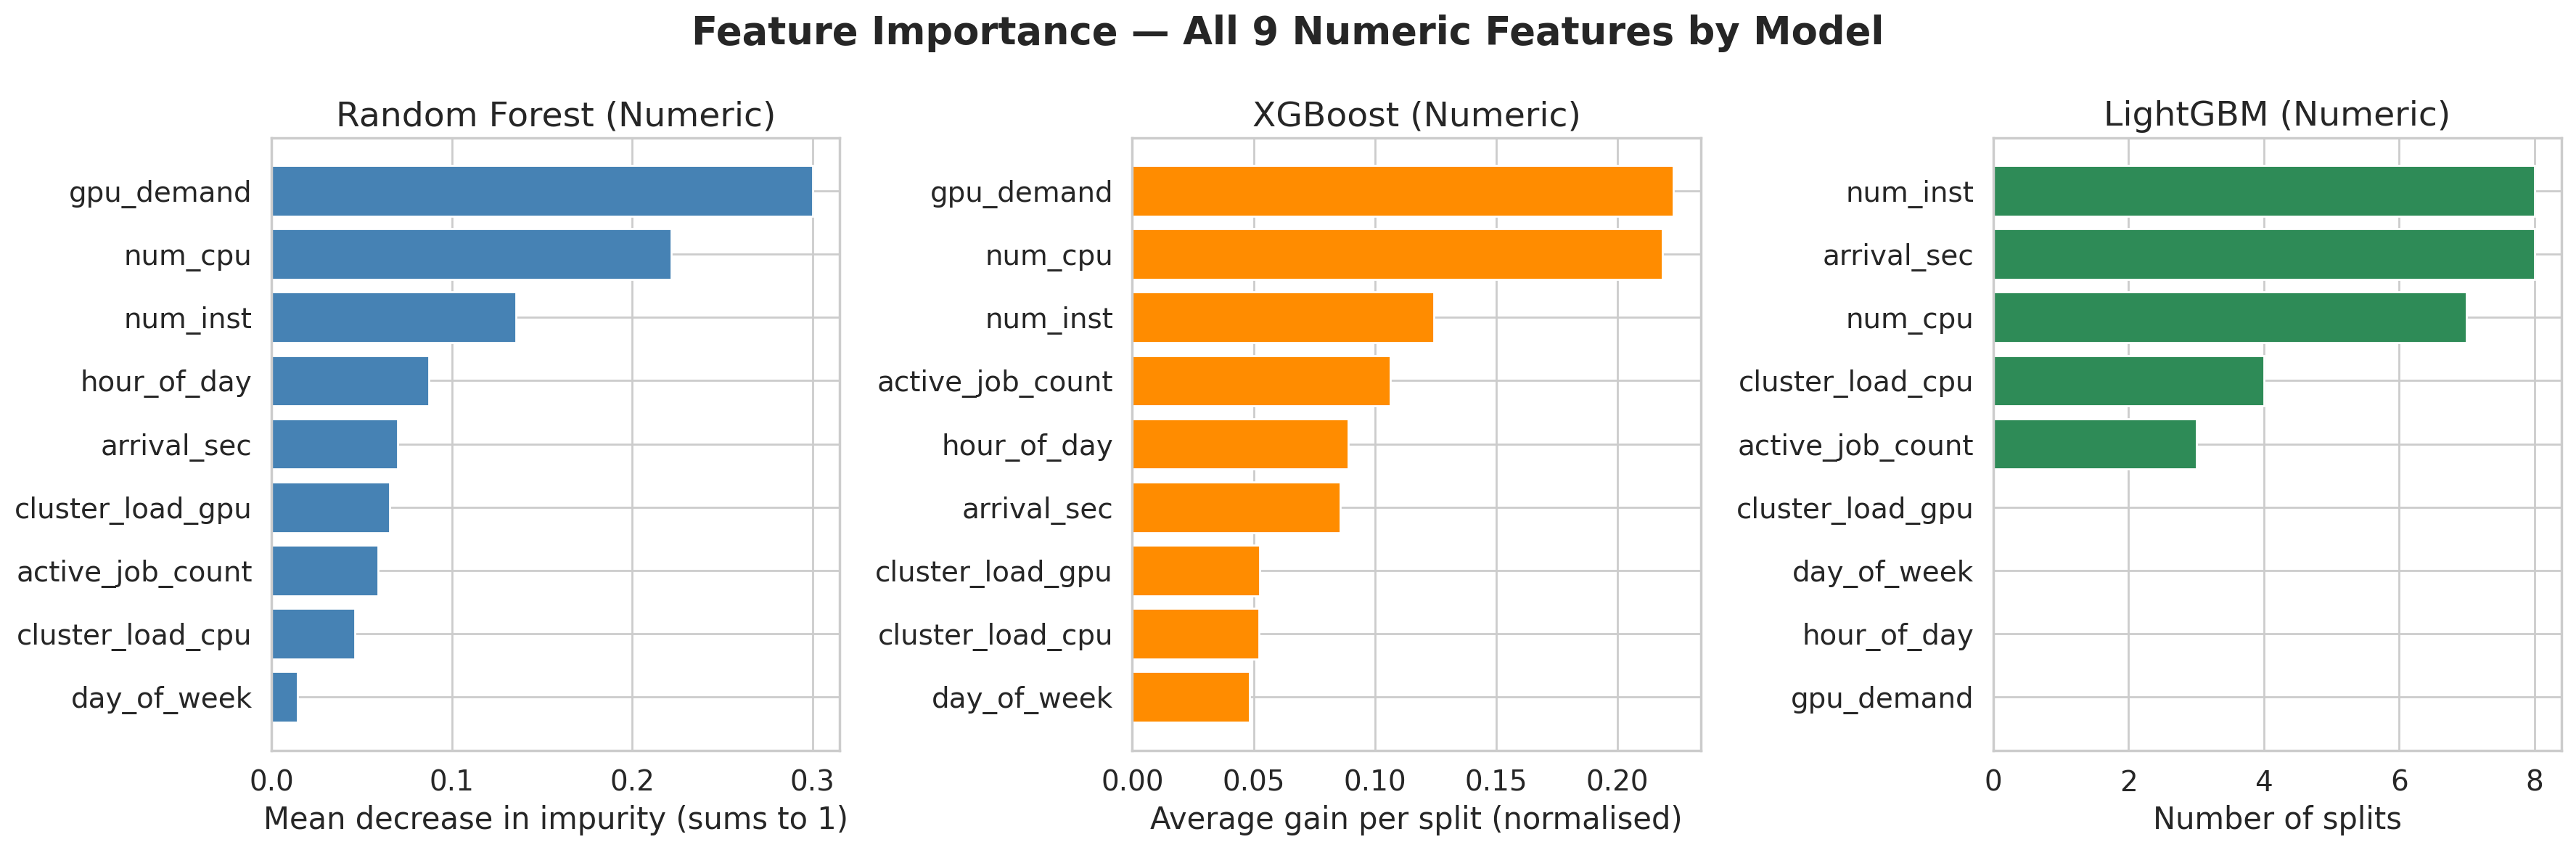

[Analysis] Most important feature across models:
  Random Forest: gpu_demand (importance=0.300)
  XGBoost: gpu_demand (importance=0.223)
  LightGBM: arrival_sec (importance=8.000)


In [77]:
# Hard-coded sizes rescaled with the figure: these override rcParams, so
# leaving them at the old values would keep the very labels this figure
# was resized for at their old, unreadable printed size.
# ── 33. Feature Importance — Tree-Based Models ───────────────────────────────
feature_names = list(X_train.columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (model_obj, label, color) in zip(axes, [
    (rf_final,  "Random Forest (Numeric)",  "steelblue"),
    (xgb_final, "XGBoost (Numeric)",        "darkorange"),
    (lgb_final, "LightGBM (Numeric)",       "seagreen"),
]):
    importances = model_obj.feature_importances_
    sorted_idx = importances.argsort()[::-1]  # every numeric feature (d = 9)
    ax.barh([feature_names[i] for i in sorted_idx[::-1]],
            importances[sorted_idx[::-1]],
            color=color, edgecolor="white")
    ax.set_title(label)
    # The three libraries do not report the same quantity: sklearn's RF gives
    # mean decrease in impurity (sums to 1), XGBoost defaults to average gain,
    # LightGBM to raw split counts. Labelling all three "Importance Score"
    # invited a cross-panel comparison that is not defined.
    _imp_units = {
        "Random Forest (Numeric)": "Mean decrease in impurity (sums to 1)",
        # xgboost's sklearn wrapper reports importance_type='gain', which is the
        # MEAN gain over the splits that use a feature, then normalises those
        # means to sum to 1. Verified against the booster: feature_importances_
        # matches get_score('gain') and does NOT match get_score('total_gain'),
        # so "share of total gain" named a quantity the array does not hold.
        "XGBoost (Numeric)":       "Average gain per split (normalised)",
        "LightGBM (Numeric)":      "Number of splits",
    }
    ax.set_xlabel(_imp_units.get(label, "Importance (model-specific units)"))
plt.suptitle(f"Feature Importance — All {len(feature_names)} Numeric Features by Model",
             fontsize=19, fontweight="bold")
plt.tight_layout()
plt.show()
print("[Analysis] Most important feature across models:")
for model_obj, label in [(rf_final, "Random Forest"), (xgb_final, "XGBoost"), (lgb_final, "LightGBM")]:
    top_idx = model_obj.feature_importances_.argmax()
    print(f"  {label}: {feature_names[top_idx]} (importance={model_obj.feature_importances_[top_idx]:.3f})")

> **Figure 2 — Feature Importance Analysis (ML Models with Numeric Features Only)**
>
> The feature importance analysis identifies the most influential variables used by machine learning models trained **only on numerical features**. Since each model (Random Forest, XGBoost, and LightGBM) utilizes different mathematical approaches (Bagging vs. Boosting), the ranking of important features varies across models, providing a holistic view of the data.
>
> Which feature ranks highest for a given model is not fixed across code/data revisions — a hardcoded ranking claimed here in an earlier revision no longer matched the model actually trained above once the feature set changed. Rather than replace one snapshot with another that could go stale the same way, no specific ranking is asserted in this text: the `[Analysis]` line printed directly above this cell always reports each model's actual current top feature, and Figure 2 shows the full ranking for all three.
>
> A caveat on reading these rankings at all: the three libraries do not report the same quantity, so the bars are comparable *within* a panel but not *across* panels. Random Forest reports Mean Decrease in Impurity (MDI, sums to 1), XGBoost the average gain per split (normalised to sum to 1), and LightGBM the raw number of splits a feature was used in — which is why the LightGBM value printed by the `[Analysis]` line above is an integer count on a completely different scale from the two fractions beside it, and why each panel's x-axis is labelled with its own measure. The MDI bias — a structural preference for continuous and high-cardinality features (`arrival_sec`, `gpu_demand`) over discrete ones — applies to the Random Forest panel specifically; what all three measures share is that they describe what a model's splits relied on — not a causal effect, and not held-out contribution. The Feature Ablations analysis earlier in this notebook answers the held-out-accuracy question directly, by retraining with specific features removed.

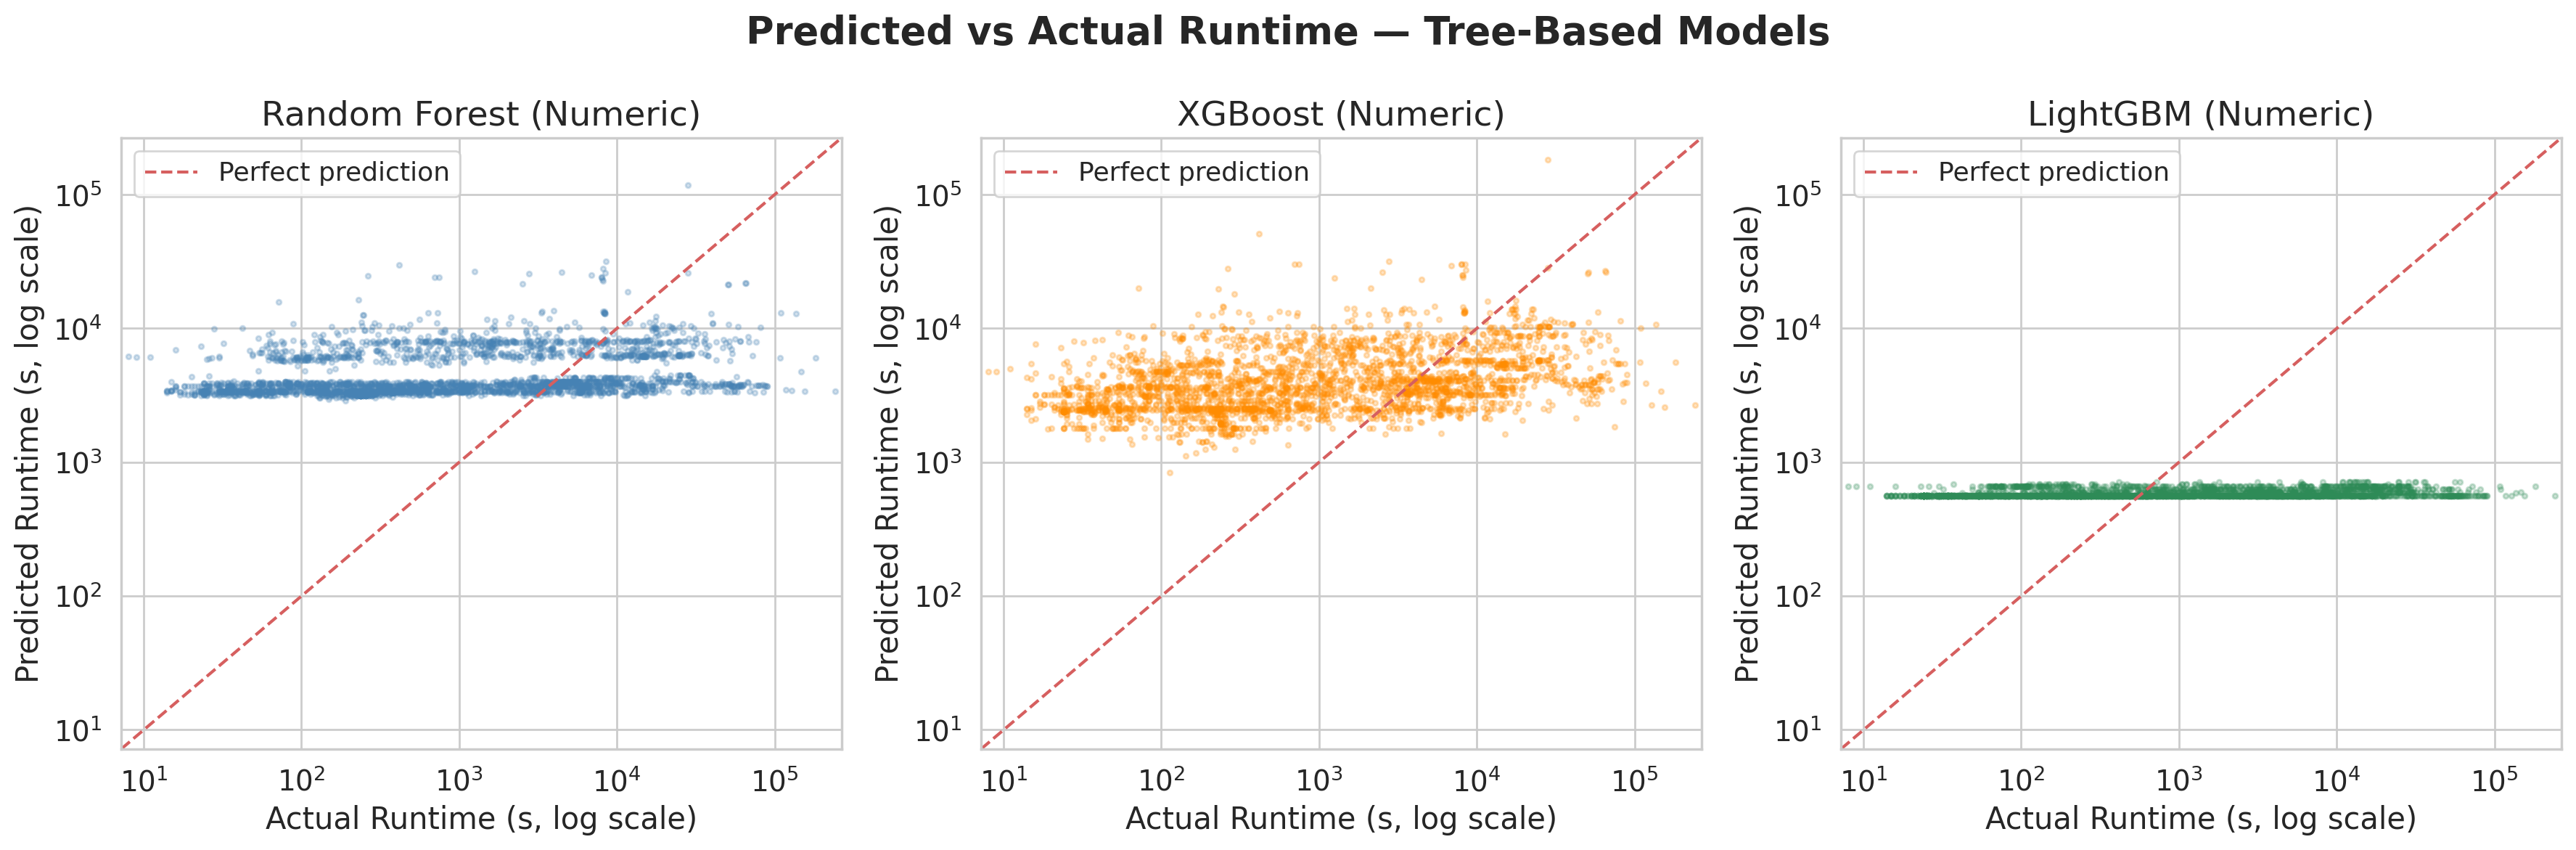

In [78]:
# ── 34. Predicted vs Actual Scatter Plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Random sample, not the first N chronological rows: the test set is
# time-ordered, so slice(None, 3000) was a single early time window
# (~18% of the test set), not a representative cross-section -- and it
# made these models look better-clustered around the diagonal than a
# random sample does (figures_tables-11).
_rng = np.random.default_rng(42)
sample_idx = _rng.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
for ax, (model_obj, Xte, yte, label, color) in zip(axes, [
    (rf_final,  X_test,    y_test,    "Random Forest (Numeric)", "steelblue"),
    (xgb_final, X_test,    y_test,    "XGBoost (Numeric)",       "darkorange"),
    (lgb_final, X_test,    y_test,    "LightGBM (Numeric)",      "seagreen"),
]):
    y_pred = model_obj.predict(Xte)[sample_idx]
    y_true = np.asarray(yte).flatten()[sample_idx]
    # Log-log axes: job runtime is heavy-tailed (Chapter 3), so a linear
    # scale crowds nearly every point into the bottom-left corner and
    # hides whether predictions actually track the diagonal across
    # orders of magnitude. Non-positive predictions (possible from a
    # tree regressor evaluated off-distribution) are floored to 1s so
    # they stay visible instead of breaking the log transform.
    y_pred = np.clip(y_pred, 1.0, None)
    y_true = np.clip(y_true, 1.0, None)
    ax.scatter(y_true, y_pred, alpha=0.25, s=6, color=color)
    lim_lo = min(y_true.min(), y_pred.min()) * 0.9
    lim_hi = max(y_true.max(), y_pred.max()) * 1.1
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--", lw=1.5, label="Perfect prediction")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_xlabel("Actual Runtime (s, log scale)")
    ax.set_ylabel("Predicted Runtime (s, log scale)")
    ax.set_title(label)
    ax.legend(fontsize=13)
plt.suptitle("Predicted vs Actual Runtime — Tree-Based Models",
             fontsize=19, fontweight="bold")
plt.tight_layout()

> **Figure 3 — Predicted vs Actual Runtime Analysis (ML Numeric Features Only Tree-Based Models)**
> 
> The scatter plots compare the **predicted runtime** and **actual runtime** values for the three tree-based models: **Random Forest, XGBoost, and LightGBM**. The red dashed line represents the **ideal prediction line**, where predicted values perfectly match the actual values ($y = x$).
> 
> Key takeaways from the visual error distribution:
> 
> *   **Performance on Short Jobs:** Most observations are heavily concentrated near the lower runtime range (bottom-left corner), indicating that the models perform relatively well for **shorter jobs**, which constitute the majority of the Alibaba workload.
> *   **Underestimation of Long Runtimes:** As the actual runtime increases (moving right on the X-axis), the predictions tend to deviate significantly from the ideal line, often appearing as a horizontal spread. This suggests that the models struggle to accurately estimate **very long runtimes**, showing a persistent tendency to **underestimate** extreme outlier values.
> *   **Inherent Complexity:** Despite these deviations, the models still capture the general trend and maintain a consistent prediction floor. The spread of points illustrates the inherent difficulty of predicting extreme runtime values based solely on initial job submission features.
> 
> Overall, these plots confirm that while the models are highly reliable for standard workloads, specialized strategies or additional features might be required for better capturing the behavior of long-running "elephant" jobs.

Text(0.5, 0.02, 'Residual (Predicted − Actual, seconds)')

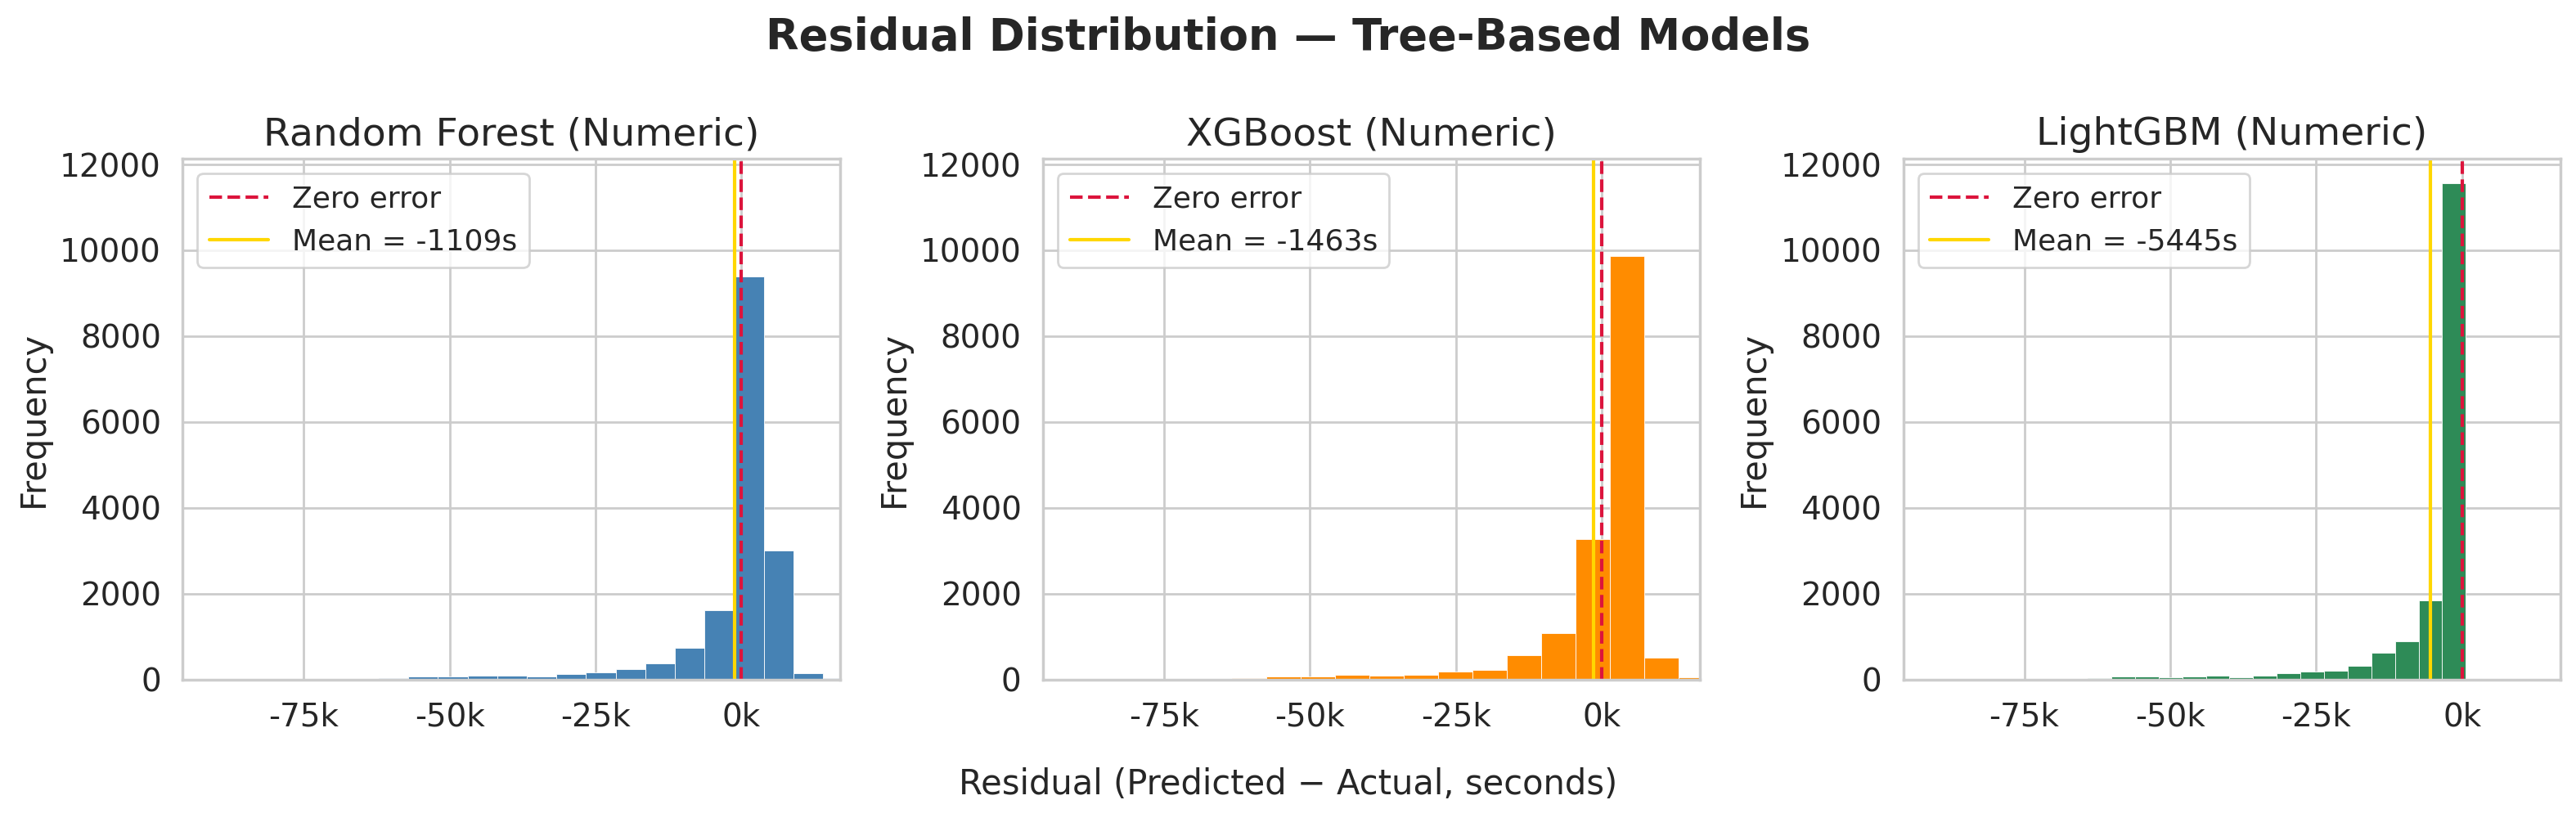

In [79]:
# ── 35. Residual Histograms ───────────────────────────────────────────────────
import matplotlib.ticker as mticker

_res_axes = []
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (model_obj, Xte, yte, label, color) in zip(axes, [
    (rf_final,  X_test, y_test, "Random Forest (Numeric)", "steelblue"),
    (xgb_final, X_test, y_test, "XGBoost (Numeric)",       "darkorange"),
    (lgb_final, X_test, y_test, "LightGBM (Numeric)",      "seagreen"),
]):
    residuals = model_obj.predict(Xte) - yte
    ax.hist(residuals, bins=80, color=color, edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="crimson", linestyle="--", lw=1.5, label="Zero error")
    ax.axvline(residuals.mean(), color="gold", linestyle="-", lw=1.5,
               label=f"Mean = {residuals.mean():.0f}s")
    # One shared x label under all three panels rather than three copies: at
    # the printed figure width the repeated label is wider than its own panel,
    # so the third copy ran off the figure edge and printed clipped.
    ax.set_ylabel("Frequency")
    ax.set_title(label)
    ax.legend(fontsize=13)
    # Six-figure second counts collided into an unreadable strip on the two
    # boosted panels; thin them out and show thousands instead.
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _pos: f"{v / 1000:,.0f}k"))
    _res_axes.append((ax, residuals))
# One shared x-range across the three panels: with independent ranges the eye
# reads three differently-scaled spreads as if they were comparable.
_res_lo = min(float(np.percentile(r, 0.5)) for _, r in _res_axes)
_res_hi = max(float(np.percentile(r, 99.5)) for _, r in _res_axes)
# The three panels plot the same quantity on the same test set, so a shared
# y range is required as well: with independent autoscaling the tallest bar
# fills each panel regardless of its count (11.5k vs 6.5k), and the panels
# read as equally peaked when they are not.
_res_ymax = max(_ax.get_ylim()[1] for _ax, _ in _res_axes)
for _ax, _ in _res_axes:
    _ax.set_xlim(_res_lo, _res_hi)
    _ax.set_ylim(0, _res_ymax)

plt.suptitle("Residual Distribution — Tree-Based Models",
             fontsize=19, fontweight="bold")
# tight_layout does not reserve space for a figure-level x label, so the label
# has to be placed after it, into a strip left free by rect.
plt.tight_layout(rect=(0, 0.06, 1, 1))
# The tick formatter renders values as "-25k", so the label must NOT also say
# "thousands" -- stating the unit twice reads as -25k thousands of seconds.
fig.supxlabel("Residual (Predicted − Actual, seconds)", fontsize=15, y=0.02)

> **Figure 4 — Residual Distribution Analysis (ML Numeric Features Only Tree-Based Models)**
> 
> The residual distribution plots illustrate the difference between **predicted and actual runtimes (Predicted – Actual)** for the tree-based models: **Random Forest, XGBoost, and LightGBM**. Ideally, residuals should be **centered around zero with minimal spread**, indicating unbiased predictions and low error variance.
> 
> Key observations from the error distributions:
> 
> *   **Concentration Around Zero:** Across all three models, the majority of residuals are concentrated very close to zero, suggesting that the models generally produce reasonably accurate predictions for the core workload.
> *   **Bias and Spread:** while the peaks sit near zero, the mean residual differs markedly between the three models — the figure reports each one, recomputed with the models on every run, so no value is quoted here. A mean far from zero indicates systematic under- or over-estimation driven by the extreme tail rather than by the bulk of the jobs.
> *   **Distribution Tails:** all three panels share one x-range, and all three carry a long tail rather than a compact spread — the large errors come from the **extreme, very long jobs**, not from one particular model. Which model's tail is the widest is a run-dependent ordering and is not asserted here; the RMSE column of Table 1 quantifies it and the shared x-range of this figure shows it.
> 
> Overall, these distributions confirm that while the models are largely unbiased for the majority of jobs, the high-variance nature of GPU runtimes results in extended tails that represent the difficulty of predicting extreme execution durations.

In [ ]:
# Hard-coded sizes rescaled with the figure: these override rcParams, so
# leaving them at the old values would keep the very labels this figure
# was resized for at their old, unreadable printed size.
# ── 36. Deep Learning Model Comparison (Experiments C-F) ─────────────────────
# Metrics are selected by name rather than by iterating the dict: with
# multi-seed refits the metrics carry '<name>_std', '<name>_seed0', 'n_seeds'
# and a 'seeds' list, and blindly rounding every value breaks on the list.
_DL_RUNS = [
    ("C — Numeric",                "CNN",      cnn_metrics_num),
    ("C — Numeric",                "LSTM",     lstm_metrics_num),
    ("C — Numeric",                "CNN-LSTM", hybrid_metrics_num),
    ("D — Categorical",            "CNN",      cnn_metrics_cat),
    ("D — Categorical",            "LSTM",     lstm_metrics_cat),
    ("D — Categorical",            "CNN-LSTM", hybrid_metrics_cat),
    ("E — Numeric (Sequence)",     "CNN",      cnn_metrics_num_seq),
    ("E — Numeric (Sequence)",     "LSTM",     lstm_metrics_num_seq),
    ("E — Numeric (Sequence)",     "CNN-LSTM", hybrid_metrics_num_seq),
    ("F — Categorical (Sequence)", "CNN",      cnn_metrics_cat_seq),
    ("F — Categorical (Sequence)", "LSTM",     lstm_metrics_cat_seq),
    ("F — Categorical (Sequence)", "CNN-LSTM", hybrid_metrics_cat_seq),
]
_CORE = ["mae", "mdae", "rmse", "mape", "r2"]

_rows = []
for _exp, _arch, _metrics in _DL_RUNS:
    _row = {"Experiment": _exp, "Architecture": _arch}
    for _k in _CORE:
        _row[_k] = round(float(_metrics[_k]), 2)
        # Present only when the refit was repeated over several seeds.
        if f"{_k}_std" in _metrics:
            _row[f"{_k}_std"] = round(float(_metrics[f"{_k}_std"]), 2)
        # The network actually saved to disk (and used by notebook 05's
        # simulation) is the first seed's, not the mean -- its own score can
        # rank architectures differently than the multi-seed mean does
        # (modeling-8/statistics-5). Surfaced explicitly so a reader is never
        # left comparing a mean in this table against a different network's
        # behaviour in the simulation chapter.
        if f"{_k}_seed0" in _metrics:
            _row[f"{_k}_seed0"] = round(float(_metrics[f"{_k}_seed0"]), 2)
    _row["n_seeds"] = int(_metrics.get("n_seeds", 1))
    # is_degenerate_prediction is three-valued and every DL checkpoint on
    # disk predates pred_unique_frac, so the None verdict has to stay
    # visible as "unknown": collapsing it to False would print a clean
    # bill of health for a model nothing has actually judged.
    _row["degenerate"] = degeneracy_label(_metrics)
    _rows.append(_row)
dl_summary = pd.DataFrame(_rows)
if "mae_seed0" in dl_summary.columns and (dl_summary["n_seeds"] > 1).any():
    print("[Note] '_seed0' columns are the specific network saved to disk and used by")
    print("       notebook 05's simulation; the un-suffixed columns are the multi-seed")
    print("       mean. Where they disagree on which architecture is best, the mean is")
    print("       the more reliable estimate of true performance, but the simulation")
    print("       chapter describes the seed0 network's behaviour, not the mean's.")

_has_std = "mae_std" in dl_summary.columns
_err = dl_summary["mae_std"] if _has_std else None

# The 12 two-line "Experiment\nArchitecture" labels physically overlapped at
# rotation=15. The experiment is now carried by bar colour + a legend, so the
# tick only has to hold the architecture name and can sit upright.
_exp_order = list(dict.fromkeys(dl_summary["Experiment"]))
_exp_colors = dict(zip(_exp_order, sns.color_palette("muted", len(_exp_order))))

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(dl_summary))
ax.bar(x, dl_summary["mae"], yerr=_err, capsize=4,
       color=[_exp_colors[e] for e in dl_summary["Experiment"]], edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(dl_summary["Architecture"], rotation=0, fontsize=13)
# Legend outside the axes: inside, it covered the first bars' value labels.
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=_exp_colors[e]) for e in _exp_order],
          labels=_exp_order, fontsize=13,
          loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=len(_exp_order),
          frameon=False)  # no legend title: the labels name the experiments already
# Headroom for the value labels printed above each bar/whisker.
_y_lo, _y_hi = ax.get_ylim()
ax.set_ylim(_y_lo, _y_hi * 1.08)
ax.set_ylabel("MAE (seconds) ↓")
# Twelve architecture names across a 7.6-inch axis ran together ("LSTMCNN-LSTM")
# once the figure was sized for print; rotating separates them.
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")
_n = int(dl_summary["n_seeds"].max())
# pad clears the legend strip now sitting above the axes.
ax.set_title("Deep Learning Models — Final Test MAE", pad=34)
# Symbol key for the arrow notation on the axis labels, so a reader who has
# not met the convention can still read the figure.
fig.text(0.995, 0.995, "↓ lower is better",
         ha="right", va="top", fontsize=12, color="0.35")
for _i, _row in dl_summary.iterrows():
    _off = (_row["mae_std"] if _has_std else 0) + 20
    ax.text(_i, _row["mae"] + _off, f"{_row['mae']:.0f}s", ha="center", va="bottom", fontsize=12)
plt.tight_layout()
plt.show()

print()
print("[Summary] DL Model Final Results:")
_cols = ["Experiment", "Architecture"]
for _k in _CORE:
    _cols.append(_k)
    if f"{_k}_std" in dl_summary.columns:
        _cols.append(f"{_k}_std")
    if f"{_k}_seed0" in dl_summary.columns:
        _cols.append(f"{_k}_seed0")
_cols.append("n_seeds")
_cols.append("degenerate")
# Raw internal metric keys (mae, mae_std, r2, ...) reached the thesis as
# column headers; every other table uses a spelled-out name with a unit.
_hdr_units = {"mae": "MAE (s)", "mdae": "MdAE (s)", "rmse": "RMSE (s)",
              "mape": "MAPE (%)", "r2": "R²"}
_hdr_map = {}
for _base, _pretty in _hdr_units.items():
    _hdr_map[_base] = _pretty
    _hdr_map[f"{_base}_std"] = f"{_pretty} — std"
    _hdr_map[f"{_base}_seed0"] = f"{_pretty} — saved seed"
_hdr_map["n_seeds"] = "Seeds (n)"
_hdr_map["degenerate"] = "Constant output?"
display(dl_summary[_cols].rename(columns=_hdr_map))
print_degeneracy_notice(dl_summary["Experiment"] + " — " + dl_summary["Architecture"],
                        dl_summary["degenerate"])

> **Figure 5 — Deep Learning Model Performance Comparison (Experiments C, D, E, and F)**
>
> The figure collects the final MAE of every deep-learning architecture across the four DL experiments — numeric-only (C and E) against one-hot categorical (D and F), static (C and D) against sequential (E and F). The bars are redrawn from the metrics each run produces and every one is a mean over the `DL_SEEDS` seeds, so this text quotes no value and names no best network. A previous revision did, citing a MAPE and an MdAE that appear in no executed cell.
>
> Read the figure as a 2×2:
>
> *   **Numeric against categorical within a track** shows what one-hot identity features are worth to a network.
> *   **Static against sequential** shows whether a ten-step window helps; the window multiplies an already sparse input rather than adding new information, so a null or negative effect is the reading to expect.
> *   **Bars that differ by less than the seed spread are not differences.** Section 36 prints that spread — consult it before reading an ordering off this chart.
>
> The durable conclusion is comparative rather than absolute: how the DL configurations stand against each other and against the tree ensembles on the same features is what Table 7 reports, and it is the comparison this figure illustrates.

In [ ]:
# ── 37. Champion Hyperparameter Table ────────────────────────────────────────
champion_params = pd.DataFrame([
    {"Model": "Random Forest (Numeric)",          "Source": "Exp A", "Params": str(rf_gs_best)},
    {"Model": "XGBoost (Numeric)",     "Source": "Exp A", "Params": str(xgb_gs_best)},
    {"Model": "LightGBM (Numeric)",    "Source": "Exp A", "Params": str(lgb_gs_best)},
    {"Model": "Random Forest (One-Hot)",      "Source": "Exp B", "Params": str(rf_oh_gs_best)},
    {"Model": "XGBoost (One-Hot)",     "Source": "Exp B", "Params": str(xgb_oh_gs_best)},
    {"Model": "LightGBM (One-Hot)",          "Source": "Exp B", "Params": str(lgb_oh_gs_best)},
    {"Model": "LightGBM (Native Categorical)",      "Source": "Exp B", "Params": str(lgb_nat_gs_best)},
    {"Model": "XGBoost (Native Categorical)",       "Source": "Exp B", "Params": str(xgb_nat_gs_best)},
    {"Model": "CNN (Numeric)",         "Source": "Exp C", "Params": str(best_cnn_gs_params_num)},
    {"Model": "LSTM (Numeric)",        "Source": "Exp C", "Params": str(best_lstm_gs_params_num)},
    {"Model": "CNN-LSTM (Numeric)",    "Source": "Exp C", "Params": str(best_hybrid_gs_params_num)},
    {"Model": "CNN (One-Hot)",         "Source": "Exp D", "Params": str(best_cnn_gs_params_cat)},
    {"Model": "LSTM (One-Hot)",        "Source": "Exp D", "Params": str(best_lstm_gs_params_cat)},
    {"Model": "CNN-LSTM (One-Hot)",    "Source": "Exp D", "Params": str(best_hybrid_gs_params_cat)},
    {"Model": "CNN (Numeric Sequence)",         "Source": "Exp E", "Params": str(best_cnn_gs_params_num_seq)},
    {"Model": "LSTM (Numeric Sequence)",        "Source": "Exp E", "Params": str(best_lstm_gs_params_num_seq)},
    {"Model": "CNN-LSTM (Numeric Sequence)",    "Source": "Exp E", "Params": str(best_hybrid_gs_params_num_seq)},
    {"Model": "CNN (One-Hot Sequence)",         "Source": "Exp F", "Params": str(best_cnn_gs_params_cat_seq)},
    {"Model": "LSTM (One-Hot Sequence)",        "Source": "Exp F", "Params": str(best_lstm_gs_params_cat_seq)},
    {"Model": "CNN-LSTM (One-Hot Sequence)",    "Source": "Exp F", "Params": str(best_hybrid_gs_params_cat_seq)},
])
# "Params" is what the SEARCH settled on, which for a booster is not a
# description of the model refit from it: n_estimators there is only the
# budget, and early stopping can end the refit orders of magnitude short of
# it (Exp A LightGBM reached its MAE with a single tree behind an
# n_estimators of 1300). The two columns below come from finalize_ml_model's
# metrics instead. The loss column is the only place in this table showing
# that the rows are not all fitted the same way: only LightGBM minimises L1,
# the metric every results table ranks on, while XGBoost and RandomForest both
# minimise squared error (src.tuning._XGB_OBJECTIVE says why neither is forced
# onto L1) -- which is exactly what this column exists to show. "—" means
# the row carries no such number -- RandomForest fits every tree it is
# given, the DL rows are tuned by a different routine, and checkpoints
# written before these keys existed have neither.
_champion_metrics = {
    "Random Forest (Numeric)":       rf_final_metrics,
    "XGBoost (Numeric)":             xgb_final_metrics,
    "LightGBM (Numeric)":            lgb_final_metrics,
    "Random Forest (One-Hot)":       rf_oh_final_metrics,
    "XGBoost (One-Hot)":             xgb_oh_final_metrics,
    "LightGBM (One-Hot)":            lgb_oh_final_metrics,
    "LightGBM (Native Categorical)": lgb_nat_final_metrics,
    "XGBoost (Native Categorical)":  xgb_nat_final_metrics,
}
def _champion_trees(model_name):
    """Trees the final refit kept / trees the search was allowed, or "—"."""
    _cm = _champion_metrics.get(model_name, {})
    if 'n_estimators_effective' not in _cm:
        return "—"
    return f"{_cm['n_estimators_effective']} / {_cm.get('n_estimators_searched') or '—'}"
champion_params["Trees (refit / searched)"] = [_champion_trees(_name) for _name in champion_params["Model"]]
champion_params["Loss"] = [_champion_metrics.get(_name, {}).get("train_loss", "—") for _name in champion_params["Model"]]
pd.set_option("display.max_colwidth", 120)
print()
print("=" * 80)
print("  THE BEST HYPERPARAMETERS — All Experiments")
print("=" * 80)

display(champion_params)

> **Table 8 – Final Hyperparameter Configuration of All Models**
> 
> The table summarizes the **final hyperparameter configurations** obtained after the rigorous tuning process for all evaluated models across Experiments A, B, C, D, E, and F. Each configuration represents the optimal parameter set selected based on cross-validation performance during the randomized and grid search phases.
> 
> Key observations from the hyperparameter tuning results:
> 
> *   **Tree-Based Machine Learning Models:** Crucial parameters such as **maximum depth, feature sampling ratios, learning rate, and regularization** were optimized to prevent overfitting. For the Random Forest models the search settles on a bounded tree depth and a feature-subsampling ratio below one; the exact values are whatever the current search returns and are listed in the table rather than restated here, because re-running the search on a changed feature set can move them. The gradient boosting models (XGBoost and LightGBM) rely on carefully tuned **learning rates and column sampling strategies** to balance complexity and generalization.
> *   **The last two columns:** the parameter set is the search's answer, not a description of the model refit from it. **Trees (refit / searched)** puts the tree count the final refit actually kept beside the budget the search was allowed — for the boosters early stopping can end the refit far short of that budget — and **Loss** names the objective each family minimised. That is where the comparison stops being like for like: only LightGBM is fitted on L1, the metric every results table ranks on, while the XGBoost and Random Forest rows minimise squared error — so **Loss** is the column that tells the reader which rows are comparable on loss at all. A dash means the row records no such value.
> 
> *   **Deep Learning Architectures:** The tuning process focused on both structural and optimization parameters, including the **number of filters (CNN)**, **hidden units (LSTM)**, **kernel sizes**, and **batch sizes**. Hybrid architectures such as **CNN-LSTM** combine convolutional feature extraction with sequential modeling, requiring additional synchronization of parameters like LSTM hidden sizes and layer counts.
> 
> Overall, these selected configurations reflect a precise balance between **model capacity, training stability, and predictive performance**, ensuring that each architecture operates under its most effective parameter setting for the given workload dataset.

## Summary

In this notebook, a massive 6-stage (Experiments A, B, C, D, E, F) architectural cascade was designed for the Alibaba PAI GPU cluster job runtime prediction problem:

| Experiment Suite | Scientific Discoveries & Algorithmic Collisions |
|---|---|
| **Experiment A (Numeric Baseline)** | Tree-based engines (RF, XGB, LGBM) mathematically established a heavily flawed, weak baseline relying exclusively on physical numeric signals. Error residuals scaled massively. |
| **Experiment B (Categorical Extension)** | Direct injection of extreme cardinal parameters ("user" & "gpu_type") forced massive bounds in accuracy. LightGBM's purely Native Categorical capability completely annihilated the high-memory pressure crippling alternative One-Hot infrastructures. |
| **Experiment C (Static Neural - Numeric)** | Foundational convolutional and recurrent architectures aggressively mapped temporal chronologies severely limited to purely continuous numeric arrays. |
| **Experiment D (Static Neural - One-Hot)** | Challenged by highly dimensional and intensely sparse feature spaces, deep CNN/LSTM hybrids faced significant convergence friction during fundamental optimization. |
| **Experiment E (Temporal Neural Sequence - Numeric Baseline)** | By integrating a Sliding Window mechanism into deep learning architectures, models were shifted away from tabular forms into analyzing 10-step sequential history representations. |
| **Experiment F (Temporal Neural Sequence - One Hot)** | By combining the complexity of high-dimensional categorical sparse data with the temporal depth of sequences (sequence=10), this ultimate stage pushed DL capacities as a fully-fledged Ablation Study to its absolute limits. |

In conclusion, the sequential introduction of human-centric and topological data fundamentally transformed not only the optimization variables but also the underlying infrastructure memory utilization across engines. Identifying the optimal architectures through hundreds of grid and randomized parameter permutations firmly equips the simulation environment in Notebook 05 to integrate these predictive layers into a dynamic, intelligent Global Workload Scheduler.
